#### Realisation d'une ACP en python

In [202]:
# Import packages
!pip install scikit-learn

import pandas as pd
import matplotlib.pyplot as plt
import  seaborn as sns
import numpy as np # Module pour les calculs numeriques
import sklearn.decomposition as PCA # module de la librairie Scikit-learn, tres populaire pour faire du machine learning
import sklearn.preprocessing as StandardScaler
import scipy.stats as stats

In [203]:
# Importation du dataframe

df=sns.load_dataset("iris")
# Afficher  les premieres lignes du tableau
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [209]:
# Analyse de la dimension de la base de données
df.shape

(150, 5)

In [215]:
# Analyse du type de variable dans la base de données
df.dtypes
# Les floats sont des nmbres continus avec des virgules

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

In [216]:
# Analyse des données manquantes
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

# 2 Analyse descriptives univariés

In [227]:
# Analyse descriptive du jeu de données
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [238]:
# Description des variables qualitatives
df.describe(include="object")

,species
count,150
unique,3
top,setosa
freq,50


<Axes: >

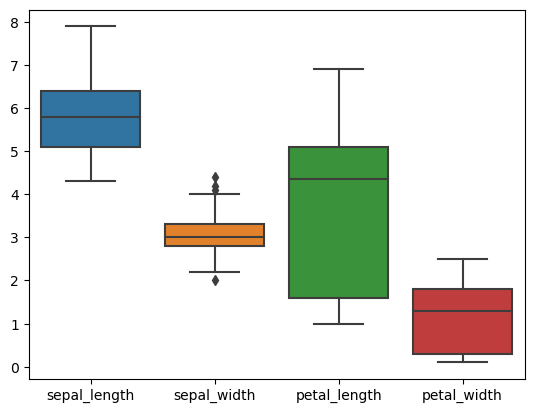

In [240]:
# Analyse descriptives des variables quantitatives
sns.boxplot(data=df)

C:\Users\brech\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


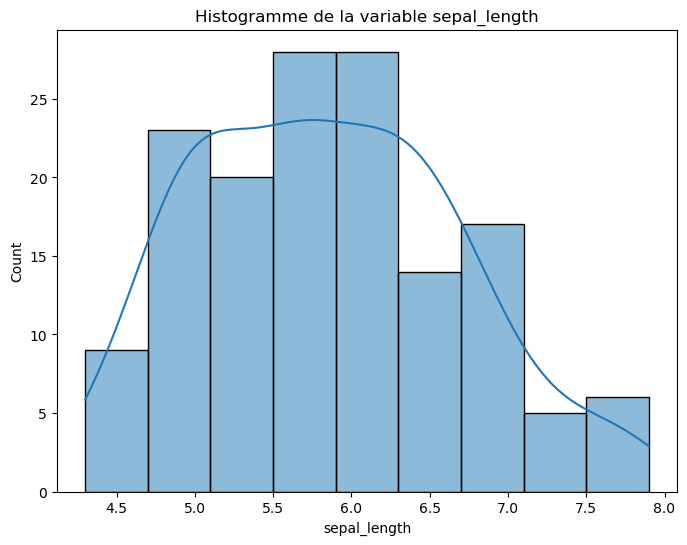

La variable sepal_length suit une loi normale (p-value=0.0568)


C:\Users\brech\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


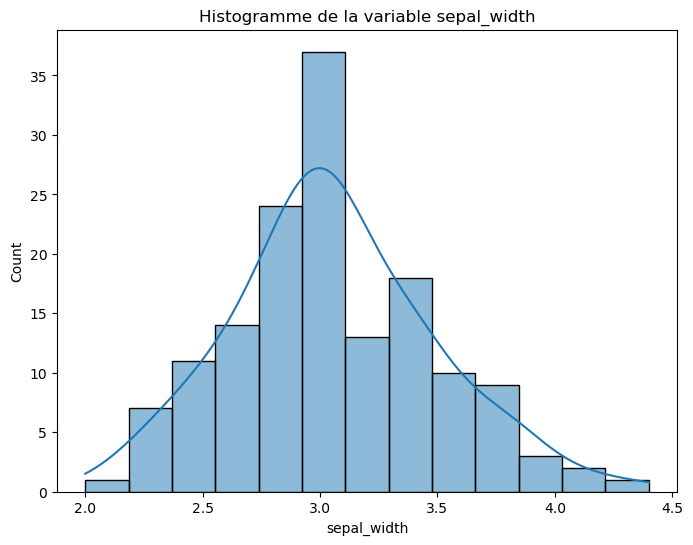

La variable sepal_width suit une loi normale (p-value=0.2097)


C:\Users\brech\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


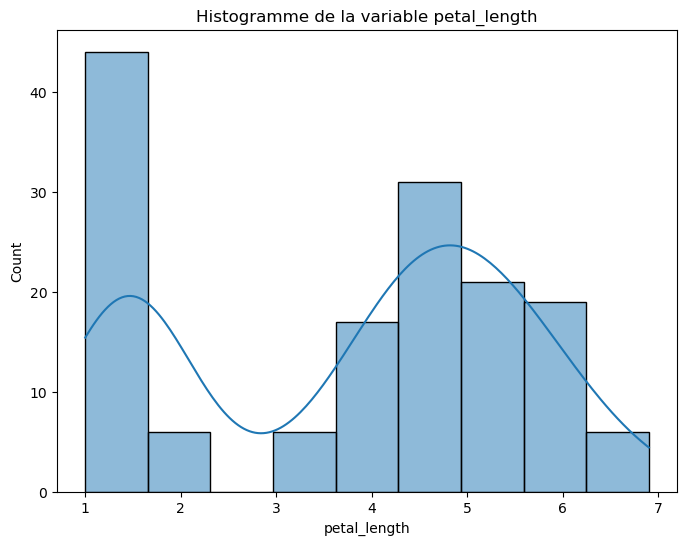

La variable petal_length ne suit pas une loi normale (p-value=0.0000)


C:\Users\brech\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


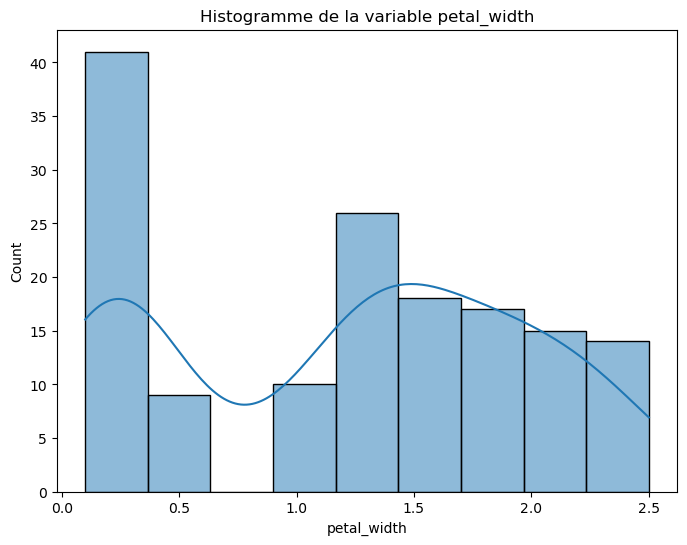

La variable petal_width ne suit pas une loi normale (p-value=0.0000)


In [241]:
# Remarques : Il n'y a pas trop de valeurs extremes, excepté sepal_width qui presente quelque valeurs extremes
# Pour faire un travail serieux, il faut prendre le temps d'identifier les valeurs extremes : (comme methode classique, on a :
# l'IQR et le z-score

# Analyse de la normalité avec le test de shapiro : (pour faire les test parametriques, il faut que la serie soit normalement distribué)

# Creation d'un histogramme et d'un test de normalité pour chaque variable 

# Boucle sur chaque colonne sauf la dernière
for column in df.columns[:-1]:
    # Création de l'histogramme avec une courbe de densité (KDE)
    plt.figure(figsize=(8, 6))
    sns.histplot(data=df, x=column, kde=True)
    plt.title(f"Histogramme de la variable {column}")
    plt.show()

    # Test de normalité
    statistic, p_value = stats.normaltest(df[column])
    if p_value < 0.05:
        print(f"La variable {column} ne suit pas une loi normale (p-value={p_value:.4f})")
    else:
        print(f"La variable {column} suit une loi normale (p-value={p_value:.4f})")


<Axes: xlabel='species', ylabel='count'>

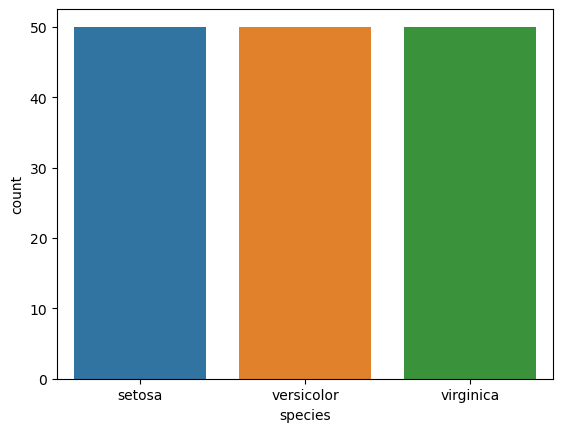

In [242]:
# Analyse des variables qualitatives
sns.countplot(x=df['species'])

([<matplotlib.patches.Wedge at 0x248564efa50>,
 [Text(0.5499999702695115, 0.9526279613277875, 'setosa'),
  Text(-1.0999999999999954, -1.0298943258065002e-07, 'versicolor'),
  Text(0.5500001486524352, -0.9526278583383436, 'virginica')])

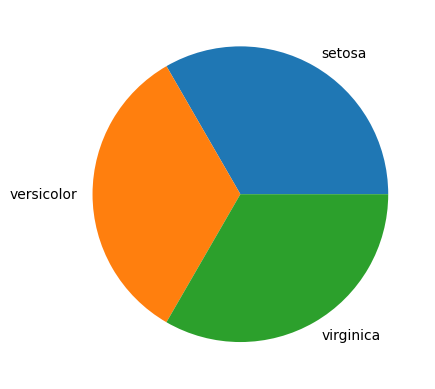

In [243]:
# Creation d'un tableau de fréquences pour la variable "species"
freq_table = (df['species'].value_counts())/len(df)
freq_table

# Cration d'un diagramme circulaire pour le tableau de frequence
plt.pie(freq_table, labels=freq_table.index)

In [244]:
# NB: on ne peut pas de test parametrique sur la longueur et la variable du petal car ces deux variables e sont pas normalement distribués

#### 3 Analyses bivariées

C:\Users\brech\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\brech\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\brech\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\brech\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

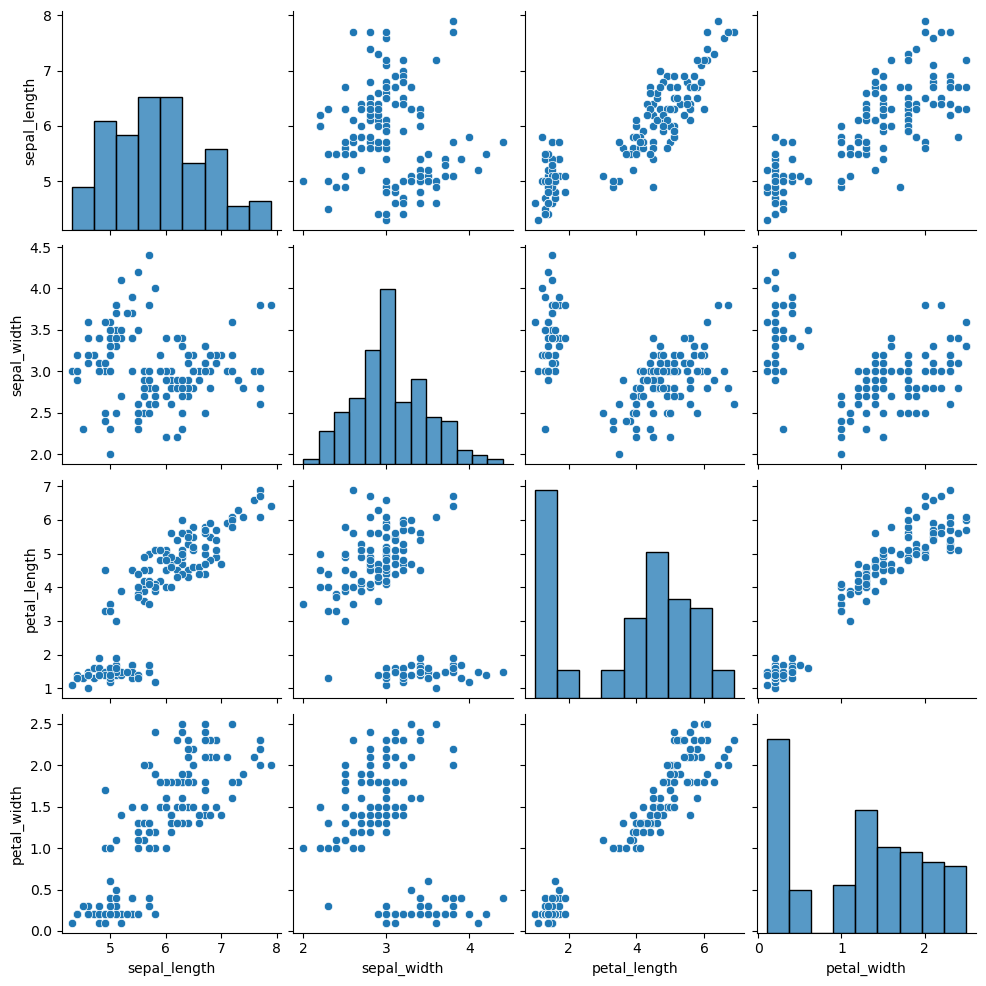

In [246]:
# Relation entre les variables quantitatives
sns.pairplot(df)

C:\Users\brech\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\brech\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\brech\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\brech\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

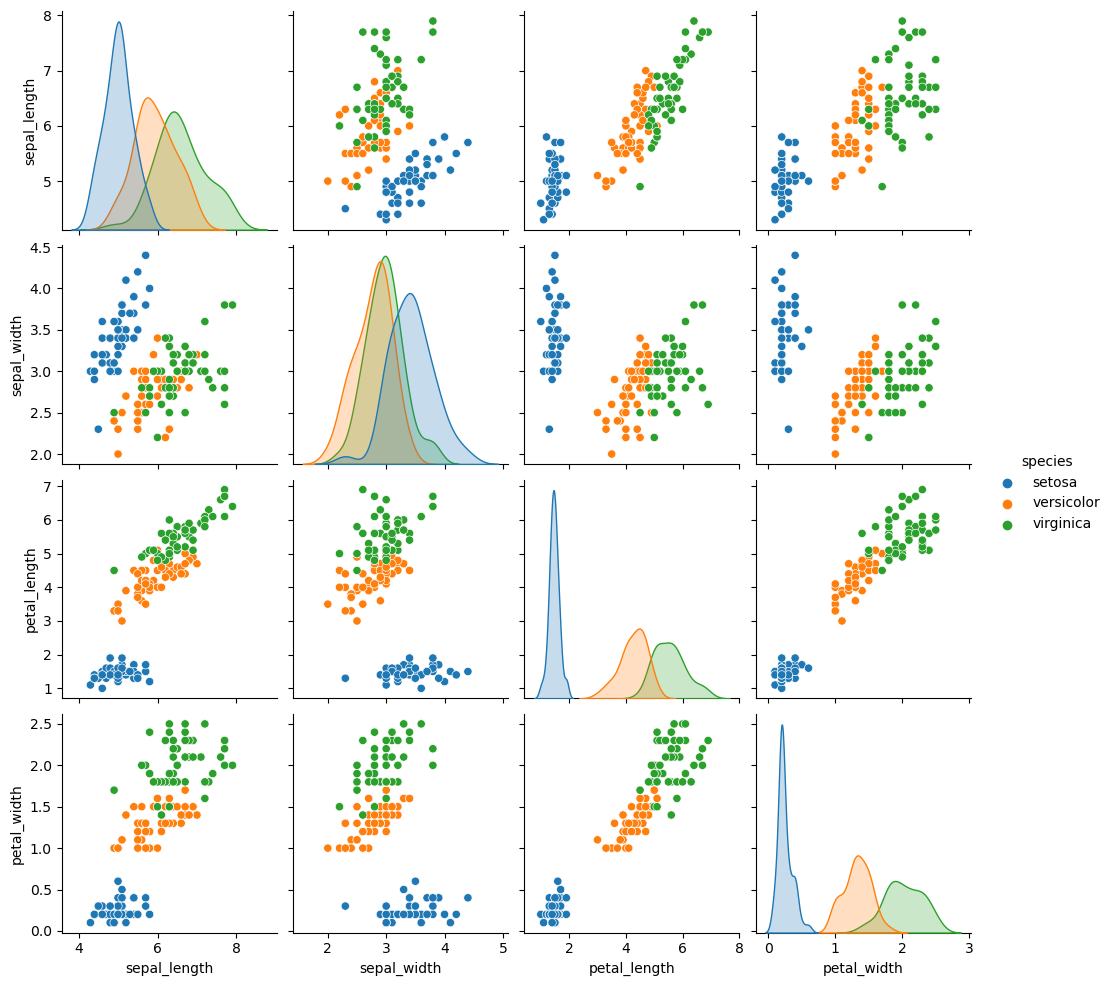

In [247]:
# pairplot
p=sns.pairplot(df, hue = 'species')

In [248]:
# On peut voir comment les variables evoluent, on a par exemple une relation lineaire entre la largeur et la longueuur du petal

<Axes: >

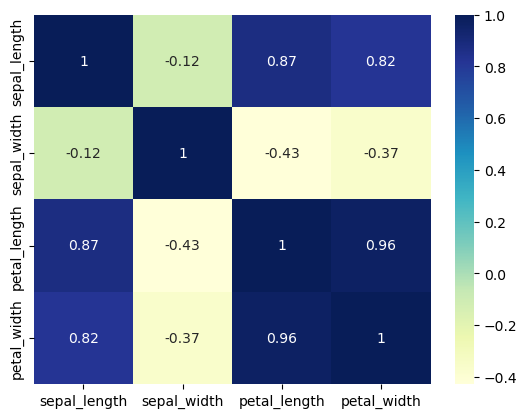

In [261]:
# Sélectionner uniquement les colonnes numériques
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Obtenir le tableau de correlation et la heatmap
corr_matrix = numeric_df.corr()

# Calcul des p-values pour chaque paire de variables
sns.heatmap(corr_matrix, annot=True, cmap="YlGnBu")

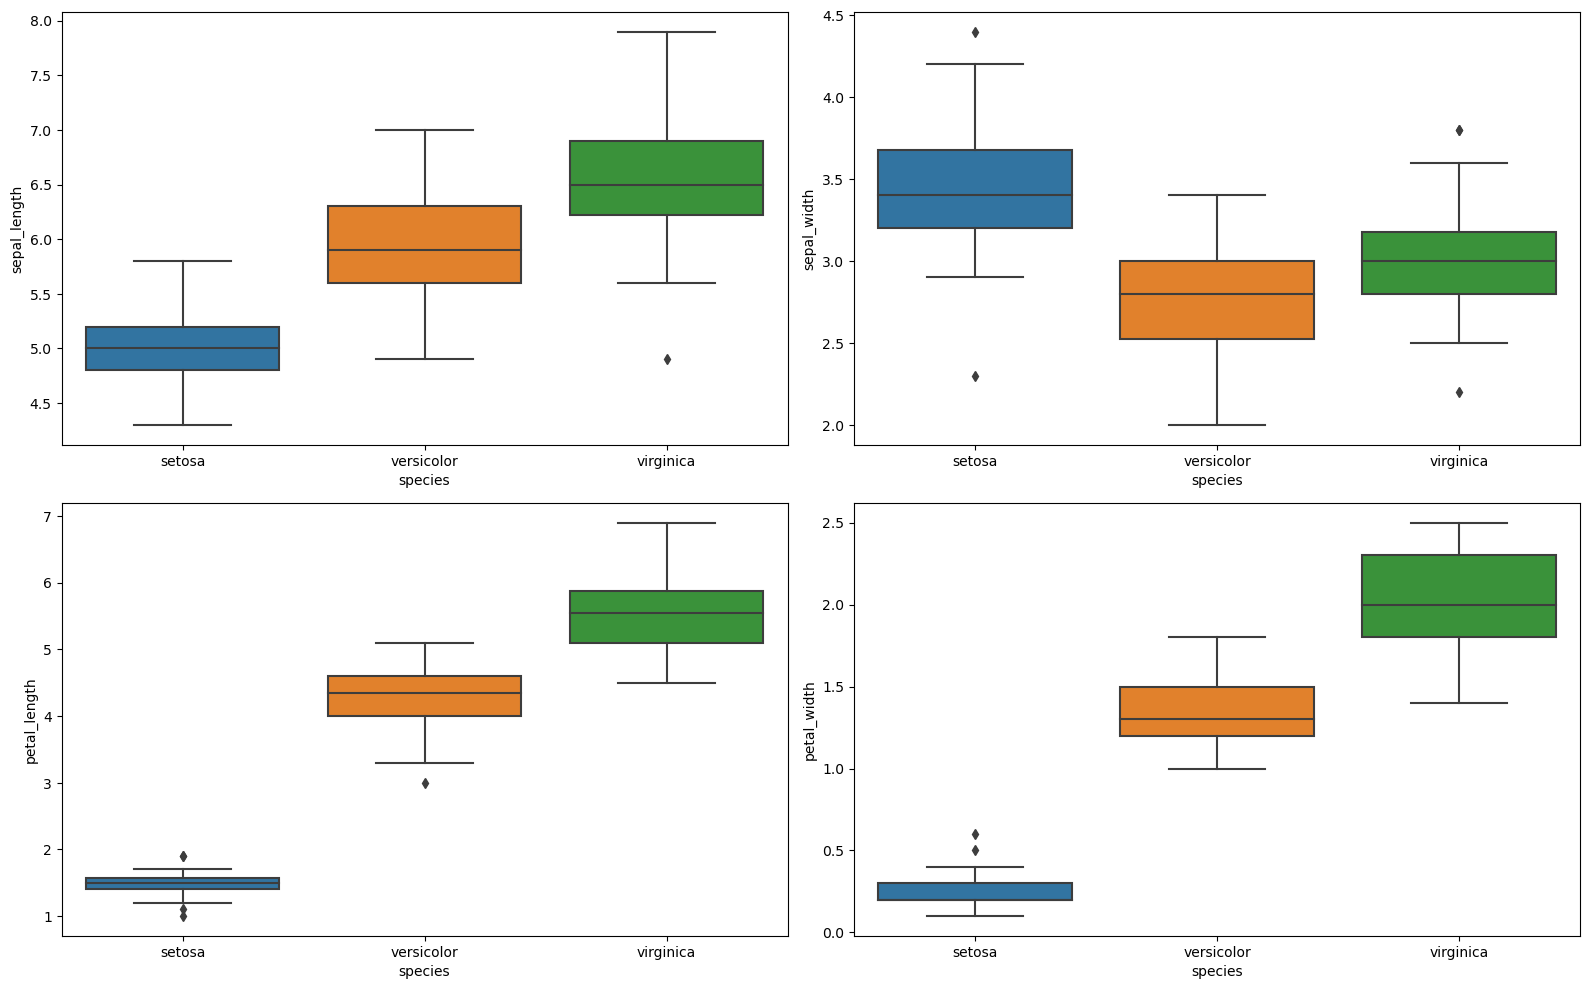

In [262]:
# l'heatmap confirme qu'il y'a une forte liaison entre la longueur et la largeur du petal (la corr=0.96)
# A partir de 0.60, on considere que la correlation est forte

#Analyse des relations entre les variables et la variété de fleur

# Création des boxplots pour chaque variable en fonction de l'espèce de la fleur
fig,ax = plt.subplots(nrows = 2, ncols=2, figsize=(16,10)) # plt.subplots : Crée une figure (fig) et une grille de sous-graphiques (ax).

# fig : La figure principale qui contient tous les sous-graphiques.
# ax : Un tableau (array) 2D de dimensions (2, 2) contenant les axes (sous-graphiques) pour chaque case de la grille.

row = 0
col = 0
for i in range(len(df.columns) -1):
    """
    pour les colonnes i = 0 et 1, rien ne se passe. on reste en row=0 c'est à dire en premiere ligne et lorsque le nbre de colonne est > à 1,
    on passe à la ligne 2
    """
    if col > 1: # Si la colonne actuelle dépasse 1 (on est à la 3e colonne, hors de la grille)
        row += 1 # On passe à la ligne suivante
        col = 0 # # On remet la colonne à 0 pour repartir du début de la nouvelle ligne
    axes = ax[row,col] # Sélectionne le sous-graphique (axe) correspondant à la position actuelle (row, col) dans la grille.
    sns.boxplot(x = df['species'], y = df[df.columns[i]],ax = axes)
    col += 1 # On incrémente la colonne (col) pour passer à la colonne suivante dans la grille.
plt.tight_layout() # Ajuste automatiquement l'espacement entre les sous-graphiques pour éviter les chevauchements de titres, étiquettes, etc.
# plt.title("Individual Features by Class")
plt.show()

In [263]:
# On constate par exemple que les fleurs virginica ont de long petal et de long sepal
# Ils ont egalement de large petal
# pour la largeur des sepal, on constate que les fleurs setosa ont de plus grande largeur

# Il faut maintenant confirmer cela par un test statistique, comme on a trois modalités, on va se diriger vers un test de kruskal wallis car on a vu
# que la normalite n'etait pas verifié pour trois variables

# Confirmation des liaisons avec un test de kruskal-wallis (test non parametrique) pour chaque variable

for column in df.columns[:-1]: # Parcourt toutes les colonnes du DataFrame sauf la dernière.
    _, p_value = stats.kruskal(*[df[column][df.species == species] for species in df.species.unique()])
    # _, p_value : Le test de Kruskal-Wallis retourne deux valeurs : la statistique de test (_, ignorée ici) et la p-value (p_value).
    if p_value < 0.05:
        print(f"La variable {column} est significativement différente entre les especes (p-values={p_value})")
    else:
        print(f"La variable {column} n'est pas significativement différente entre les especes (p-values={p_value})")

La variable sepal_length est significativement différente entre les especes (p-values=8.91873433246198e-22)
La variable sepal_width est significativement différente entre les especes (p-values=1.5692820940316782e-14)
La variable petal_length est significativement différente entre les especes (p-values=4.803973591157605e-29)
La variable petal_width est significativement différente entre les especes (p-values=3.261795552421968e-29)


#### 4. Analyse multivariée avec l'ACP

#### 4.1 Construction de l'ACP

In [270]:
# Importation des packages
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [271]:
# Separation des données en variables explicatives (X) et variable qualitative (Y)

# Ces lignes de code servent à séparer les données en variables explicatives (X) et variable cible (Y), souvent utilisé en machine learning pour 
# l'entraînement d'un modèle.
# iloc est utilisé pour la sélection basée sur l'indexation (position des colonnes).

X = df.iloc[:, :-1].values # On prend toutes les lignes et toutes les colonnes sauf la derniere colonne
# Les colonnes sélectionnées correspondent aux variables explicatives (ou features).

# .values convertit le résultat en tableau NumPy (ndarray), ce qui est souvent nécessaire pour les modèles d’apprentissage automatique.

# Variable qualitative

Y = df.iloc[:, -1].values # prends toutes les lignes et sélectionne la dernière colonne du dataset.
# Y contient les étiquettes de classe (ex: nom d’une fleur) ou valeurs à prédire.



In [276]:
# Standardisation des données
# Normaliser les données ("pour eviter l'effet taille")
scaler = StandardScaler() # c'est une classe
X_scaled = scaler.fit_transform(X) # permet de transformer en variable normalisée

In [278]:
# Reduction de dimension
pca = PCA()
X_pca=pca.fit_transform(X)

#### 4.2 Aide à l'interpretation

In [281]:
# Analyse des valeurs propres

# Construction d'un dataframe
comp = pd.DataFrame(
    {
        "Dimension" : ["Dim" + str(x + 1) for x in range(4)], 
        "Valeur propre" : pca.explained_variance_,
        "% variance expliquée" : np.round(pca.explained_variance_ratio_ * 100),
        "% cum. var. expliquée" : np.round(np.cumsum(pca.explained_variance_ratio_) * 100)
    },
    columns = ["Dimension", "Valeur propre", "% variance expliquée", "% cum. var. expliquée"]
)
comp

,Dimension,Valeur propre,% variance expliquée,% cum. var. expliquée
0,Dim1,4.228242,92.0,92.0
1,Dim2,0.242671,5.0,98.0
2,Dim3,0.078210,2.0,99.0
3,Dim4,0.023835,1.0,100.0


Text(3.25, 26, '25%')

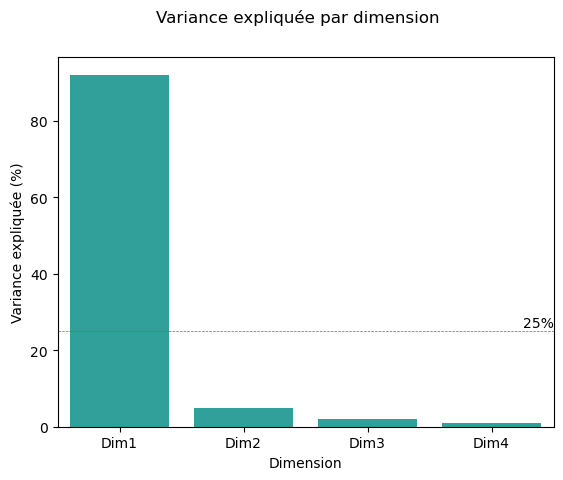

In [283]:
# Scree plot pour choisir le nombre de composantes principales
g_comp = sns.barplot(x = "Dimension",
                     y = "% variance expliquée",
                     palette = ["lightseagreen"],
                     data = comp)
g_comp.set(ylabel = "Variance expliquée (%)")
g_comp.figure.suptitle("Variance expliquée par dimension")
plt.axhline(y = 25, linewidth = .5, color = "dimgray", linestyle = "--") # 25 = 100/4 (nb dimensions)
plt.text(3.25, 26, "25%")


#### Qualité de représentation des variables et contribution à la formation des axes

**Qualité de représentation des variables (cosinus carré):**
- La qualité de représentation des variables est souvent mesurée à l'aide du carré du cosinus de l'angle entre les vecteurs représentant les variables et les axes principaux. 
- Si le cos2 d'une variable est supérieur à 0,5 sur un axe principal, cela signifie que cet axe représente bien la variable.

**Contribution des variables à la formation des axes (CTR):**
- La contribution des variables à la formation des axes indique l'importance relative de chaque variable pour expliquer la variabilité des données sur un axe principal donné.
- Il est important de noter que la somme des contributions des variables sur un axe principal donné est égale à 100 %.
En interprétant les contributions des variable à la formation des axes, il est courant de considérer les variables ayant une contribution supérieure à la contribution moyenne (100 % / nombre de variables) comme étant importantes pour la formation de l'axe principal considéré.



In [292]:
# Calcul du cosinus carré des variables

cos_squared = np.square(pca.components_)

# Creation d'un dataframe pandas avec le cosinus carré des variables
df_cos_squared = pd.DataFrame(cos_squared, columns=['PC{}'.format(i+1) for i in range(X.shape[1])])
df_cos_squared.index = df.columns[:-1] # pour designer les noms des lignes qui seront egales au nom de la derniere colonne

print(df_cos_squared)

                   PC1       PC2       PC3       PC4
sepal_length  0.130600  0.007144  0.733885  0.128371
sepal_width   0.431109  0.533136  0.030058  0.005697
petal_length  0.338759  0.357497  0.005812  0.297932
petal_width   0.099532  0.102223  0.230245  0.568000


In [288]:
# Interpretation : PC1 + PC2 represente le premier axe factoriel
# Ici nous avons considéré que deux axes
# la variable sepal_width et petal_length sont par exemple bien représentées sur les deux premiers axes factoriel
# certaines variables sont bien representées sur les autres axes -mais ici, on ne s'interesse qu'aux deux premiers axes factoriels)

In [193]:
# Contribution à la formation de l'axe 

##  Pour comparer les contributions absolues (brutes donc non normalisées) des variables à la variance expliquée par chaque 
##  composante principale.


# Obtenir les composantes principales
components = pca.components_

n_components = X.shape[1]
# X.shape renvoie un tuple de la forme (nombre_de_lignes, nombre_de_colonnes), c'est-à-dire (n_samples, n_features).
# X.shape[1] extrait le deuxième élément du tuple, soit le nombre de colonnes (nombre de variables explicatives).

features_names=df.columns[0:4]
# Calculer la contribution des variables à la formation des axes
loadings = pca.components_.T
eigenvalues = pca.explained_variance_
variable_contributions = (loadings**2) *eigenvalues

# Creer un Dataframe pour faciliter l'affichage des resultats
column_names = [f'PC{i+1}_contrib' for i in range(n_components)]
variable_contrib_df = pd.DataFrame(variable_contributions, columns=column_names, index=features_names)

print(variable_contrib_df)

              PC1_contrib  PC2_contrib  PC3_contrib  PC4_contrib
sepal_length     0.552210     0.104617     0.026494     0.002372
sepal_width      0.030207     0.129376     0.027960     0.002436
petal_length     3.103041     0.007294     0.000455     0.005488
petal_width      0.542784     0.001383     0.023301     0.013538


In [290]:
# Contribution des variables à la formation des axes
##  Pour comparer les contributions relatives en pourcentage ( donc normalisées) des variables à la variance 
# expliquée par chaque composante principale.

components = pca.components_
n_components = X.shape[1]
features_names=df.columns[0:4]
# Calculer la contribution des variables à la formation des axes
loadings = pca.components_.T # Matrice des coefficients (n_features, n_components)
eigenvalues = pca.explained_variance_ # # Valeurs propres (n_components,)
variable_contributions = (loadings**2) * eigenvalues # (n_features, n_components)

# Convertir les contributions en pourcentage
variable_contrib_percent = (variable_contributions / eigenvalues) * 100

# Créer un DataFrame pour faciliter l'affichage des résultats
column_names = [f'PC{i+1}_contrib' for i in range(n_components)]
variable_contrib_df = pd.DataFrame(variable_contrib_percent, columns=column_names, index=features_names)

print(variable_contrib_df)


              PC1_contrib  PC2_contrib  PC3_contrib  PC4_contrib
sepal_length    13.060027    43.110881    33.875875     9.953217
sepal_width      0.714406    53.313572    35.749736    10.222286
petal_length    73.388453     3.005808     0.581194    23.024545
petal_width     12.837115     0.569738    29.793195    56.799951


#### Qualité de représentation des individus et contribution à la formation des axes
Lors de l'analyse en composantes principales (ACP), il est important de mesurer la qualité de représentation des individus sur les axes principaux et leur contribution à la formation de ces axes.
- **Qualité de représentation des individus (cosinus carré)**
- **Contribution des individus à la formation des axes (CTR)**

En interprétant les contributions des individus à la formation des axes, il est courant de considérer les individus ayant une contribution supérieure à la contribution moyenne (100 % / nombre d'individus) comme étant importants pour la formation de l'axe principal considéré.


In [197]:
# Calculer la contribution des individus à la formation des axes
eigenvalues = pca.explained_variance_
contributions = (X_pca**2) / (X_pca.shape[0] * eigenvalues)

# Convertir les contributions en pourcentage
contrib_percent = contributions * 100

# Créer un DataFrame pour faciliter l'affichage des résultats
column_names = [f'PC{i+1}_contrib' for i in range(n_components)]
contrib_df = pd.DataFrame(contrib_percent, columns=column_names)

print(contrib_df)

     PC1_contrib  PC2_contrib  PC3_contrib  PC4_contrib
0       1.135938     0.280255     0.006642     0.000143
1       1.161486     0.086068     0.377577     0.274281
2       1.315955     0.057720     0.002731     0.011153
3       1.188344     0.278331     0.008490     0.159756
4       1.173994     0.293315     0.069167     0.104961
..           ...          ...          ...          ...
145     0.595923     0.096615     0.269548     5.080547
146     0.367724     0.386979     0.126661     1.809735
147     0.490813     0.017084     0.145127     0.524978
148     0.569753     0.037368     4.458903     0.055625
149     0.304717     0.219494     1.122655     0.672313

[150 rows x 4 columns]


#### 5. Representation graphique et interpretation

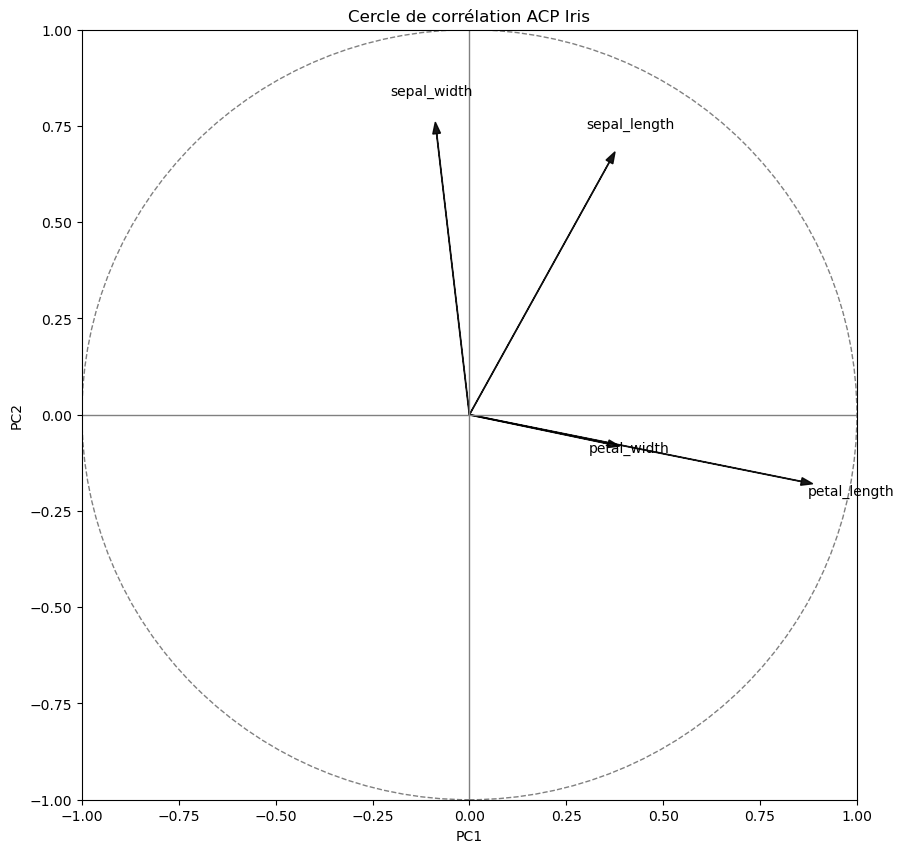

In [199]:
# Creer le cercle de corrélation
coeff = np.transpose(pca.components_[0:2, :])
n = coeff.shape[0]
xs = np.array([1, 0])
ys = np.array([0, 1])

# Créer la figure
plt.figure(figsize=(10, 10))

# Placer les vecteurs des variables
for i in range(n):
    plt.arrow(0, 0, coeff[i, 0], coeff[i, 1], color='k', alpha=0.9, head_width=0.02)
    plt.text(coeff[i, 0] * 1.15, coeff[i, 1] * 1.15, features_names[i], color='k', ha='center', va='center')

# Placer le cercle unitaire
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
plt.gca().add_artist(circle)

# Ajuster les limites et les axes
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Cercle de corrélation ACP Iris')

# Afficher la figure
plt.show()

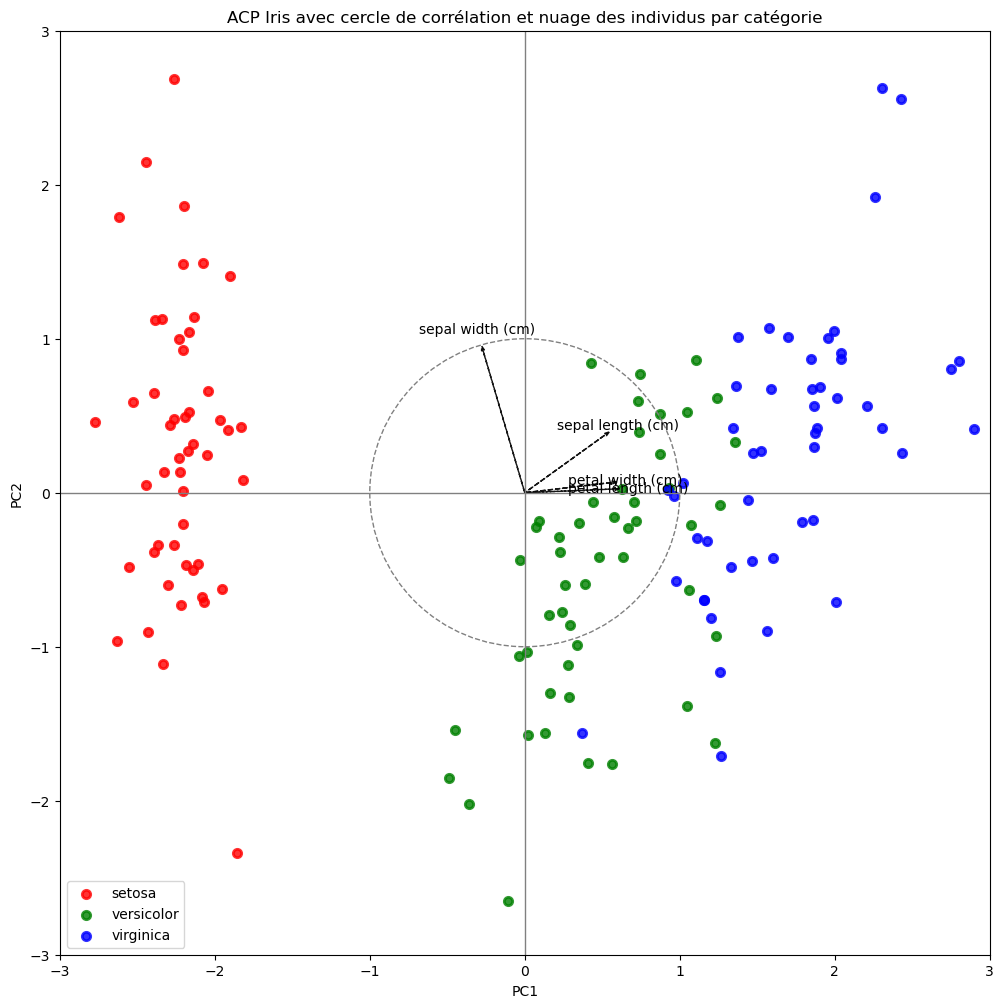

In [200]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

# Charger les données Iris
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

# Normaliser les données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Appliquer l'ACP
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Créer le cercle de corrélation
coeff = np.transpose(pca.components_[0:2, :])
n = coeff.shape[0]

# Créer la figure
fig, ax = plt.subplots(figsize=(12, 12))

# Visualiser les catégories d'espèces avec les couleurs
colors = ['r', 'g', 'b']
lw = 2

for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], color=color, alpha=.8, lw=lw, label=target_name)

# Placer les vecteurs des variables
for i in range(n):
    plt.arrow(0, 0, coeff[i, 0], coeff[i, 1], color='k', alpha=0.9, head_width=0.02, linestyle='--')
    plt.text(coeff[i, 0] * 1.15, coeff[i, 1] * 1.15, iris.feature_names[i], color='k', ha='center', va='center')

# Placer le cercle unitaire
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
plt.gca().add_artist(circle)

# Ajuster les limites et les axes
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('ACP Iris avec cercle de corrélation et nuage des individus par catégorie')

# Afficher la légende
plt.legend(loc='best', shadow=False, scatterpoints=1)

# Afficher la figure
plt.show()

# AFC

In [132]:
# Importation des packages
!pip install fanalysis
import pandas as pd
from fanalysis.ca import CA
import numpy as np
import matplotlib.pyplot as plt

In [16]:
import os
print(os.getcwd())  # Affiche le chemin du répertoire actuel

# print(os.listdir())  # Affiche le contenu du dossier actuel
# os.chdir("chemin/vers/le/dossier")  # Remplace par le chemin de ton choix

C:\Users\brech\MonFichierDeTravail\ML


In [133]:
df = pd.read_excel("C:/Users/brech/Desktop/dossier de taff/ML/election_2022_FR.xlsx")
# df = pd.read_excel(r"C:\Users\brech\Desktop\dossier de taff\ML\election_2022_FR.xlsx")
df

,Departement,Nathalie ARTHAUD,Fabien ROUSSEL,Emmanuel MACRON,Jean LASSALLE,Marine LE PEN,Éric ZEMMOUR,Jean-Luc MÉLENCHON,Anne HIDALGO,Yannick JADOT,Valérie PÉCRESSE,Philippe POUTOU,Nicolas DUPONT-AIGNAN
0,Seine-Saint-Denis,2756,11642,110118,6805,64543,27969,266632,5890,19352,17481,3663,6300
1,Val-de-Marne,2504,14954,171409,8944,69599,43430,192427,8276,31904,32522,3730,9359
2,Val-d'Oise,2392,10060,138166,9101,91081,37564,175666,6094,20710,26403,3352,8996
3,Essonne,2831,13480,164503,11610,105862,39284,167310,7944,29562,33046,4306,15203
4,Hauts-de-Seine,2306,13170,287494,11260,64812,62761,199640,10518,47103,62231,3704,9743
5,Paris,2891,17267,372820,12139,58429,86088,317372,22901,80268,69564,5732,9591
6,Seine-et-Marne,3440,12843,165208,13797,155738,47893,170969,7853,26718,36828,4600,15042
7,Yvelines,2774,11721,246062,13687,101398,64407,168585,9046,40470,61296,3963,13097


### 2 Description des données

In [134]:
# Extraction des noms de colonnes et de la colonne "Departement"
col_names = list(df.columns)[1:]
dept_names = df['Departement']

In [148]:
col_names

['Nathalie ARTHAUD',
 'Fabien ROUSSEL',
 'Emmanuel MACRON',
 'Jean LASSALLE',
 'Marine LE PEN',
 'Éric ZEMMOUR',
 'Jean-Luc MÉLENCHON',
 'Anne HIDALGO',
 'Yannick JADOT',
 'Valérie PÉCRESSE',
 'Philippe POUTOU',
 'Nicolas DUPONT-AIGNAN']

In [142]:
dept_names = df['Departement']
dept_names

0    Seine-Saint-Denis
1         Val-de-Marne
2           Val-d'Oise
3              Essonne
4       Hauts-de-Seine
5                Paris
6       Seine-et-Marne
7             Yvelines
Name: Departement, dtype: object

In [110]:
# Extraction des données numériques
x = df[col_names].values
x

array([[  2756,  11642, 110118,   6805,  64543,  27969, 266632,   5890,
         19352,  17481,   3663,   6300],
       [  2504,  14954, 171409,   8944,  69599,  43430, 192427,   8276,
         31904,  32522,   3730,   9359],
       [  2392,  10060, 138166,   9101,  91081,  37564, 175666,   6094,
         20710,  26403,   3352,   8996],
       [  2831,  13480, 164503,  11610, 105862,  39284, 167310,   7944,
         29562,  33046,   4306,  15203],
       [  2306,  13170, 287494,  11260,  64812,  62761, 199640,  10518,
         47103,  62231,   3704,   9743],
       [  2891,  17267, 372820,  12139,  58429,  86088, 317372,  22901,
         80268,  69564,   5732,   9591],
       [  3440,  12843, 165208,  13797, 155738,  47893, 170969,   7853,
         26718,  36828,   4600,  15042],
       [  2774,  11721, 246062,  13687, 101398,  64407, 168585,   9046,
         40470,  61296,   3963,  13097]], dtype=int64)

In [180]:
row_sum

array([ 543151,  589058,  529585,  594941,  774742, 1055062,  660929,
        736506], dtype=int64)

#### 2.1 Distribution des votes des departements par candidat


In [60]:
# Calcul du profil ligne:

# Le profil ligne d’une modalité (ligne) est la distribution des effectifs de cette modalité dans chaque colonne, normalisée par la somme de la ligne.

row_sum = np.sum(x, axis=1) # axis=1 : signifie que la somme est effectuée le long des colonnes, donc ligne par ligne.
row_profile = x / row_sum[:, np.newaxis]
# np.newaxis permet de faire en sorte que x et row_sum puisse avoir la meme structure pour la division

## Ex:
# print(row_sum)  
# [ 6 15 ]  (Tableau 1D de taille (2,))
# print(row_sum[:, np.newaxis])  
# [[ 6]
#  [15]]  (Tableau 2D de taille (2,1))

# Ici x est de forme (8,12) et row_sum[:, np.newaxis] etant de la forme (8,1) 


# Affichage
print("Profil ligne:")
print(pd.DataFrame(row_profile, index=dept_names, columns=col_names))

Profil ligne:
                   Nathalie ARTHAUD  Fabien ROUSSEL  Emmanuel MACRON  \
Departement                                                            
Seine-Saint-Denis          0.005074        0.021434         0.202739   
Val-de-Marne               0.004251        0.025386         0.290988   
Val-d'Oise                 0.004517        0.018996         0.260895   
Essonne                    0.004758        0.022658         0.276503   
Hauts-de-Seine             0.002976        0.016999         0.371084   
Paris                      0.002740        0.016366         0.353363   
Seine-et-Marne             0.005205        0.019432         0.249963   
Yvelines                   0.003766        0.015914         0.334094   

                   Jean LASSALLE  Marine LE PEN  Éric ZEMMOUR  \
Departement                                                     
Seine-Saint-Denis       0.012529       0.118831      0.051494   
Val-de-Marne            0.015184       0.118153      0.073728   
Val-d

### 2.2 Repartition des votes obtenus par les candidats selon les departements

In [76]:
# Calcul du profil colone
# Le profil colonne d’une modalité (colonne) est la distribution des effectifs de cette modalité dans chaque ligne, normalisée 
# par la somme de la colonne.

col_sum = np.sum(x, axis=0)
col_profile = x / col_sum[np.newaxis, :]

# Affichage
print("Profil colonne")
print(pd.DataFrame(col_profile, index=dept_names, columns = col_names))

Profil colonne
                   Nathalie ARTHAUD  Fabien ROUSSEL  Emmanuel MACRON  \
Departement                                                            
Seine-Saint-Denis          0.125879        0.110732         0.066505   
Val-de-Marne               0.114369        0.142233         0.103522   
Val-d'Oise                 0.109254        0.095685         0.083445   
Essonne                    0.129305        0.128214         0.099351   
Hauts-de-Seine             0.105326        0.125265         0.173631   
Paris                      0.132045        0.164233         0.225163   
Seine-et-Marne             0.157121        0.122155         0.099777   
Yvelines                   0.126701        0.111483         0.148608   

                   Jean LASSALLE  Marine LE PEN  Éric ZEMMOUR  \
Departement                                                     
Seine-Saint-Denis       0.077911       0.090719      0.068318   
Val-de-Marne            0.102401       0.097825      0.106083   
Val-

#### 2.3 Analyse des votes

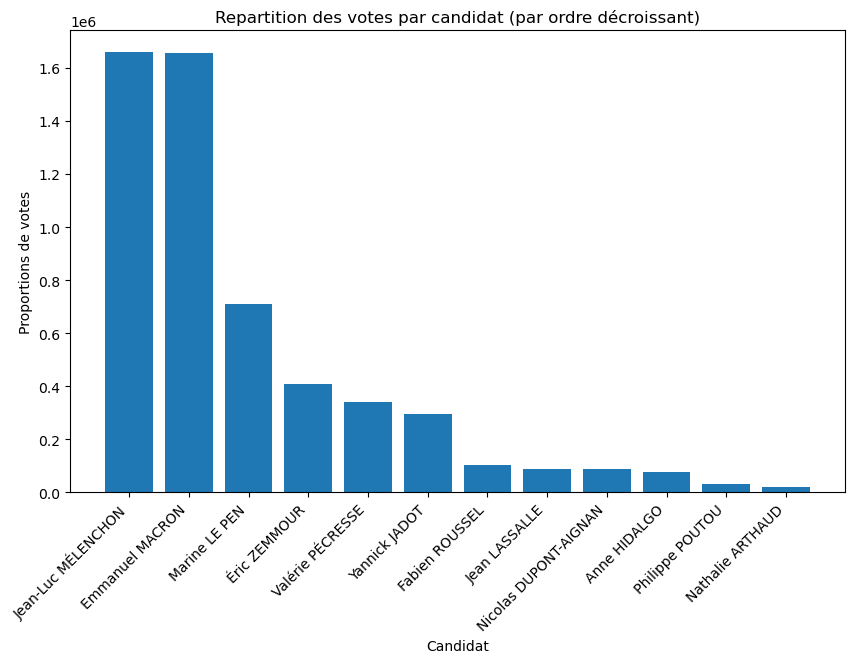

In [81]:
# Extraction des noms de colonnes
col_names = list(df.columns)[1:]

# Calcul de la somme des votes pour chaque candidat
total_votes = df[col_names].sum()

# Calcul des proportions pour chaque candidat
prop_votes = total_votes
# Tri des proportions de la plus grande à la plus petite
prop_votes = prop_votes.sort_values(ascending=False)
# .sort_values(): Méthode de Pandas qui trie les valeurs d'une Série en ordre croissant par défaut.
# ascending=False: Argument qui force le tri décroissant (du plus grand au plus petit).

# Creation du diagramme en barres
fig, ax = plt.subplots(figsize=(10,6))
ax.bar(prop_votes.index, prop_votes) # prop_votes.index renvoie les indices (ou étiquettes des lignes) de la Série Pandas prop_votes

# Ajout de labels et de titres
ax.set_xlabel('Candidat')
ax.set_ylabel('Proportions de votes')
ax.set_title('Repartition des votes par candidat (par ordre décroissant)')

# Rotation des noms des candidats
plt.xticks(rotation=45, ha='right')

# Affichage du diagramme
plt.show()

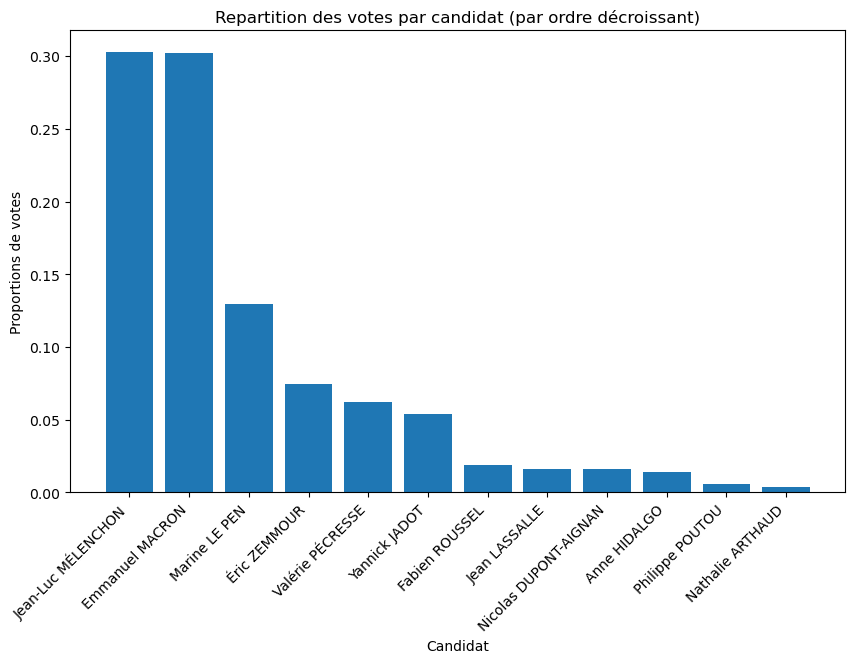

In [89]:
# Extraction  des noms de colonnes
col_names = list(df.columns)[1:]

# Calcul de la somme de votes pour chaque candidat
total_votes = df[col_names].sum()

# Calcul des proportions pour chaque candidat
prop_votes = total_votes / total_votes.sum()

# Tri des proportions de la plus grande à la plus petite
prop_votes = prop_votes.sort_values(ascending=False)

# Creation du diagramme en barres
fig, ax = plt.subplots(figsize=(10,6))
ax.bar(prop_votes.index, prop_votes)

# Ajout de labels et de titres
ax.set_xlabel('Candidat')
ax.set_ylabel('Proportions de votes')
ax.set_title('Repartition des votes par candidat (par ordre décroissant)')

# Rotation des noms des candidats
plt.xticks(rotation=45, ha='right')

# Affichage du diagramme
plt.show()



In [116]:
total_votes

Nathalie ARTHAUD           21894
Fabien ROUSSEL            105137
Emmanuel MACRON          1655780
Jean LASSALLE              87343
Marine LE PEN             711462
Éric ZEMMOUR              409396
Jean-Luc MÉLENCHON       1658601
Anne HIDALGO               78522
Yannick JADOT             296087
Valérie PÉCRESSE          339371
Philippe POUTOU            33050
Nicolas DUPONT-AIGNAN      87331
dtype: int64

## 4 AFC pratique
#### 4.1 Application de l'AFC avec fanalysis

In [144]:
df = df.set_index("Departement") #  Cela signifie que l'on transforme la colonne "Departement" en index du DataFrame df.

In [146]:
df.values

array([[  2756,  11642, 110118,   6805,  64543,  27969, 266632,   5890,
         19352,  17481,   3663,   6300],
       [  2504,  14954, 171409,   8944,  69599,  43430, 192427,   8276,
         31904,  32522,   3730,   9359],
       [  2392,  10060, 138166,   9101,  91081,  37564, 175666,   6094,
         20710,  26403,   3352,   8996],
       [  2831,  13480, 164503,  11610, 105862,  39284, 167310,   7944,
         29562,  33046,   4306,  15203],
       [  2306,  13170, 287494,  11260,  64812,  62761, 199640,  10518,
         47103,  62231,   3704,   9743],
       [  2891,  17267, 372820,  12139,  58429,  86088, 317372,  22901,
         80268,  69564,   5732,   9591],
       [  3440,  12843, 165208,  13797, 155738,  47893, 170969,   7853,
         26718,  36828,   4600,  15042],
       [  2774,  11721, 246062,  13687, 101398,  64407, 168585,   9046,
         40470,  61296,   3963,  13097]], dtype=int64)

In [197]:
df.index.values

array(['Seine-Saint-Denis', 'Val-de-Marne', "Val-d'Oise", 'Essonne',
       'Hauts-de-Seine', 'Paris', 'Seine-et-Marne', 'Yvelines'],
      dtype=object)

In [201]:
df.columns.values

array(['Nathalie ARTHAUD', 'Fabien ROUSSEL', 'Emmanuel MACRON',
       'Jean LASSALLE', 'Marine LE PEN', 'Éric ZEMMOUR',
       'Jean-Luc MÉLENCHON', 'Anne HIDALGO', 'Yannick JADOT',
       'Valérie PÉCRESSE', 'Philippe POUTOU', 'Nicolas DUPONT-AIGNAN'],
      dtype=object)

In [150]:
# On crée une instance de la classe CA en pasant les etiquettes de lignes et de colonnes
my_ca = CA(row_labels=df.index.values, col_labels=df.columns.values, stats=True)
# row_labels=df.index.values : Récupère les noms des lignes
# col_labels=df.columns.values : Récupère les noms des colonnes
# stats=True : Demande des statistiques supplémentaires (Les valeurs propres (variance expliquée), Les contributions des lignes et colonnes, 
# Les coordonnées factorielles)

In [152]:
# Estime l'AFC
my_ca.fit(df.values)

CA(col_labels=array(['Nathalie ARTHAUD', 'Fabien ROUSSEL', 'Emmanuel MACRON',
       'Jean LASSALLE', 'Marine LE PEN', 'Éric ZEMMOUR',
       'Jean-Luc MÉLENCHON', 'Anne HIDALGO', 'Yannick JADOT',
       'Valérie PÉCRESSE', 'Philippe POUTOU', 'Nicolas DUPONT-AIGNAN'],
      dtype=object),
   row_labels=array(['Seine-Saint-Denis', 'Val-de-Marne', "Val-d'Oise", 'Essonne',
       'Hauts-de-Seine', 'Paris', 'Seine-et-Marne', 'Yvelines'],
      dtype=object))

### 4.2 Aides à l'interpretation
#### 4.2.1 Choix du nombre d'axe factoriel

In [155]:
# Identification des valeurs propres
my_ca.eig_

array([[3.67708156e-02, 2.41324630e-02, 1.19731847e-03, 5.41407476e-04,
        1.51718248e-04, 1.35166582e-04, 2.74627897e-05],
       [5.84068396e+01, 3.83320541e+01, 1.90182313e+00, 8.59972756e-01,
        2.40989579e-01, 2.14698878e-01, 4.36219520e-02],
       [5.84068396e+01, 9.67388937e+01, 9.86407168e+01, 9.95006896e+01,
        9.97416792e+01, 9.99563780e+01, 1.00000000e+02]])

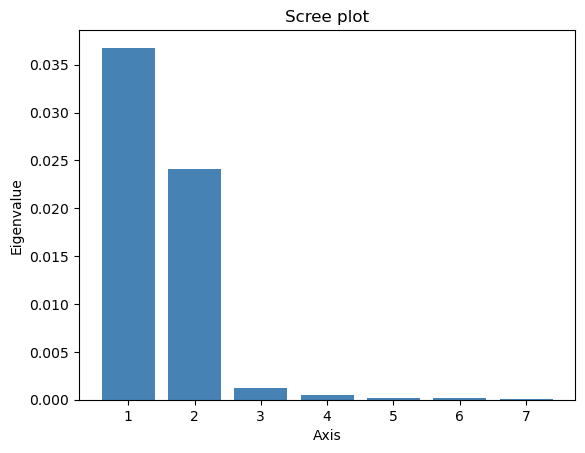

In [157]:
# Graphique des valeurs propres
my_ca.plot_eigenvalues()

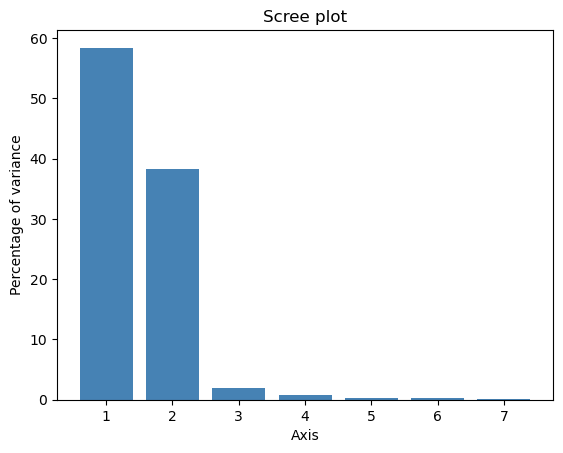

In [159]:
my_ca.plot_eigenvalues(type="percentage")

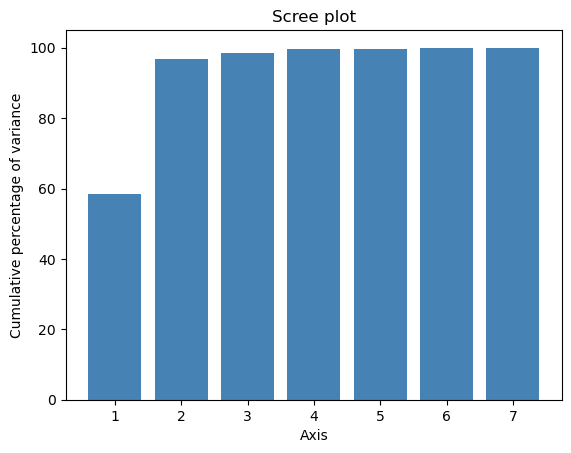

In [161]:
my_ca.plot_eigenvalues(type="cumulative")

### 4.2.2 Analyse des qualités de réprésentation (cos 2)
#### 4.2.2.1 Analyse suivant le profil ligne (les départements)

Premier axe factoriel


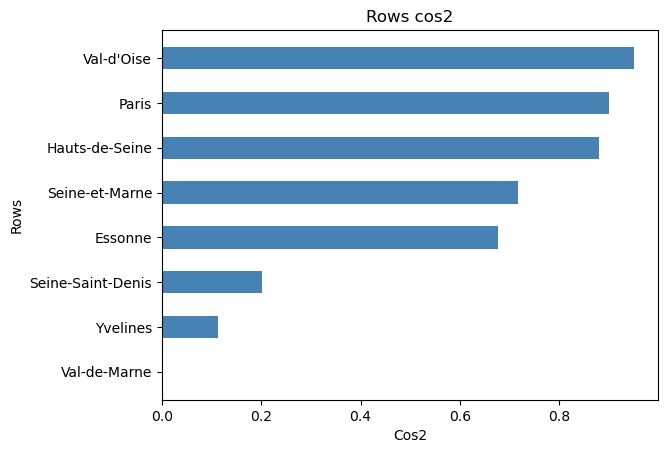

Second axe factoriel


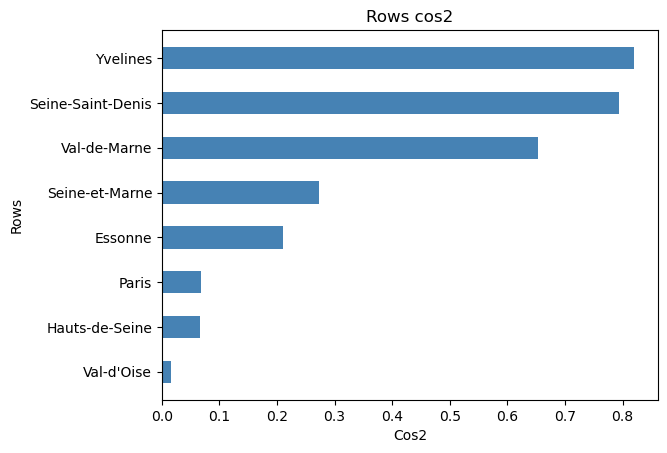

In [164]:
# Classement des points colonnes en fonction de leur contribution au 1er axe
print("Premier axe factoriel")
my_ca.plot_row_cos2(num_axis=1)
print("Second axe factoriel")
my_ca.plot_row_cos2(num_axis=2)

Premier axe factoriel


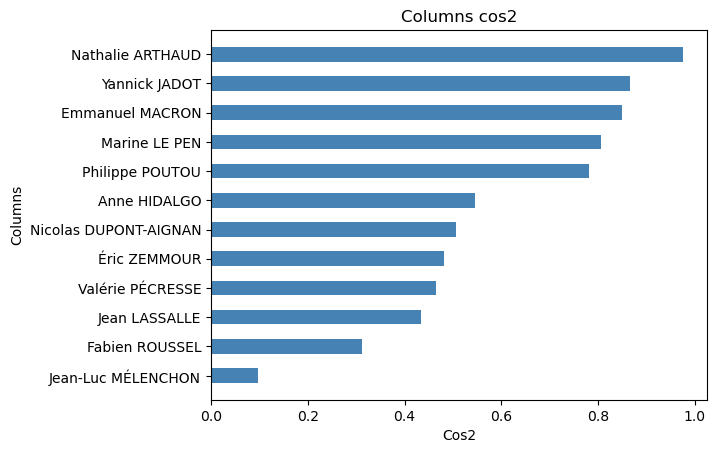

Second axe factoriel


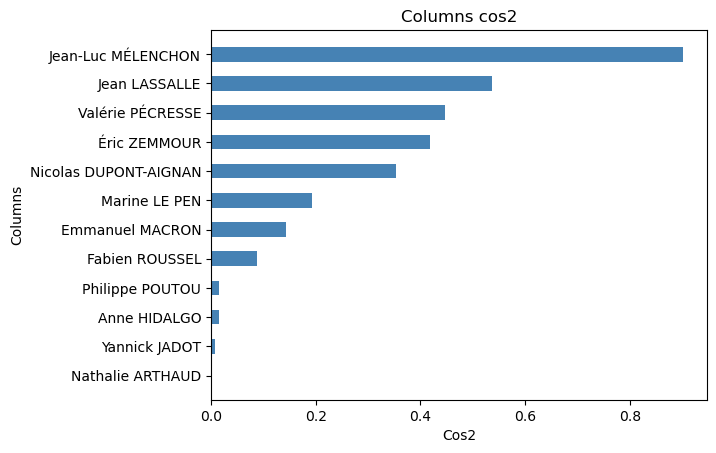

In [166]:
#### Profil colonne (les Candidats)

print("Premier axe factoriel")
my_ca.plot_col_cos2(num_axis=1)
print("Second axe factoriel")
my_ca.plot_col_cos2(num_axis=2)

### Analyse des contributions

#### Profil lignes (Departement)

Premier axe


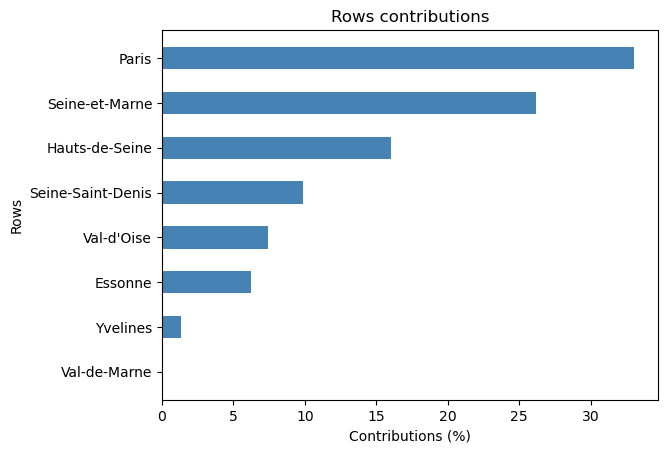

Second axe


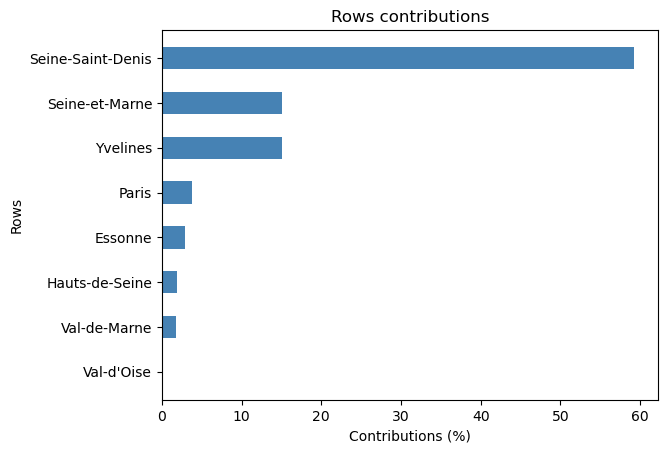

In [169]:
# Analyse  du premier plan factoriel - les départements
print("Premier axe")
my_ca.plot_row_contrib(num_axis=1)
print("Second axe")
my_ca.plot_row_contrib(num_axis=2)

#### Profil colonne (Candidats)

Premier axe


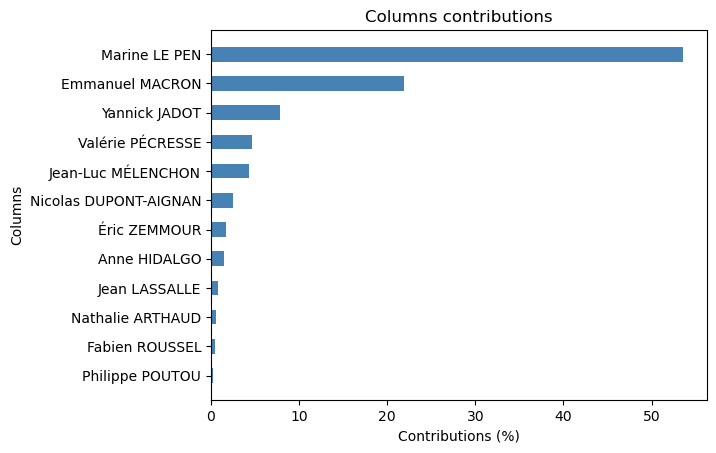

Second axe


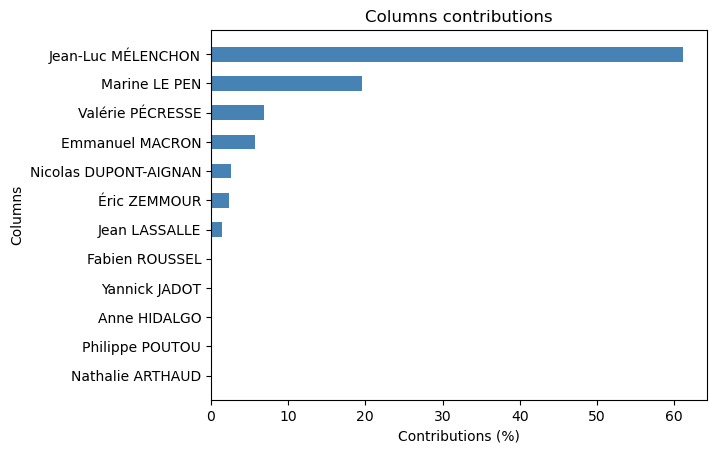

In [172]:
# Analyse  du premier plan factoriel - les départements
print("Premier axe")
my_ca.plot_col_contrib(num_axis=1)
print("Second axe")
my_ca.plot_col_contrib(num_axis=2)

### Tableau global 
#### Coordonnées, contribution et les cosinus carré des départements sur les axes factoriels

In [175]:
info_dep=my_ca.row_topandas()
info_dep

,row_coord_dim1,row_coord_dim2,row_coord_dim3,row_coord_dim4,row_coord_dim5,row_coord_dim6,row_coord_dim7,row_contrib_dim1,row_contrib_dim2,row_contrib_dim3,...,row_contrib_dim5,row_contrib_dim6,row_contrib_dim7,row_cos2_dim1,row_cos2_dim2,row_cos2_dim3,row_cos2_dim4,row_cos2_dim5,row_cos2_dim6,row_cos2_dim7
Seine-Saint-Denis,0.191079,0.380021,0.030236,-0.004748,0.009058,0.006421,-0.003586,9.834411,59.270531,7.562694,...,5.356138,3.021325,4.638140,0.200611,0.793494,0.005023,0.000124,0.000451,0.000227,0.000071
Val-de-Marne,0.004078,0.063592,-0.012599,0.032617,-0.029839,0.003655,-0.001451,0.004859,1.799964,1.423984,...,63.037884,1.061684,0.823375,0.002688,0.653406,0.025647,0.171895,0.143866,0.002159,0.000340
Val-d'Oise,0.167802,0.021171,0.014203,-0.019675,-0.006696,-0.014202,0.012729,7.394855,0.179359,1.627124,...,2.853726,14.410030,56.973065,0.951167,0.015141,0.006815,0.013077,0.001515,0.006813,0.005473
Essonne,0.145319,-0.081035,-0.034878,0.044483,0.018924,0.001163,0.003011,6.230463,2.952053,11.022383,...,25.606399,0.108532,3.581465,0.675806,0.210147,0.038930,0.063324,0.011460,0.000043,0.000290
Hauts-de-Seine,-0.204164,-0.056301,0.044966,0.011944,0.004103,-0.017344,-0.003796,16.014697,1.855616,23.857022,...,1.567576,31.441448,7.413691,0.880328,0.066944,0.042702,0.003013,0.000356,0.006353,0.000304
Paris,-0.251287,0.068986,-0.043929,-0.017927,0.002796,0.001509,0.000513,33.038369,3.794036,31.008622,...,0.991212,0.324310,0.184481,0.899943,0.067826,0.027503,0.004580,0.000111,0.000032,0.000004
Seine-et-Marne,0.282350,-0.173910,-0.021738,-0.026219,-0.002606,-0.004689,-0.007419,26.129505,15.104514,4.756483,...,0.539667,1.960676,24.154376,0.716855,0.271960,0.004249,0.006181,0.000061,0.000198,0.000495
Yvelines,-0.060860,-0.164415,0.040876,-0.007726,0.000732,0.021904,0.002136,1.352841,15.043927,18.741689,...,0.047398,47.671995,2.231406,0.112407,0.820361,0.050706,0.001811,0.000016,0.014560,0.000138


#### Coordonnées, contribution et les cosinus carré des candidats sur les axes factoriels

In [178]:
info_candidat=my_ca.col_topandas()
info_candidat

,col_coord_dim1,col_coord_dim2,col_coord_dim3,col_coord_dim4,col_coord_dim5,col_coord_dim6,col_coord_dim7,col_contrib_dim1,col_contrib_dim2,col_contrib_dim3,...,col_contrib_dim5,col_contrib_dim6,col_contrib_dim7,col_cos2_dim1,col_cos2_dim2,col_cos2_dim3,col_cos2_dim4,col_cos2_dim5,col_cos2_dim6,col_cos2_dim7
Nathalie ARTHAUD,0.227421,0.012665,0.003065,0.022666,-0.005894,0.020309,-0.012301,0.561550,0.002653,0.003133,...,0.091420,1.218204,2.199638,0.975812,0.003026,0.000177,0.009693,6.554746e-04,0.007782,2.854765e-03
Fabien ROUSSEL,0.090154,0.048054,-0.035751,0.104094,-0.058393,-0.002967,-0.011230,0.423768,0.183451,2.046521,...,43.086098,0.124887,8.803391,0.311467,0.088491,0.048979,0.415230,1.306637e-01,0.000337,4.832529e-03
Emmanuel MACRON,-0.163396,-0.067306,0.007179,0.004799,0.002057,-0.012771,0.001183,21.922373,5.667787,1.299780,...,0.842259,36.434669,1.538066,0.848327,0.143942,0.001638,0.000732,1.344794e-04,0.005183,4.445207e-05
Jean LASSALLE,0.135200,-0.150323,0.016549,0.022727,0.007170,0.018482,0.008265,0.791736,1.491353,0.364301,...,0.539686,4.025074,3.961251,0.433895,0.536393,0.006501,0.012260,1.220339e-03,0.008109,1.621355e-03
Marine LE PEN,0.389735,-0.190644,-0.008815,-0.015666,-0.000134,-0.005654,-0.002471,53.590946,19.538961,0.841954,...,0.001533,3.068397,2.884866,0.805374,0.192711,0.000412,0.001301,9.502740e-08,0.000170,3.237973e-05
Éric ZEMMOUR,-0.093118,-0.086649,0.006623,-0.026751,-0.025822,0.016417,0.009927,1.760388,2.322570,0.273502,...,32.807550,14.885194,26.789821,0.482436,0.417733,0.002441,0.039815,3.709709e-02,0.014995,5.483308e-03
Jean-Luc MÉLENCHON,0.072395,0.220940,0.008832,-0.002423,0.002317,0.001175,0.000125,4.310823,61.177704,1.970337,...,1.069730,0.309075,0.017271,0.096794,0.901532,0.001441,0.000108,9.910558e-05,0.000026,2.896330e-07
Anne HIDALGO,-0.192544,0.031525,-0.165883,-0.046663,0.009574,0.004626,0.003022,1.443617,0.058967,32.906940,...,0.865078,0.226737,0.476137,0.546128,0.014640,0.405356,0.032076,1.350306e-03,0.000315,1.345290e-04
Yannick JADOT,-0.230856,-0.021504,-0.086710,-0.004830,0.005950,0.013508,-0.008031,7.825336,0.103453,33.903920,...,1.259959,7.288551,12.679367,0.865435,0.007509,0.122092,0.000379,5.749398e-04,0.002963,1.047298e-03
Valérie PÉCRESSE,-0.166148,-0.163032,0.067155,-0.001856,0.008410,0.022853,-0.009634,4.645889,6.815938,23.308809,...,2.884823,23.911720,20.916188,0.464862,0.447589,0.075942,0.000058,1.190992e-03,0.008795,1.563073e-03


### 4.2.5 Analyse Graphique
#### 4.2.5.1 Graphique des departements (profil igne)

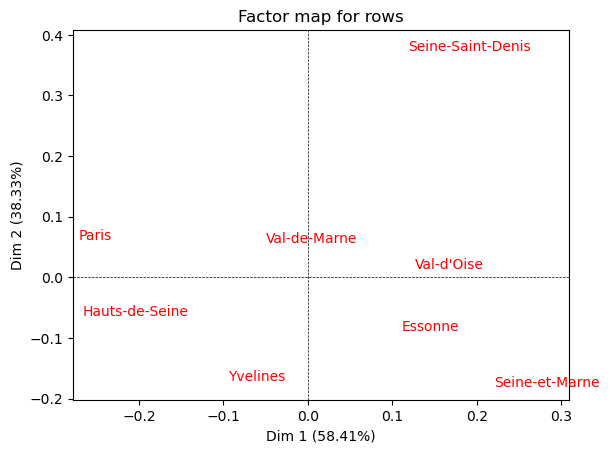

In [187]:
# Graphique des departements (en ligne)
my_ca.mapping_row(num_x_axis=1,num_y_axis=2)

### Graphique des candidats (profil colonne)

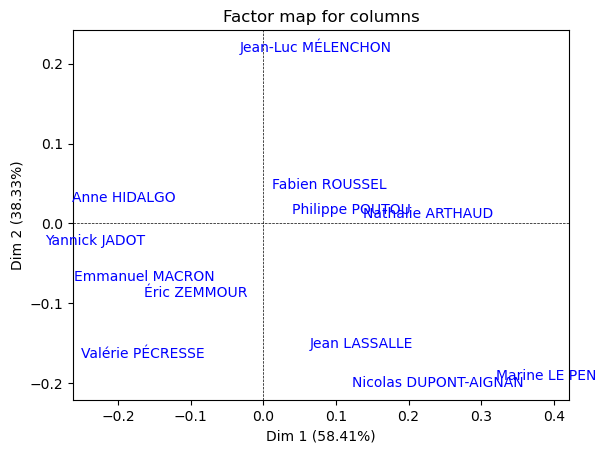

In [190]:
# Graphique des candidats (en colonne)
my_ca.mapping_col(num_x_axis=1,num_y_axis=2)

#### 4.2.5.3 Graphique superposition des profils lignes et colonnes

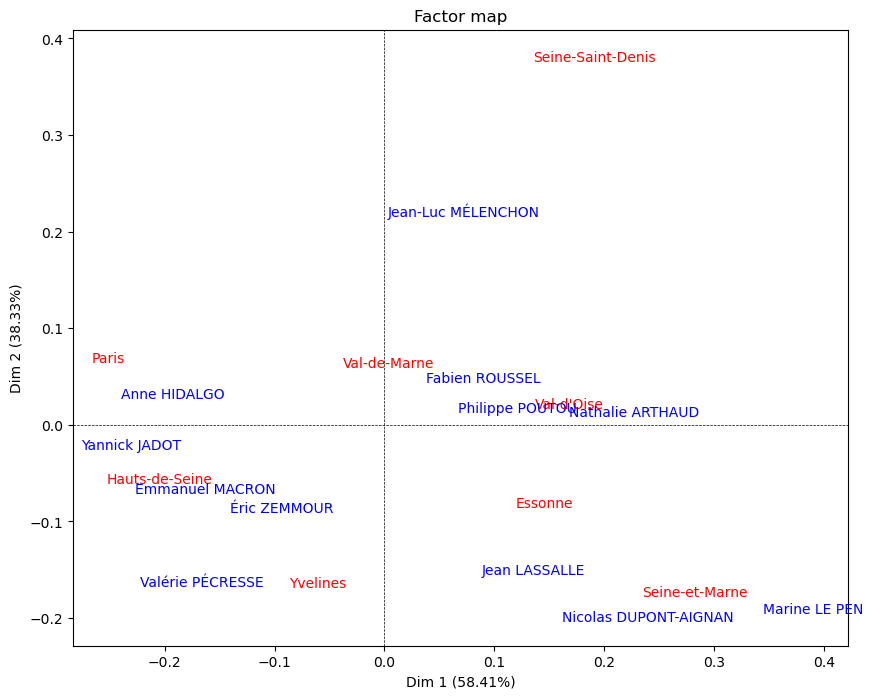

In [193]:
# Graphique profil ligne  profil colonne
my_ca.mapping(1,2, figsize=(10, 8))

# ACM
permet d'analyser les associations ou la relation entre les modalités de plusieurs variables qualitatives ( a la difference de l'AFC ou l'on a que deux variables qualitatives)

Le but de l'ACM est de représenter graphiquement les relations entre les variables catégorielles et les individus en utilisant des techniques de reduction de la dimensionnalité tout en conservant le maximum d'information

#### Objectif :
**Etude des individus :**
- identifier les individus qui se ressemblent
- Identifier les individus qui sont completement différents
**Etude des variables :**
- Liaisons entre les associations entre les modalités
- Visualisation facile pour analyser les liaisons entre les variable
- Identifier les variables synthétiques en conservant le maximum d'information

 Permet d'analayser la satisfaction client et la segmentation des marchés

 **Etape :**
 - Etape1: Du tableau initiale, on passe au tableau disjonctif complet (c'est à dire pour chaque modalité de la variable qualitative, on va creer une dummy variable) ce qui devient un croisement individu x chaque modalité binaire de de chaque variable qualitative
 - Etape2: determiner le profil ligne et le profil colonne, profil lige moyen et profil colonne moyen.
 - Etape3: calcul de la matrice des distances des individus et des variables ( distance d'un individu au profil colonne moyen, distance entre un individu et tous les autres individus, Distance entre les modalités et le profil ligne moyen, distance entre toutes les modalités), ensuite on determine les axes factoriels, les axes sont triés par ordre décroissants de variance expliquée (Le premier axe a touhours le maximum d'information, etc), à la fin , on va calculer les coordonnées des individus  et des variables

**Choix du nombre d'axes factoriels :**

- Regle du coude
- Critere de Kaiser_Guttman: on cherche à conserver suffisament d'axes pour expliquer d'axesc pour expliquer au moins 70% de l'inertie. Conserver les axes ayant une valeur propre superieur à 1

**Interpretation :**
- verifier la qualité de représentation avec le Cosinus carré (cos2 > 0.5)
- Vérifier la contribution (faire attention que la contribution ne depasse pas la contribution moyenne)
- La proximité entre les modalités d'une variable est signe de ressemlance, c-a-d qu'elle regroupe des effectifs semblables
- La proximité entre les modalités de variables différentes est signe d'association, c'est-a-dire qu'elle concerne les memes individus ou les des individus semblables

In [210]:
# Importation des packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import fanalysis.mca as MCA
import numpy as np

In [215]:
# 2. Importation et nettoyage des données
credit_data = pd.read_csv(r"C:\Users\brech\Desktop\dossier de taff\ML\credit_data_set.csv",sep=";")

In [217]:
# Afficher les premieres lignes
credit_data.head()

,Marche,Apport,Impaye,Assurance,Endettement,Famille,Enfants,Logement,Profession,Intitule,Age
0,Renovation,pas_Apport,Imp_0,AID,End_1,Union libre,Enf_0,Loge par la famille,Ouvrier non qualifie,MR,50
1,Renovation,pas_Apport,Imp_0,Sans Assurance,End_2,Marie,Enf_0,Proprietaire,Ouvrier qualifie,MR,40
2,Voiture,Apport,Imp_0,AID,End_3,Marie,Enf_1,Accedant a la propriete,Ouvrier qualifie,MR,30
3,Renovation,pas_Apport,Imp_0,Senior,End_2,Veuf,Enf_0,Proprietaire,Retraite,MR,60
4,Scooter,Apport,Imp_3 et +,AID,End_4,Union libre,Enf_0,Loge par l'employeur,Cadre moyen,MR,20


In [219]:
# Type de données dans la base
credit_data.dtypes

Marche         object
Apport         object
Impaye         object
Assurance      object
Endettement    object
Famille        object
Enfants        object
Logement       object
Profession     object
Intitule       object
Age             int64
dtype: object

In [221]:
# Description de la base de données
credit_data.describe(include="all") # all epremt d'avoir les statistique sur toutes les  variables (quanti comme quali)

,Marche,Apport,Impaye,Assurance,Endettement,Famille,Enfants,Logement,Profession,Intitule,Age
count,66,66,66,66,66,66,66,66,66,66,66.000000
unique,6,2,3,4,4,5,5,5,5,3,NaN
top,Renovation,Apport,Imp_0,AID,End_3,Marie,Enf_0,Proprietaire,Ouvrier qualifie,MR,NaN
freq,18,35,42,31,19,25,39,28,18,53,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.393939
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.686466
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.000000


In [223]:
# Analyse des données manquantes
credit_data.isnull().sum()

Marche         0
Apport         0
Impaye         0
Assurance      0
Endettement    0
Famille        0
Enfants        0
Logement       0
Profession     0
Intitule       0
Age            0
dtype: int64

In [231]:
# Verification des doublons
# Verifier les doublons
duplicates = credit_data.duplicated()
print(f"Nombre de lignes dupliquées : {duplicates.sum()}")

Nombre de lignes dupliquées : 0


In [233]:
# Penser à Analysee les outliers

In [245]:
credit_data["Age"].min()

20

In [247]:
credit_data["Age"].max()

60

In [243]:
# Transformer la variable age en variable catégorielle en créant des groupes
# Definir les limites des groupes d'age
age_bins = [19, 29, 39, 49, 59, 100]

# Definir les labels pour les groupes d'age
age_labels = [ '20-29', '30-39', '40-49', '50-59', '60+']

# Creer une nouvelle colonne 'Age_group' en utilisant la foncton cut()
credit_data['Age_group'] = pd.cut(credit_data['Age'], bins=age_bins, labels=age_labels, right=False)
credit_data.head()

,Marche,Apport,Impaye,Assurance,Endettement,Famille,Enfants,Logement,Profession,Intitule,Age,Age_group
0,Renovation,pas_Apport,Imp_0,AID,End_1,Union libre,Enf_0,Loge par la famille,Ouvrier non qualifie,MR,50,50-59
1,Renovation,pas_Apport,Imp_0,Sans Assurance,End_2,Marie,Enf_0,Proprietaire,Ouvrier qualifie,MR,40,40-49
2,Voiture,Apport,Imp_0,AID,End_3,Marie,Enf_1,Accedant a la propriete,Ouvrier qualifie,MR,30,30-39
3,Renovation,pas_Apport,Imp_0,Senior,End_2,Veuf,Enf_0,Proprietaire,Retraite,MR,60,60+
4,Scooter,Apport,Imp_3 et +,AID,End_4,Union libre,Enf_0,Loge par l'employeur,Cadre moyen,MR,20,20-29


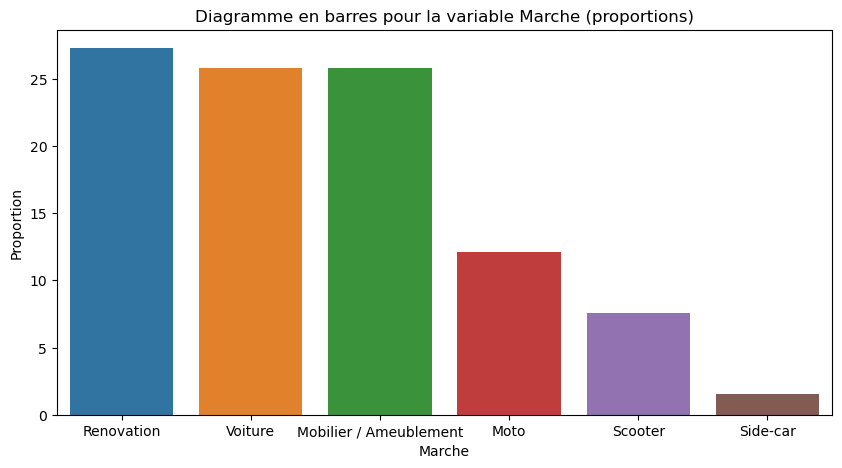

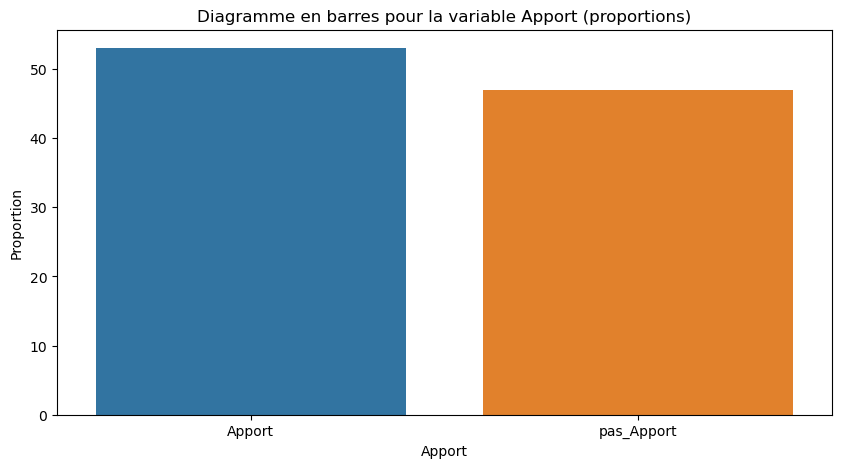

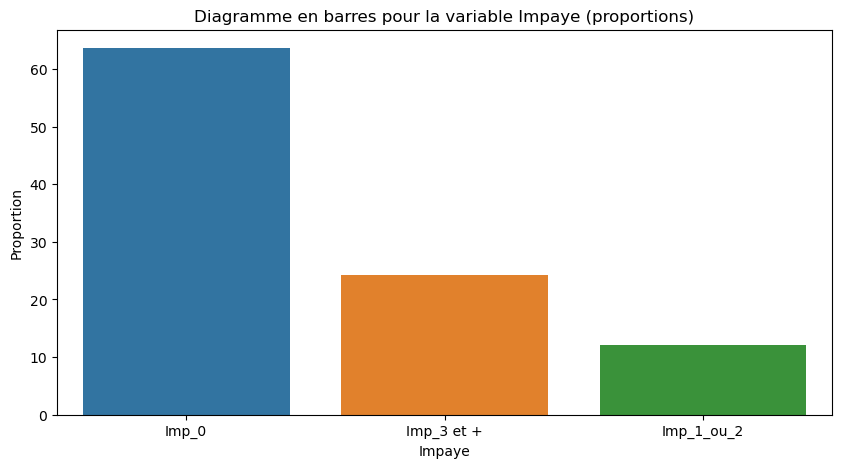

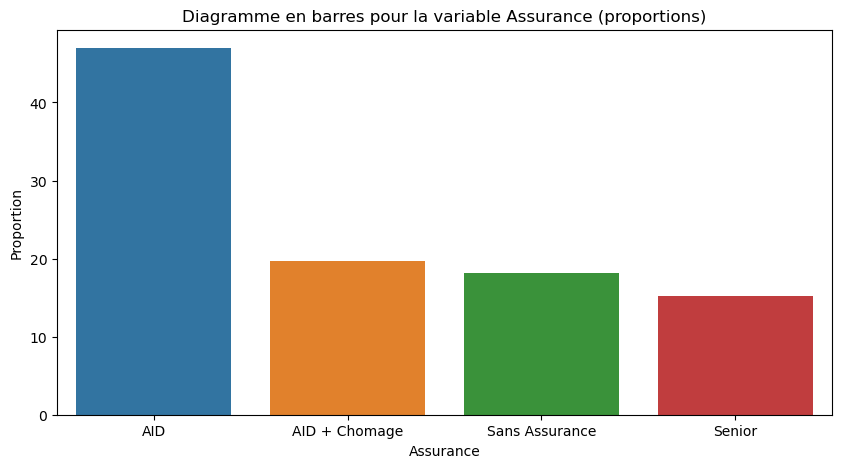

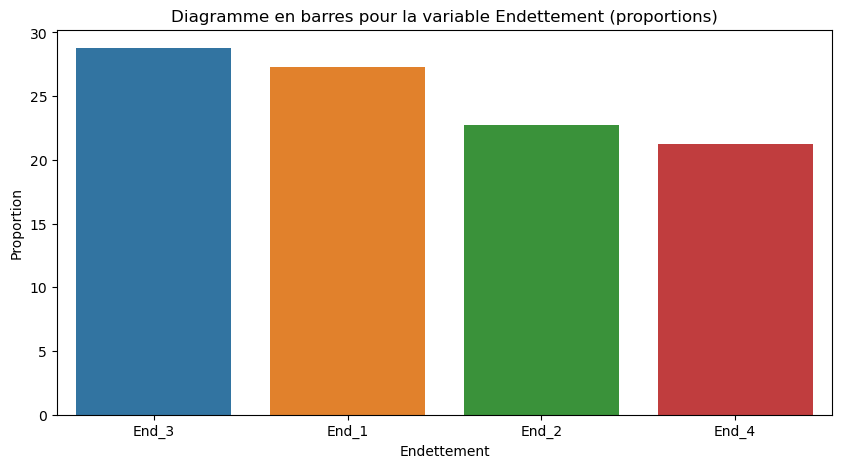

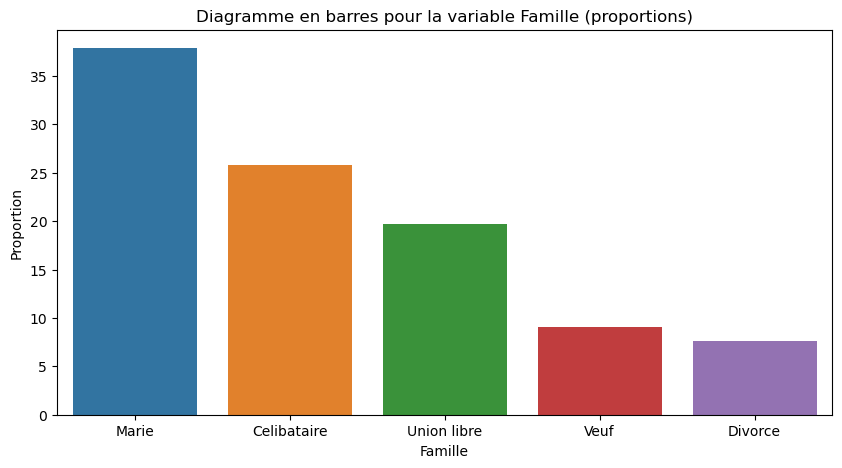

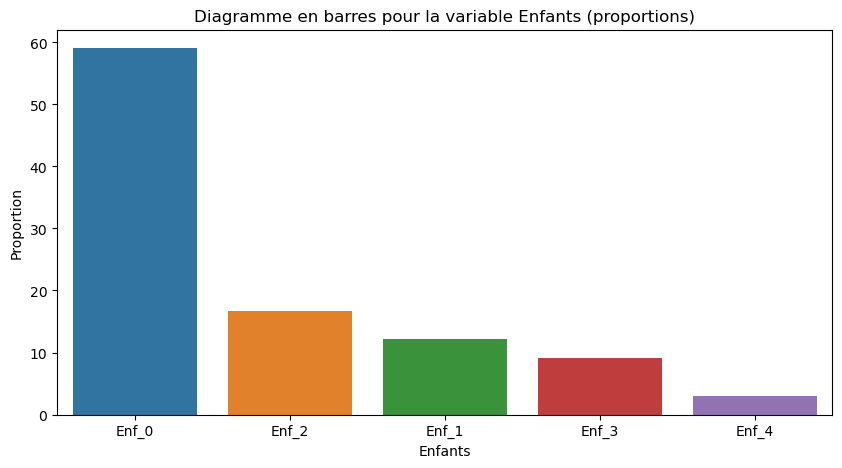

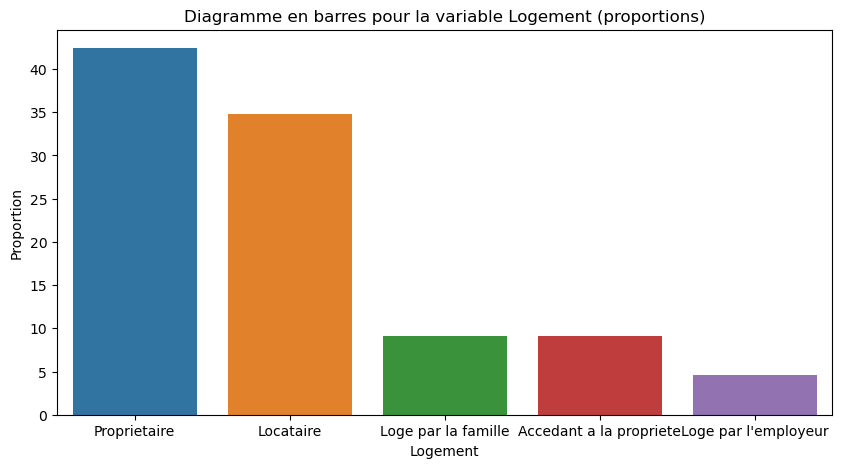

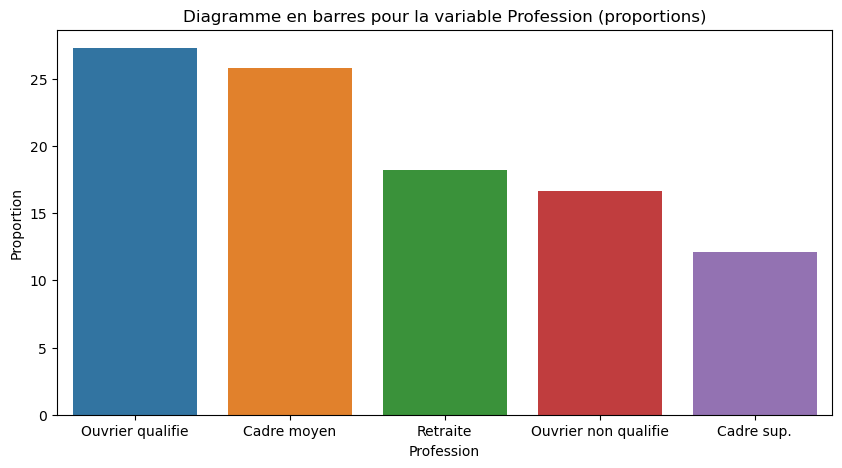

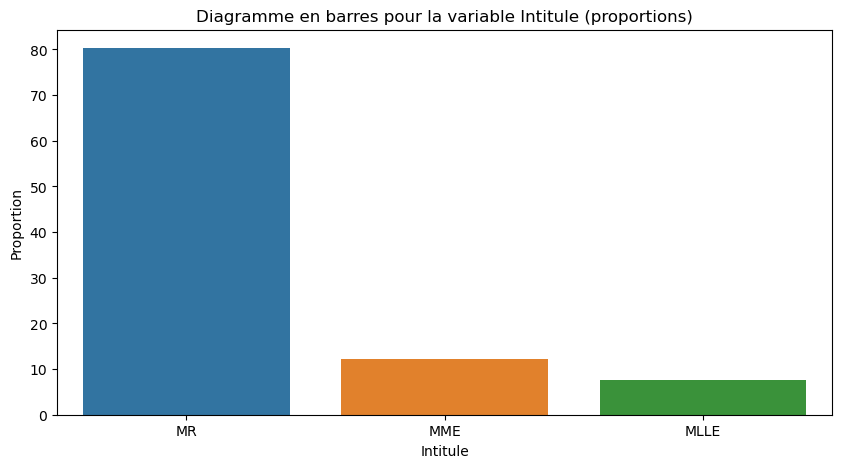

C:\Users\brech\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


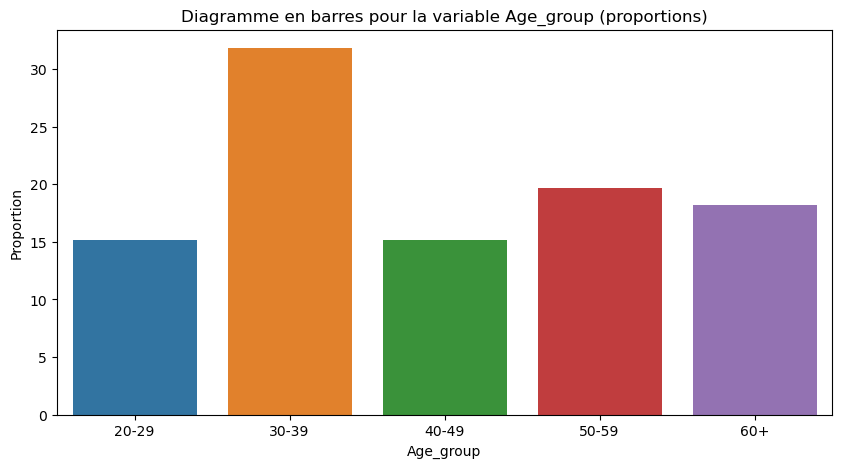

In [253]:
# Analyse univariées

# Afficher les fréquences des variables catégorielles
# Liste des variables qualitatives
categorical_columns = ['Marche', 'Apport', 'Impaye', 'Assurance', 'Endettement','Famille','Enfants','Logement','Profession','Intitule','Age_group']

# Creer des graphiques pour les variables catégorielles en termes de proportion
for col in categorical_columns:
    plt.figure(figsize=(10,5))
    proportions = credit_data[col].value_counts(normalize=True) * 100
    sns.barplot(x=proportions.index, y=proportions.values)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel("Proportion")
    plt.show()

In [255]:
# Afficher les fréquences des variables catégorielles
# Liste des variables qualitatives
categorical_columns = ['Marche', 'Apport', 'Impaye', 'Assurance', 'Endettement', 'Famille', 'Enfants', 'Logement', 'Profession', 'Intitule']

for col in categorical_columns:
    print(f"\nFréquences de la variable {col}:")
    print(credit_data[col].value_counts())


Fréquences de la variable Marche:
Marche
Renovation                18
Voiture                   17
Mobilier / Ameublement    17
Moto                       8
Scooter                    5
Side-car                   1
Name: count, dtype: int64

Fréquences de la variable Apport:
Apport
Apport        35
pas_Apport    31
Name: count, dtype: int64

Fréquences de la variable Impaye:
Impaye
Imp_0         42
Imp_3 et +    16
Imp_1_ou_2     8
Name: count, dtype: int64

Fréquences de la variable Assurance:
Assurance
AID               31
AID + Chomage     13
Sans Assurance    12
Senior            10
Name: count, dtype: int64

Fréquences de la variable Endettement:
Endettement
End_3    19
End_1    18
End_2    15
End_4    14
Name: count, dtype: int64

Fréquences de la variable Famille:
Famille
Marie          25
Celibataire    17
Union libre    13
Veuf            6
Divorce         5
Name: count, dtype: int64

Fréquences de la variable Enfants:
Enfants
Enf_0    39
Enf_2    11
Enf_1     8
Enf_3     6
E

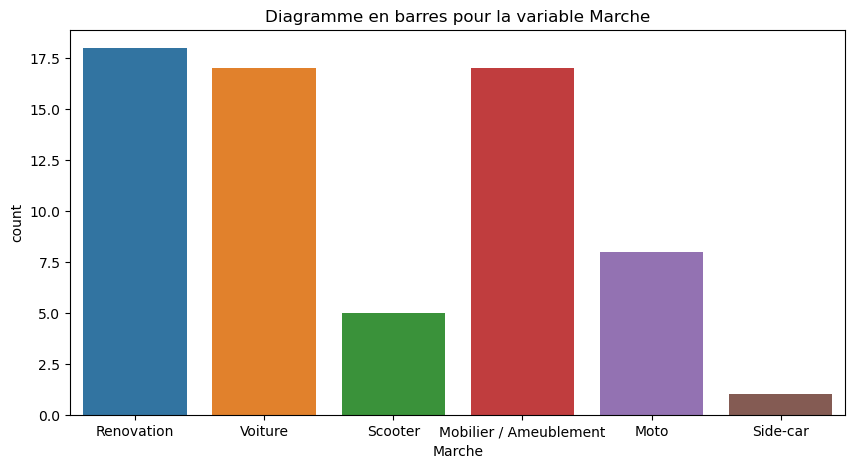

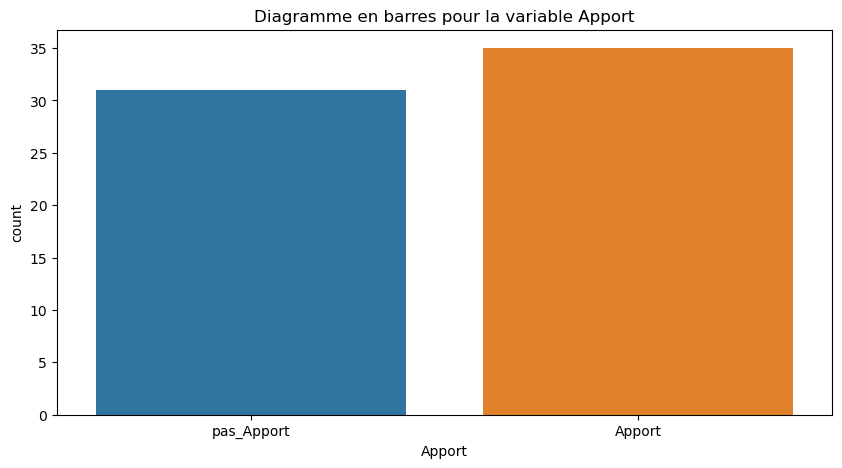

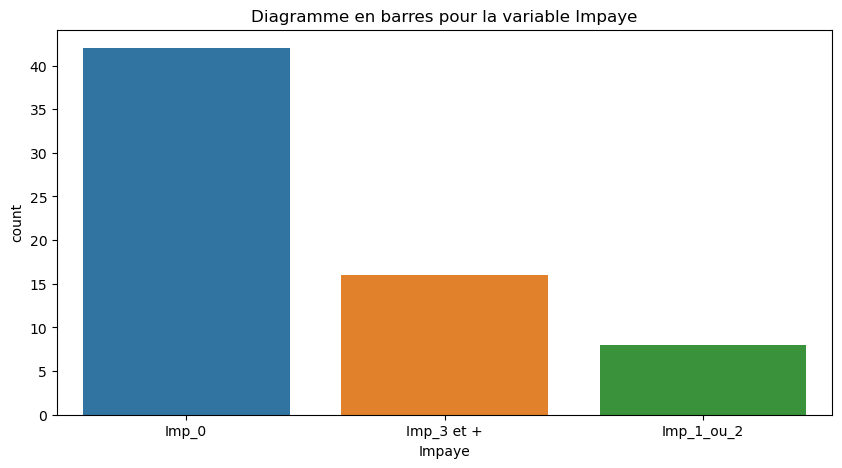

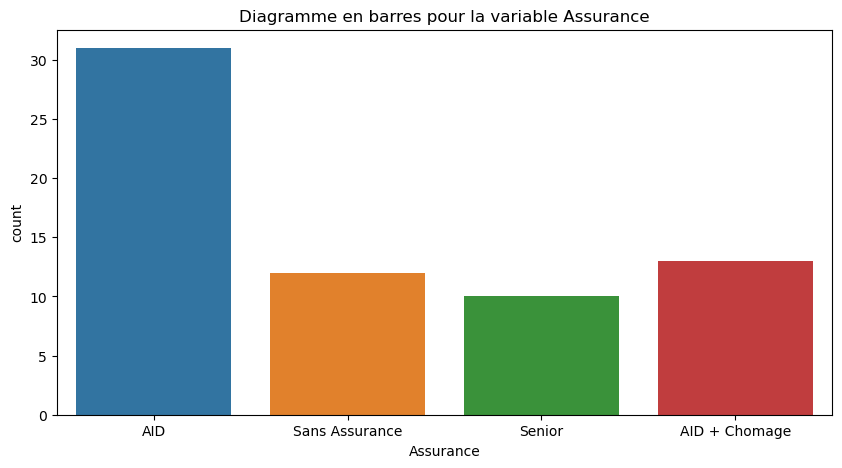

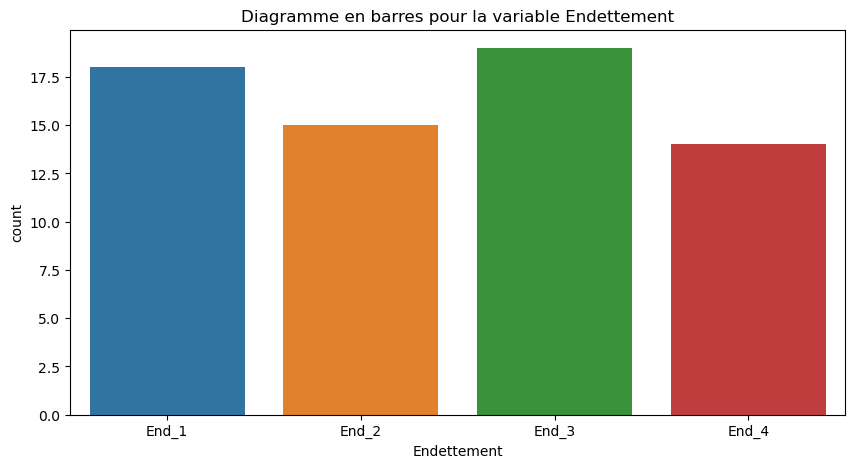

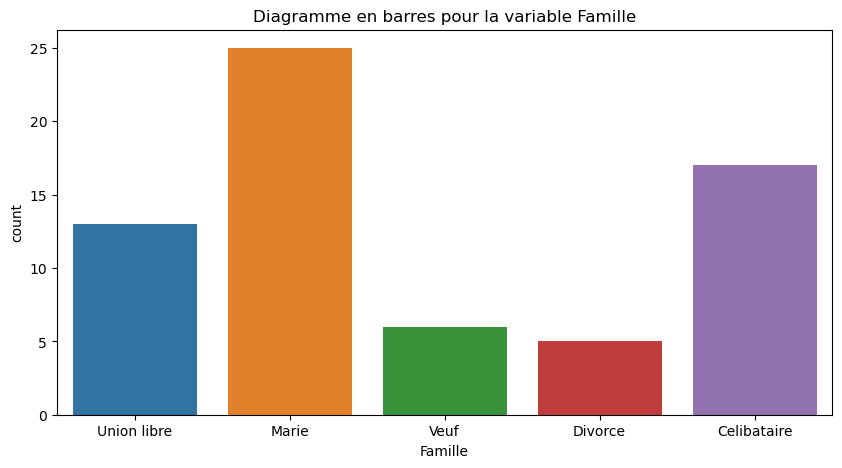

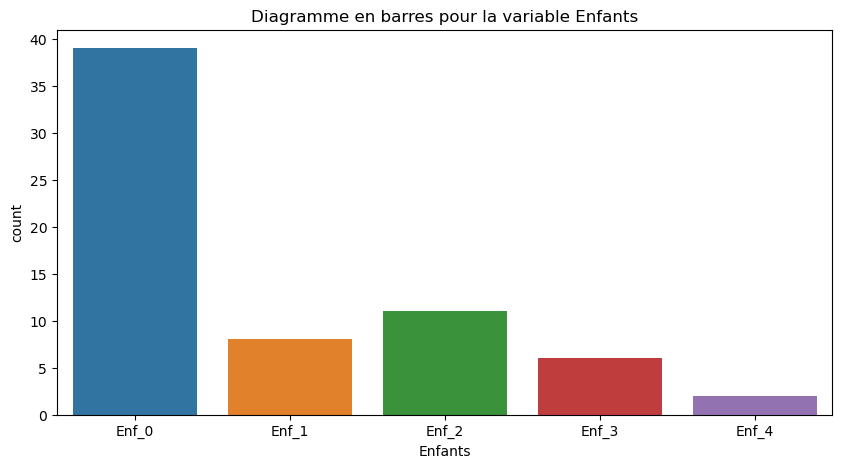

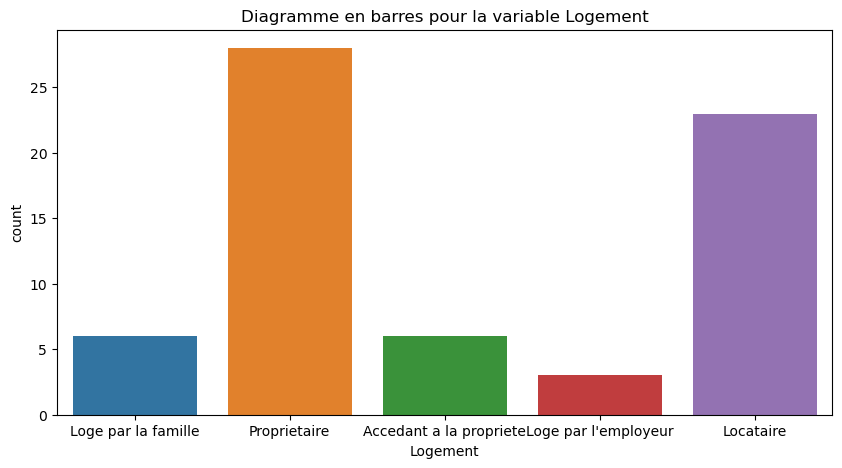

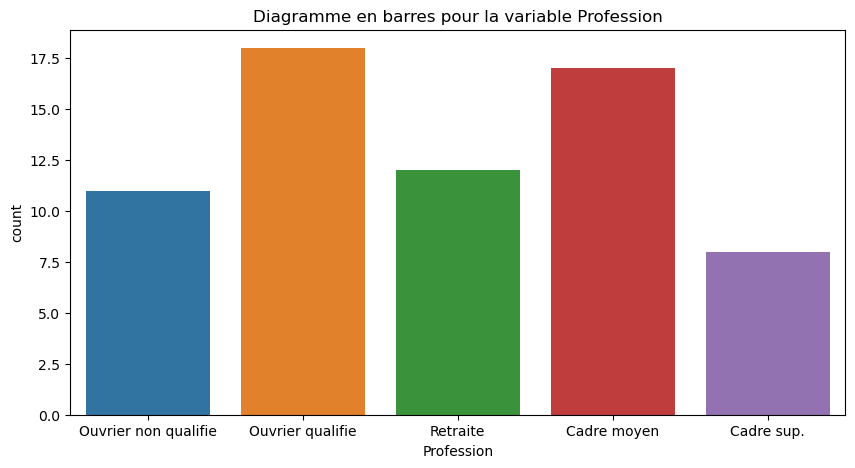

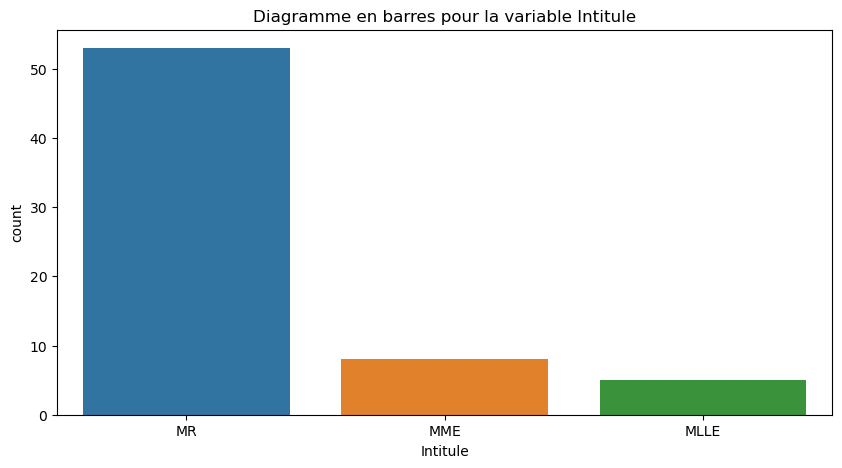

In [257]:
# Créer des graphiques pour les variables catégorielles
for col in categorical_columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=col, data=credit_data)
    plt.title(f"Diagramme en barres pour la variable {col}")
    plt.show()

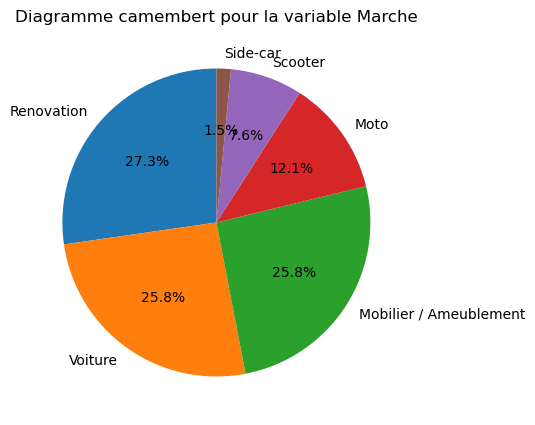

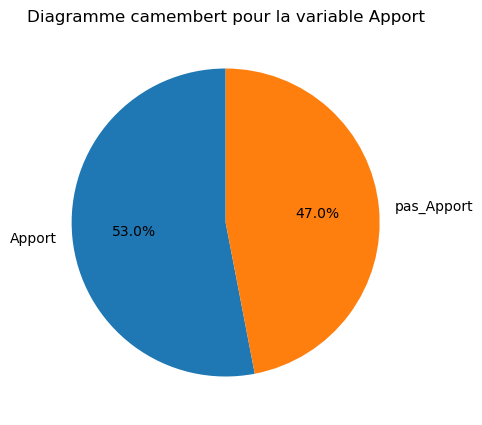

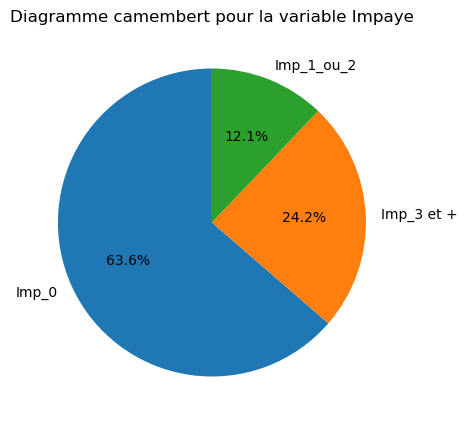

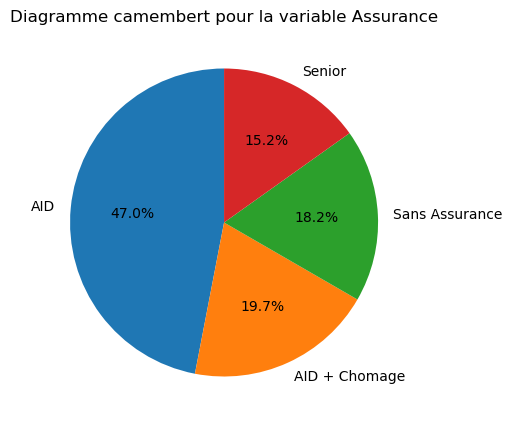

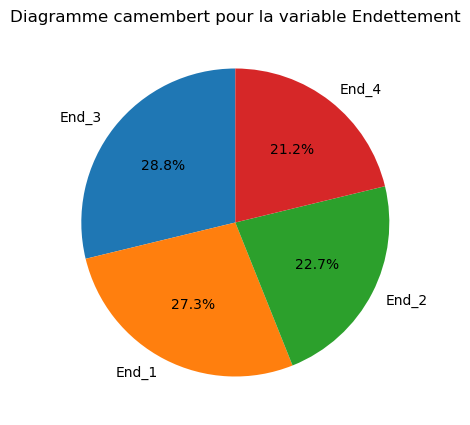

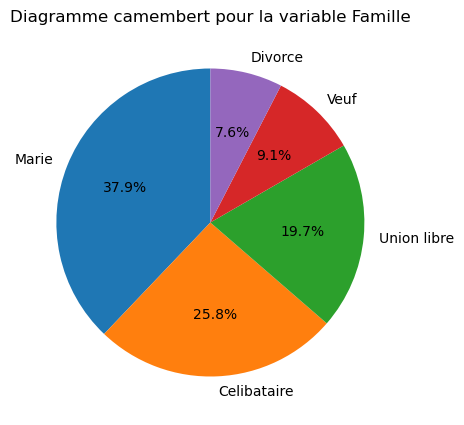

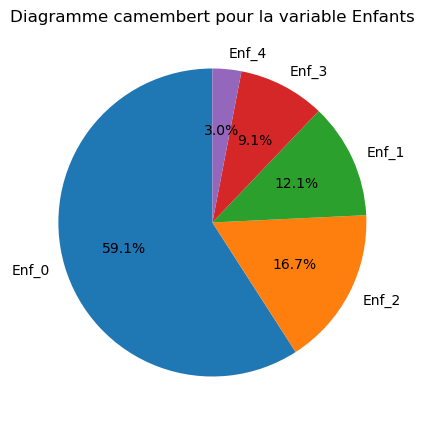

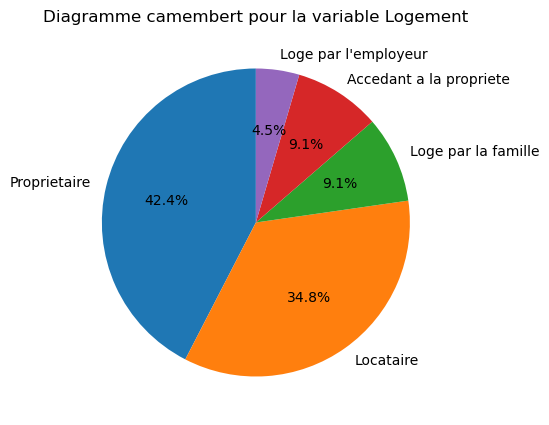

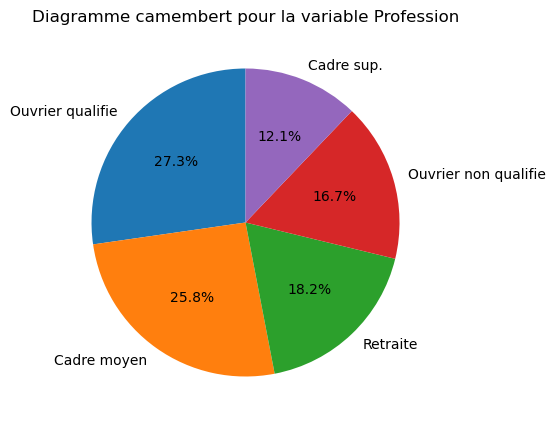

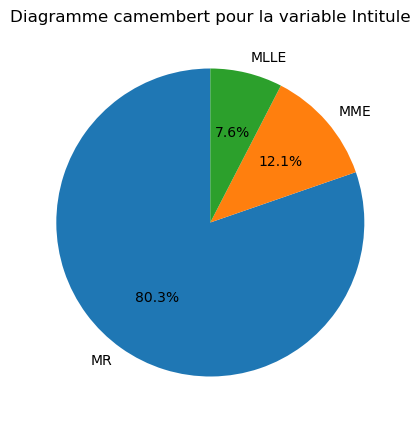

In [259]:
# Créer des graphiques camemberts pour les variables catégorielles
for col in categorical_columns:
    plt.figure(figsize=(10, 5))
    credit_data[col].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
    plt.title(f"Diagramme camembert pour la variable {col}")
    plt.ylabel('')
    plt.show()

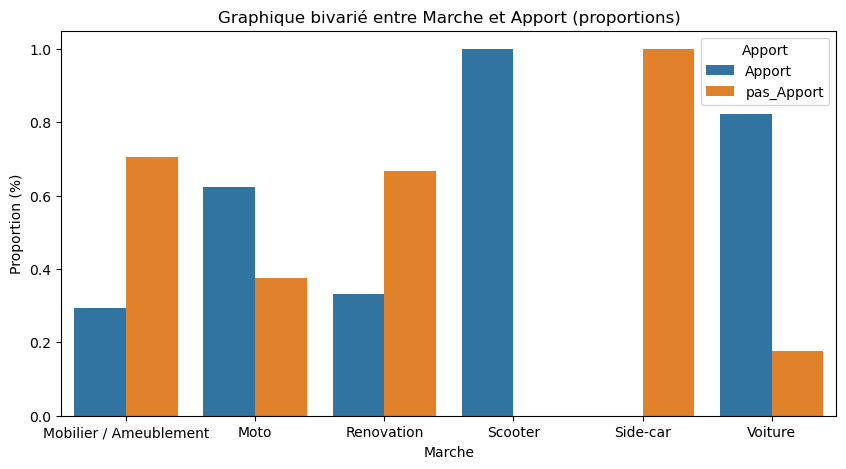

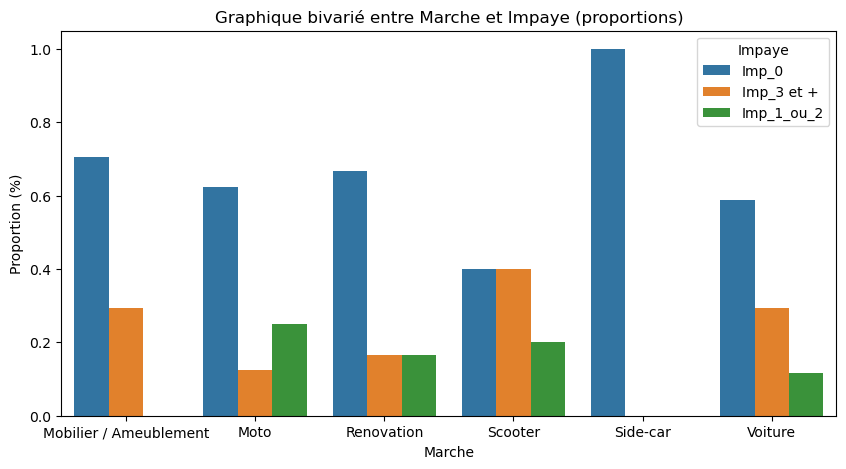

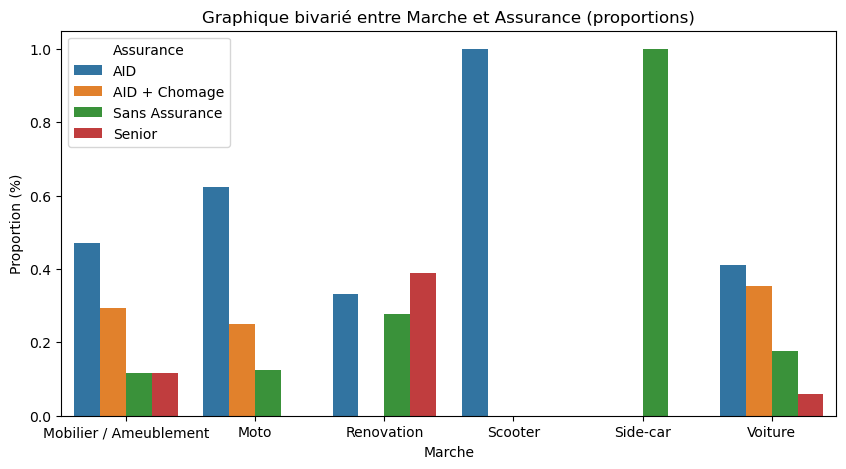

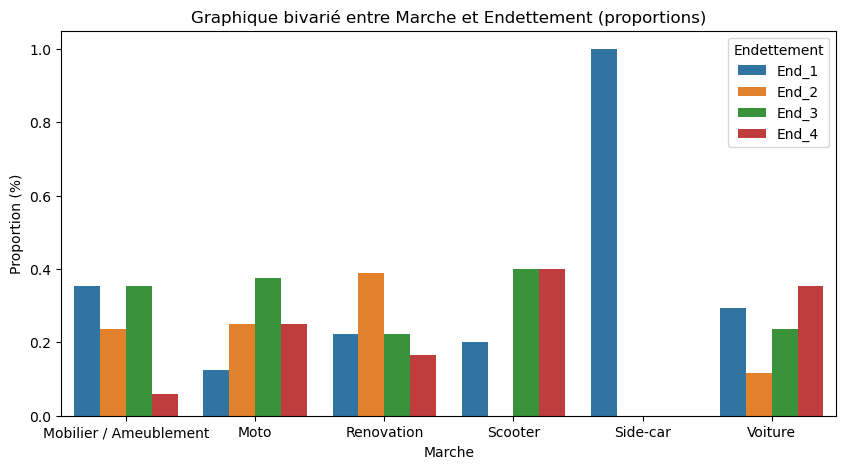

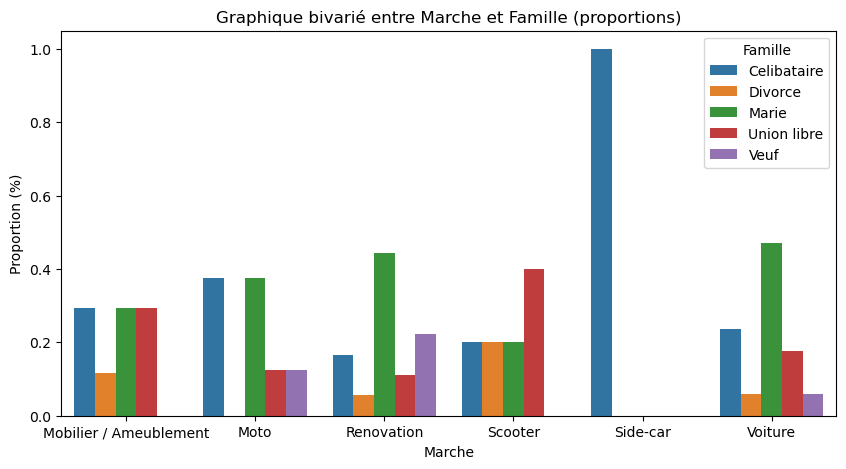

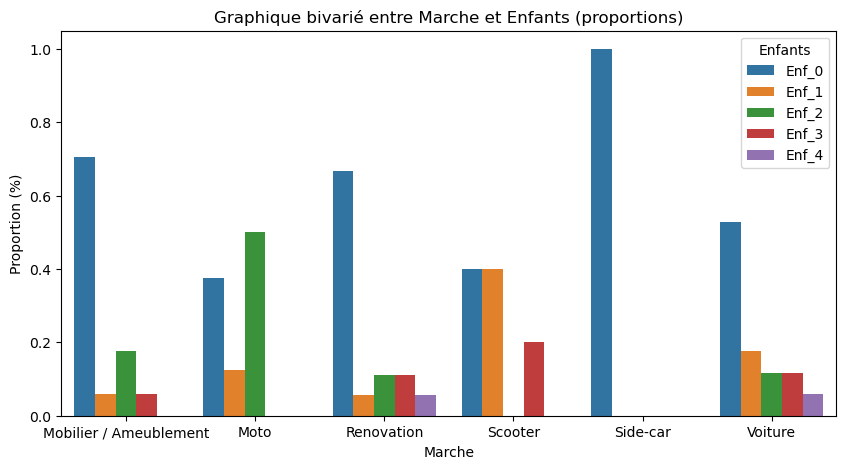

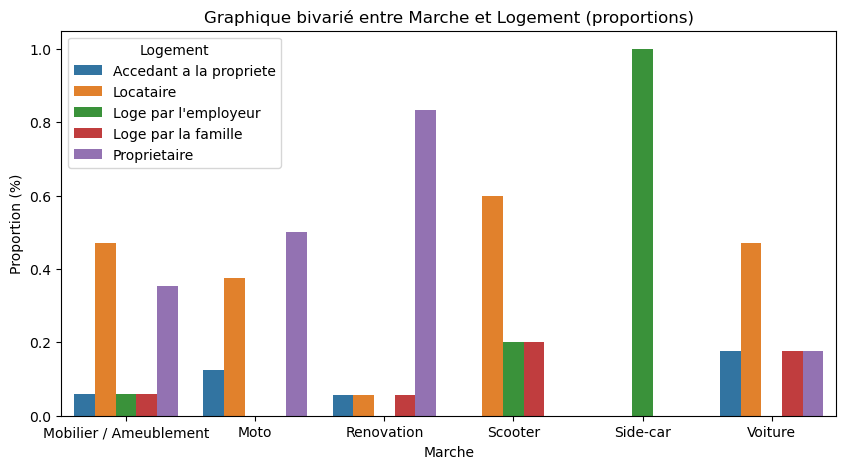

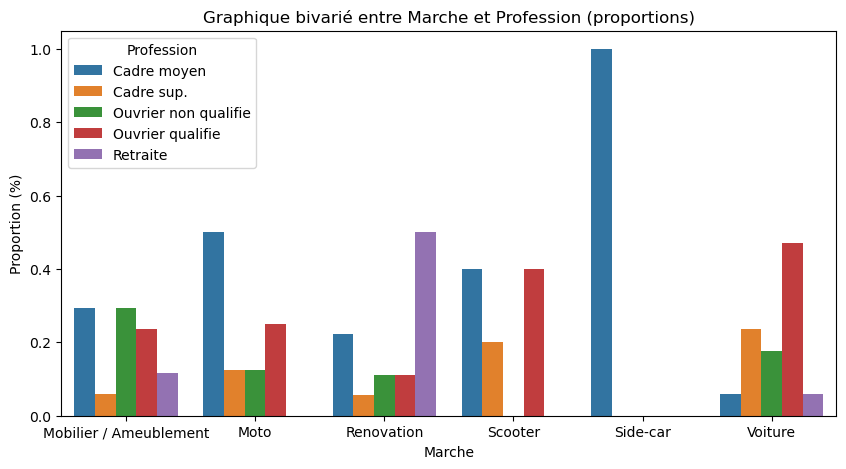

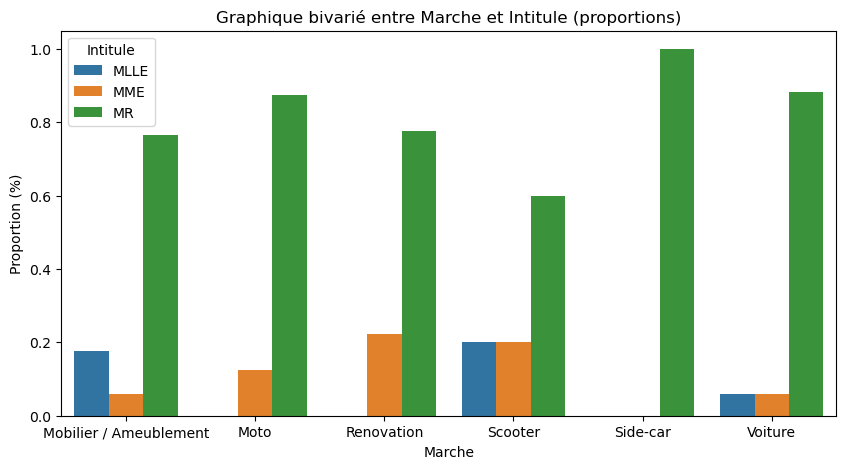

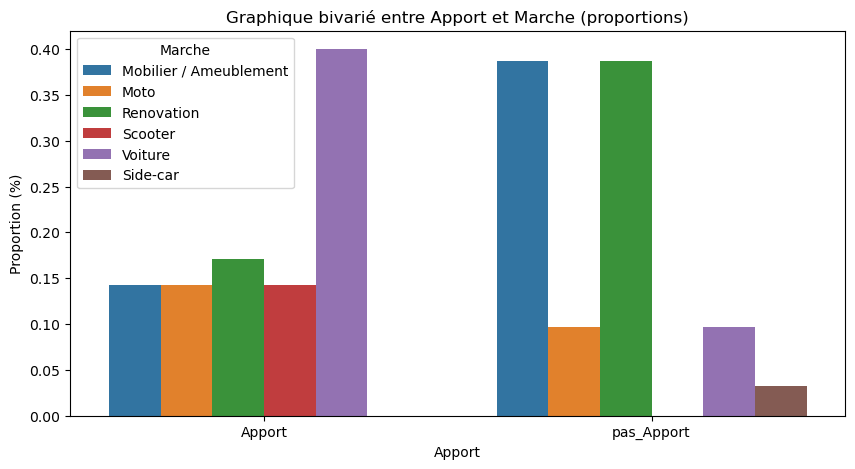

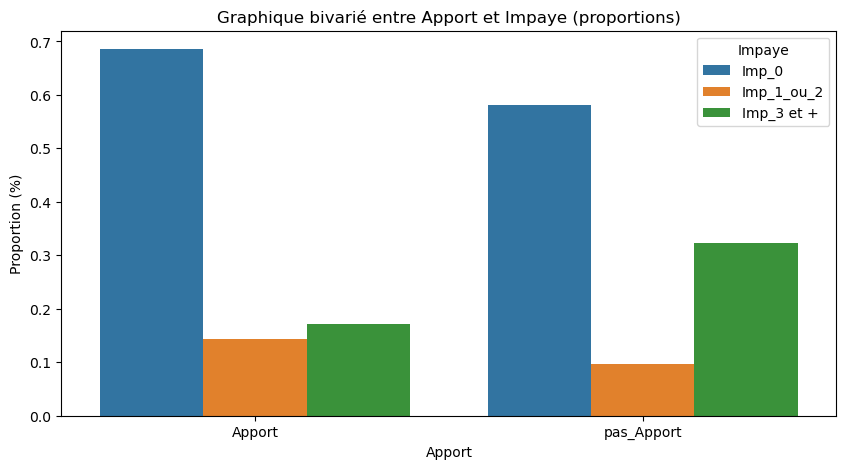

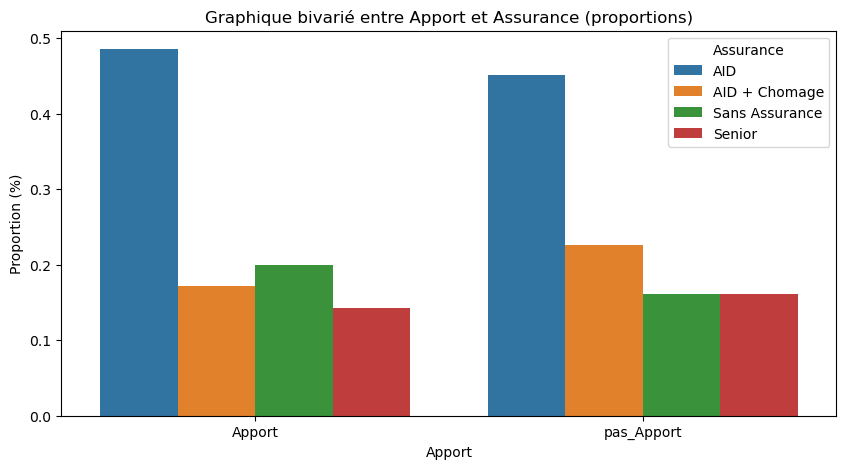

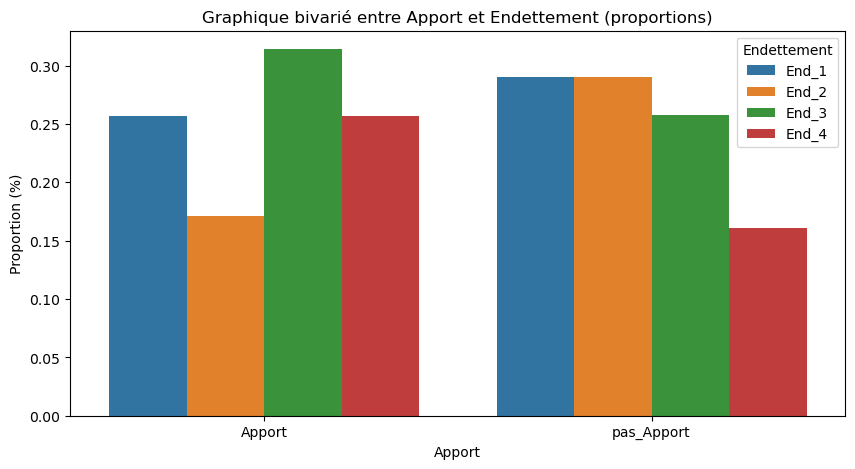

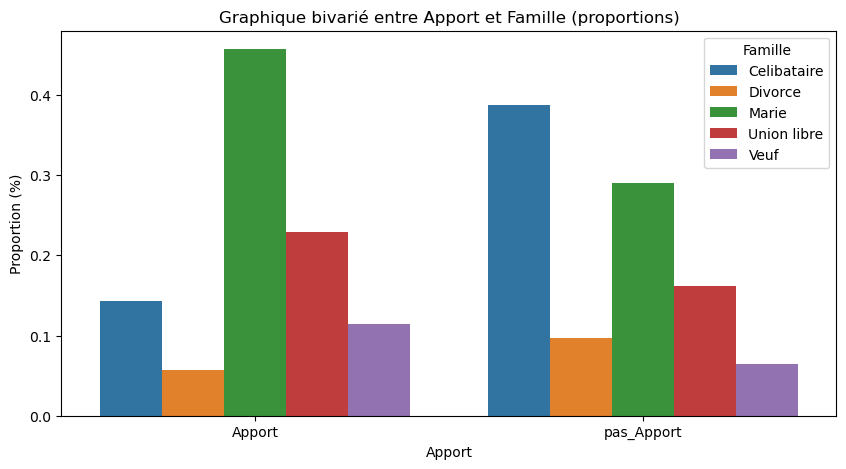

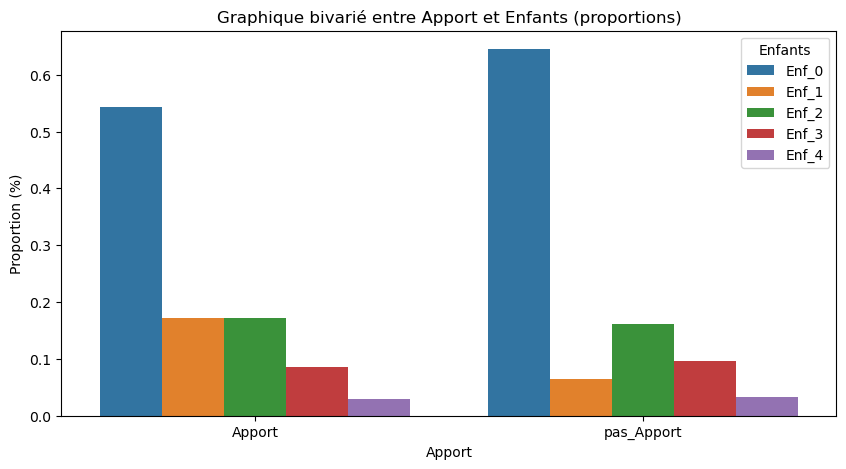

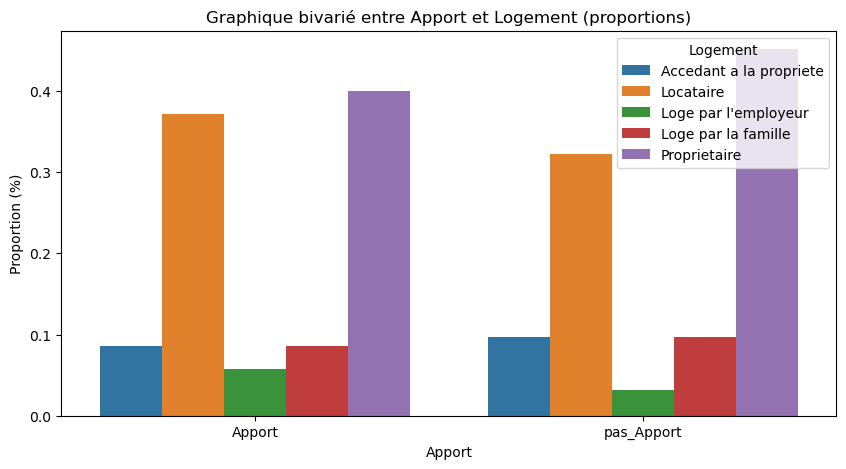

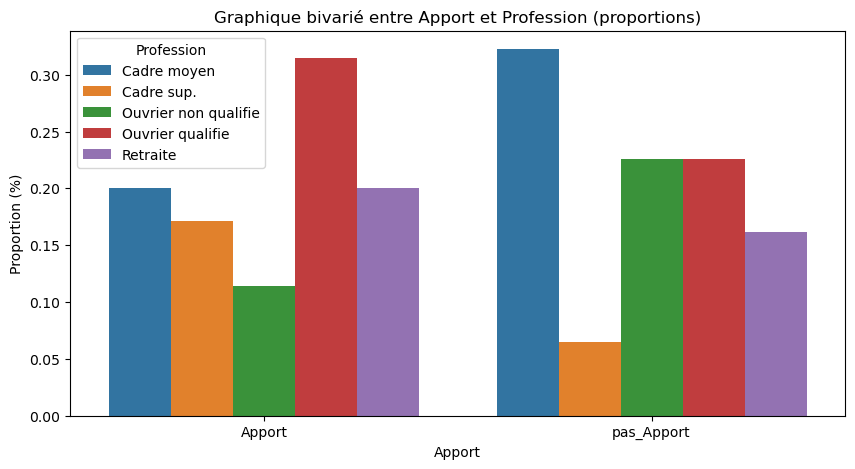

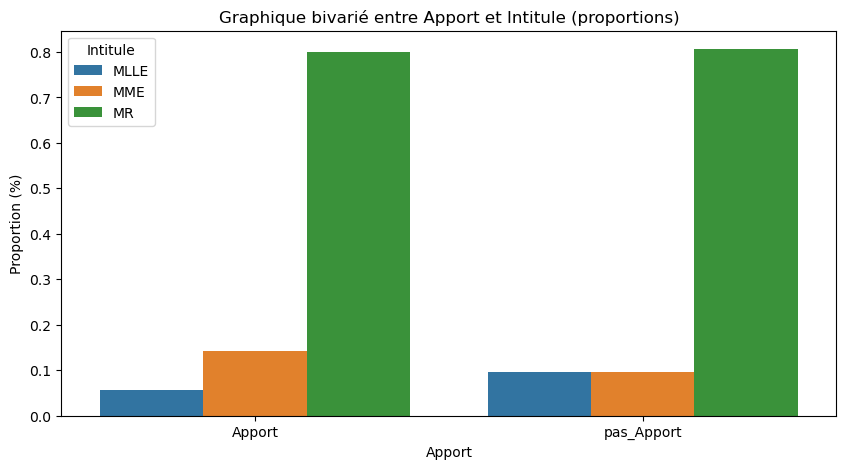

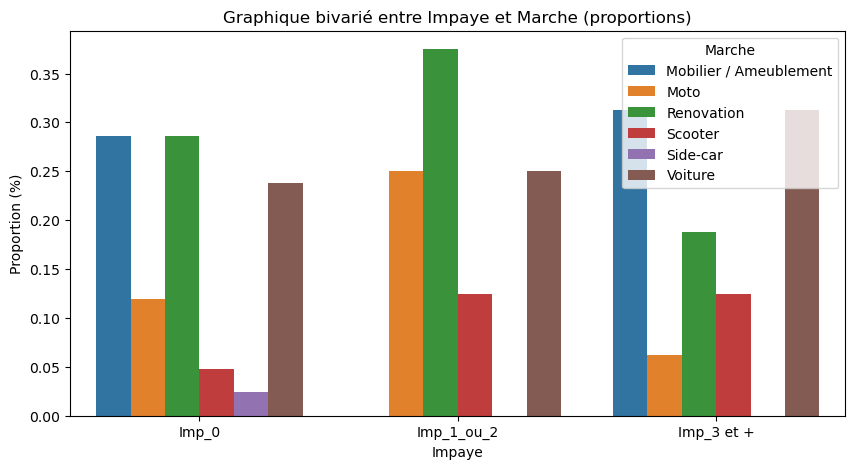

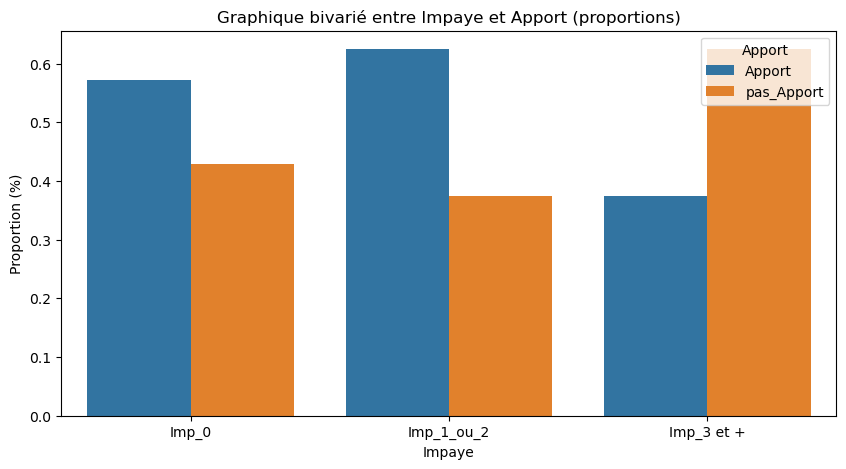

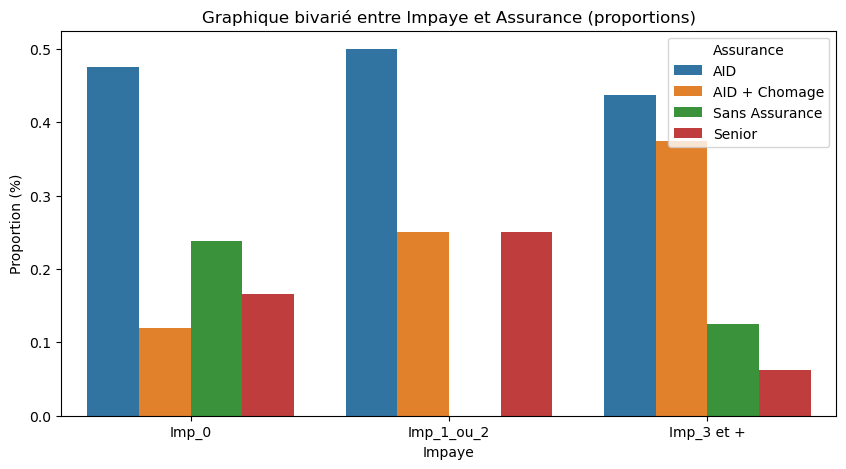

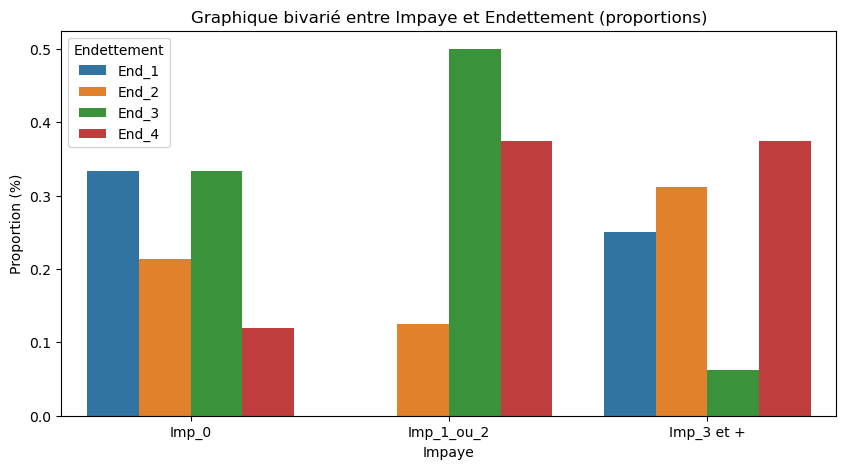

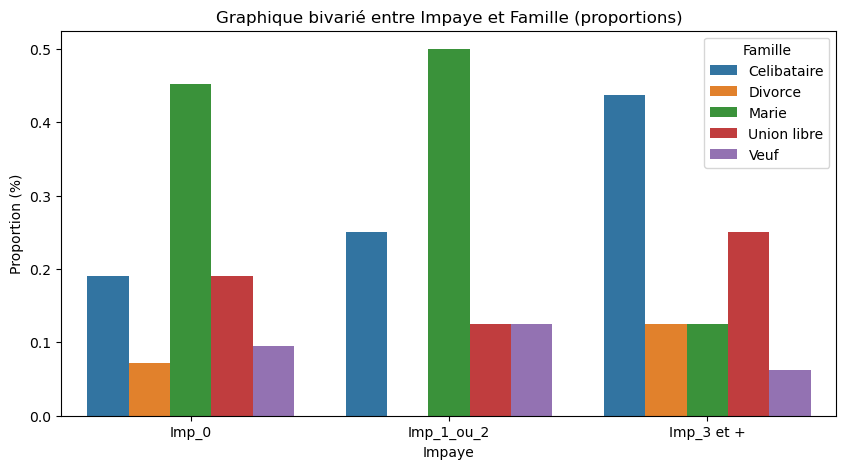

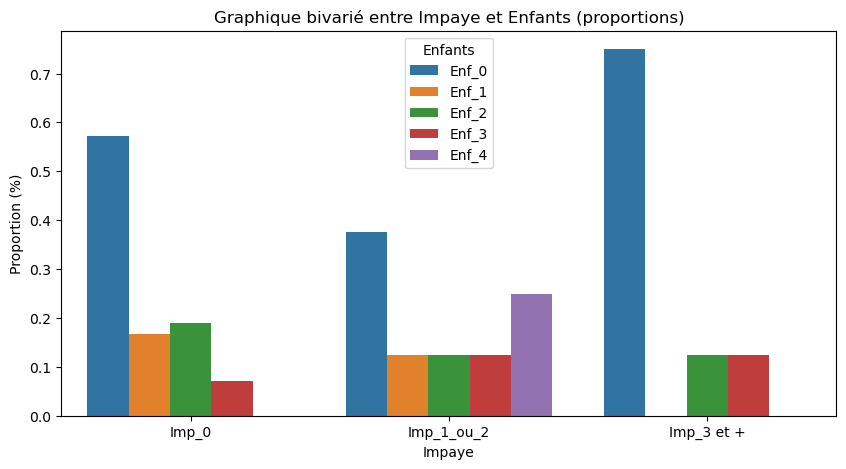

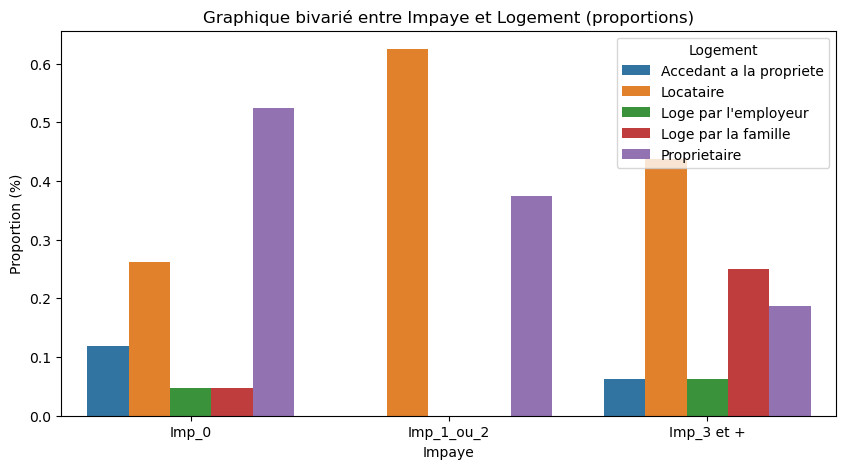

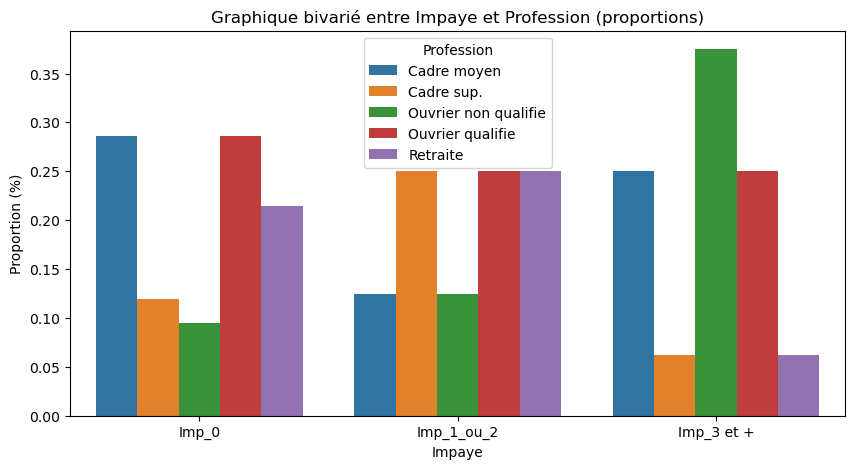

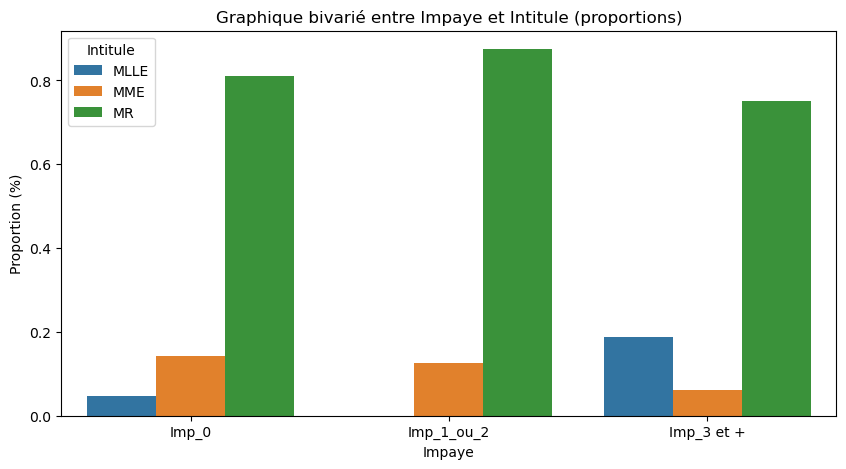

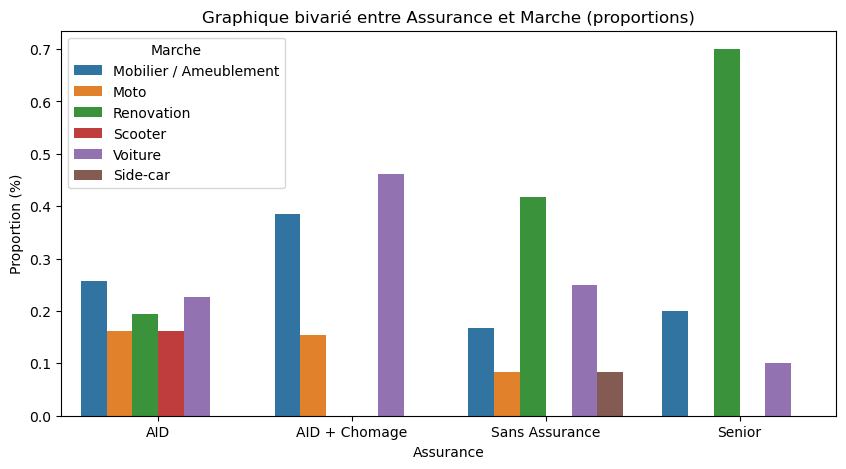

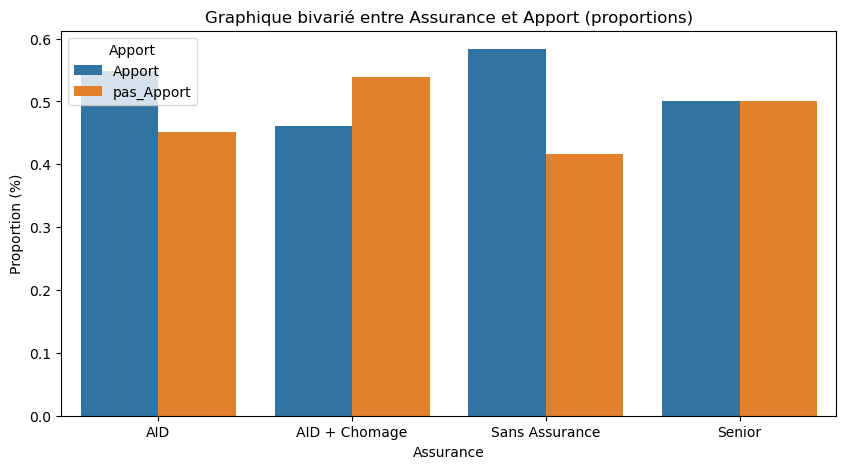

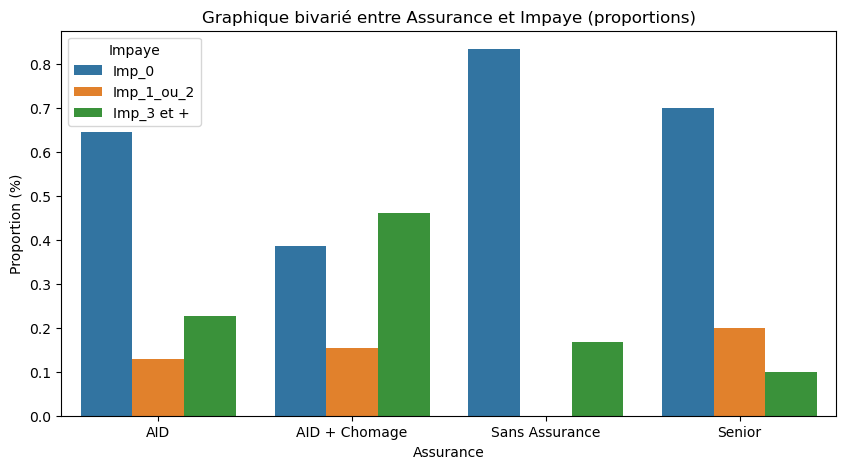

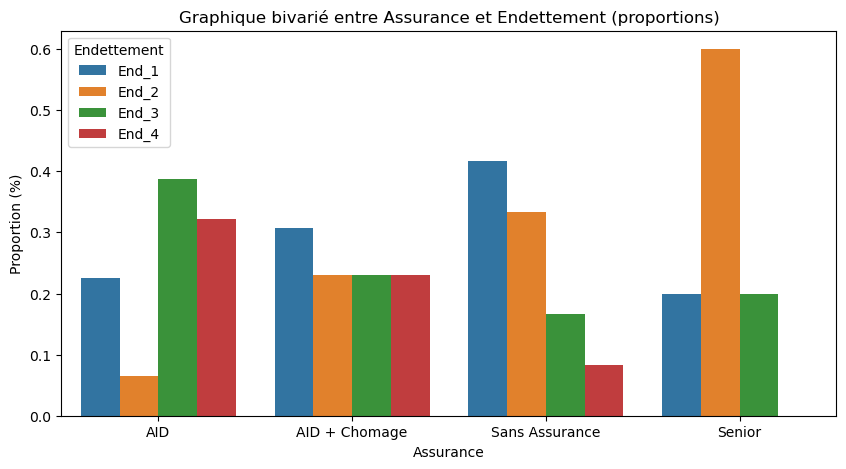

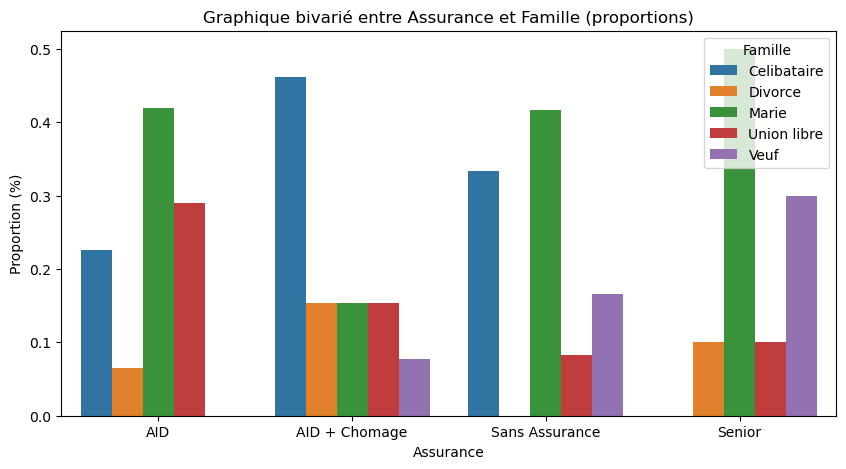

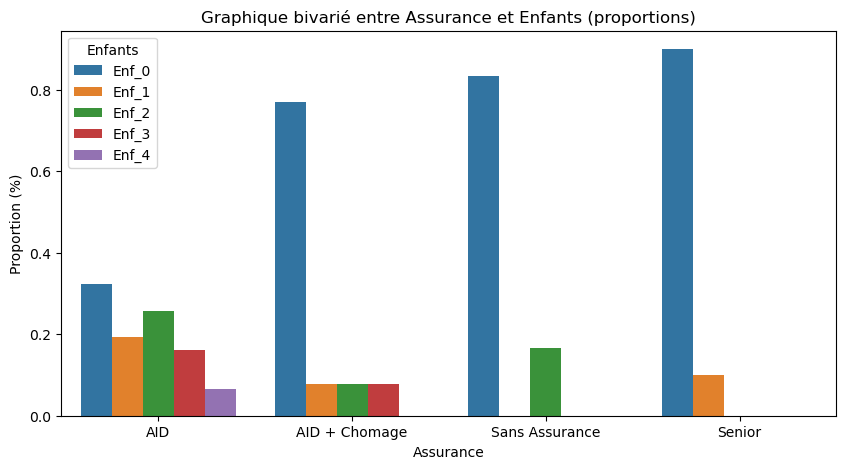

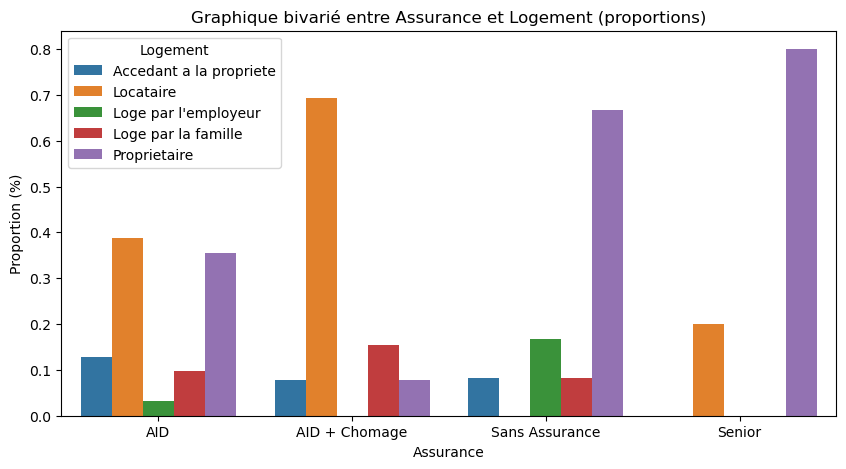

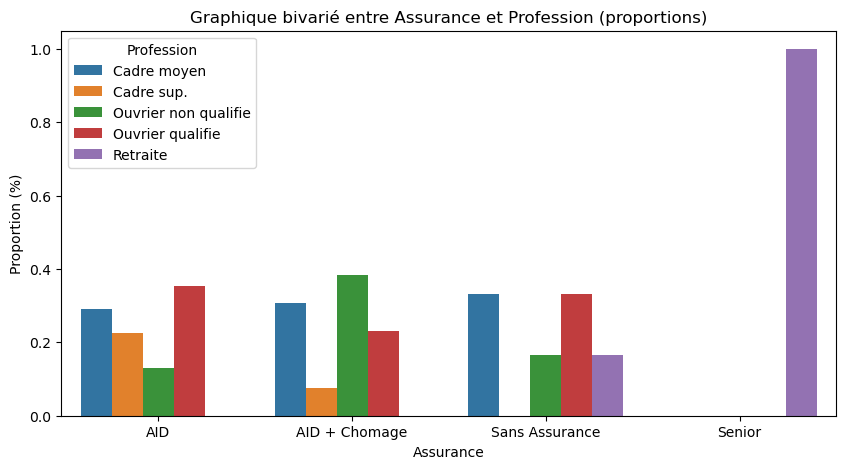

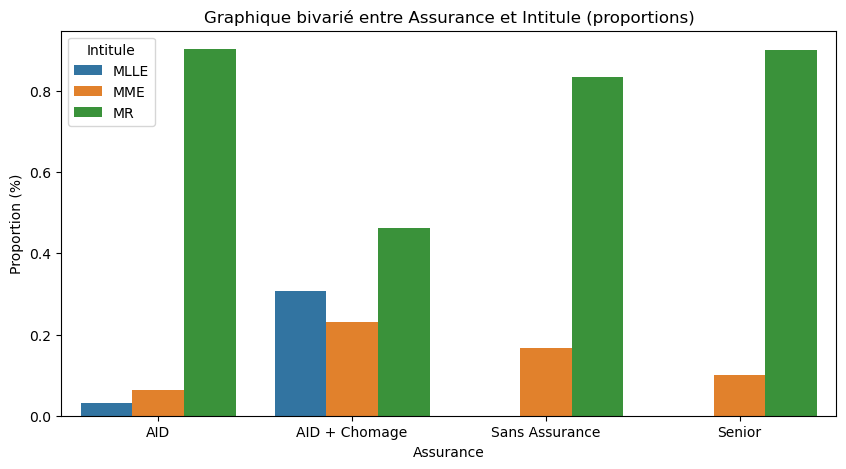

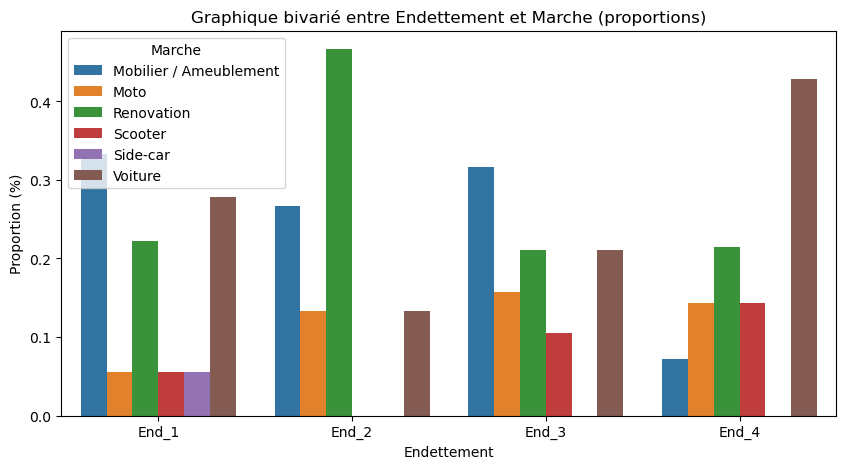

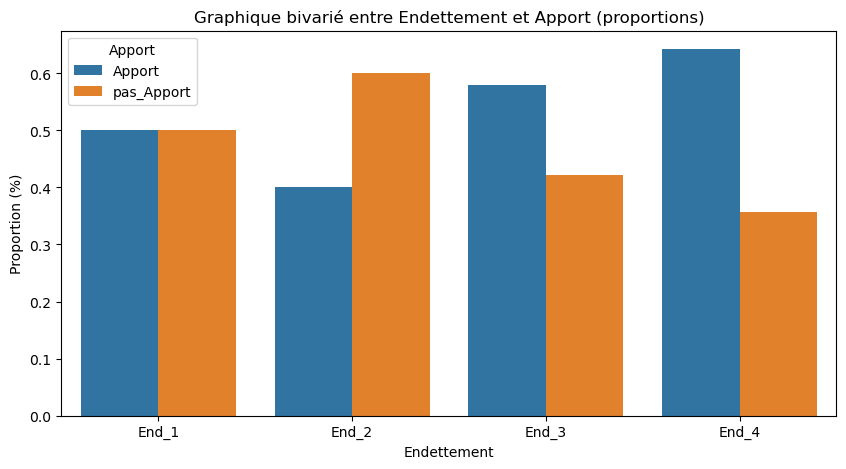

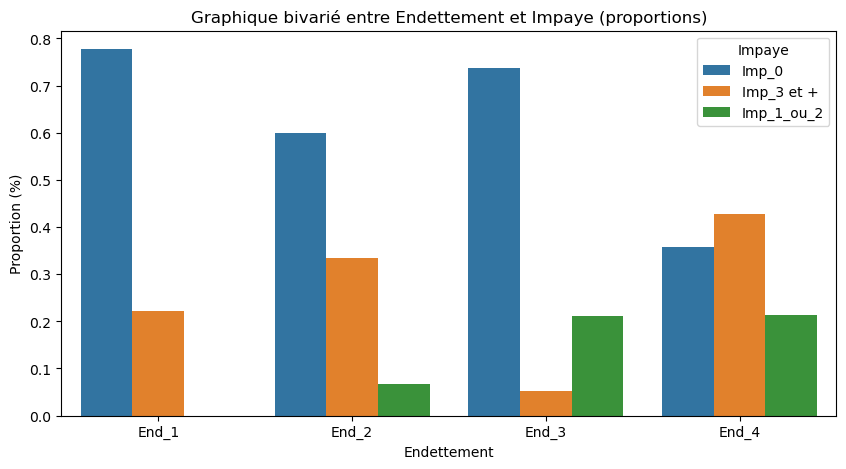

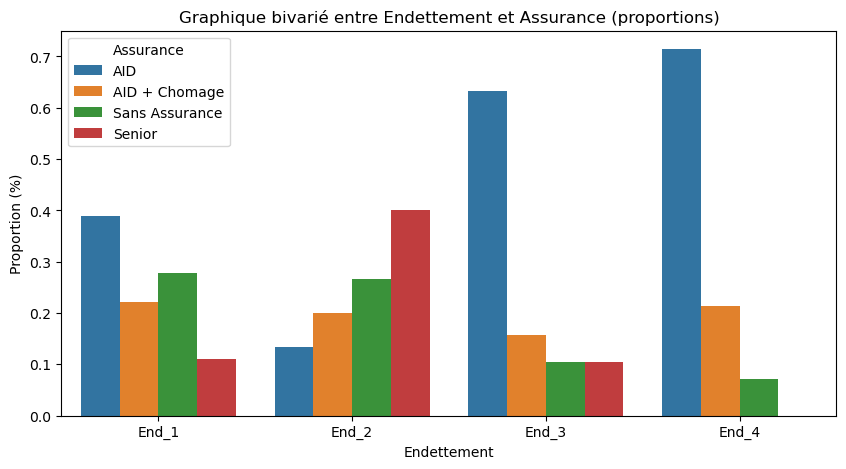

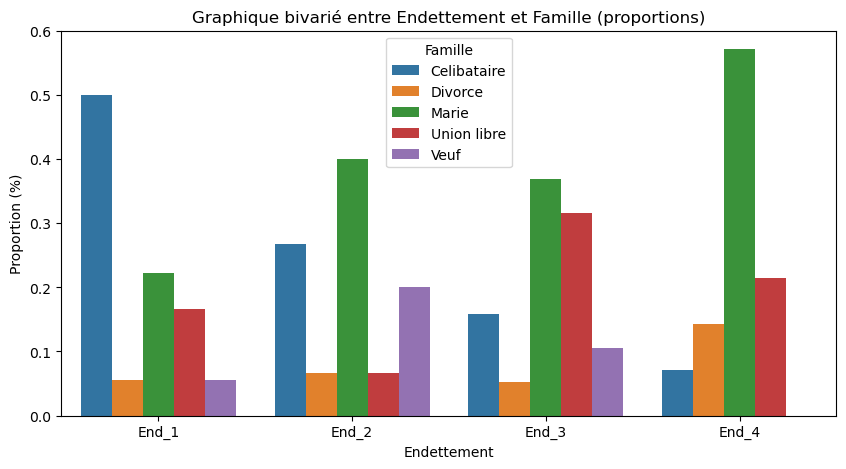

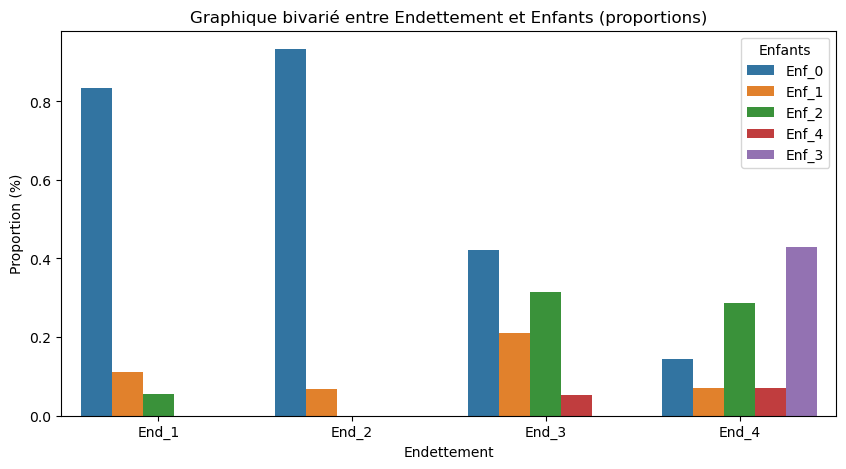

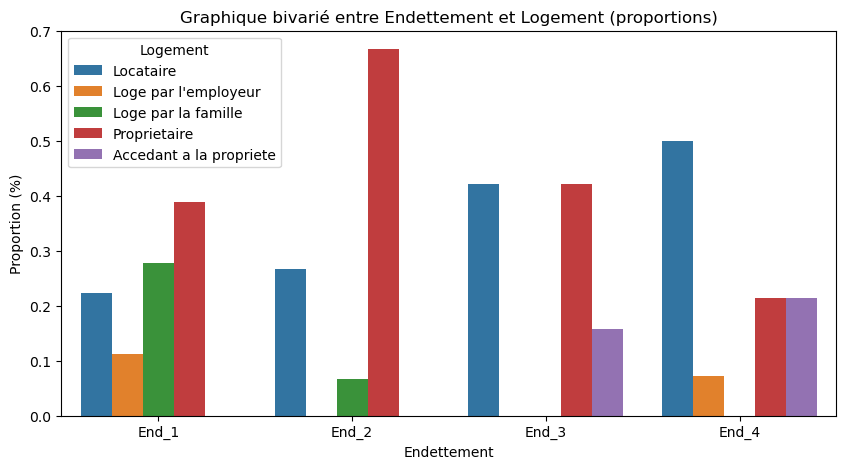

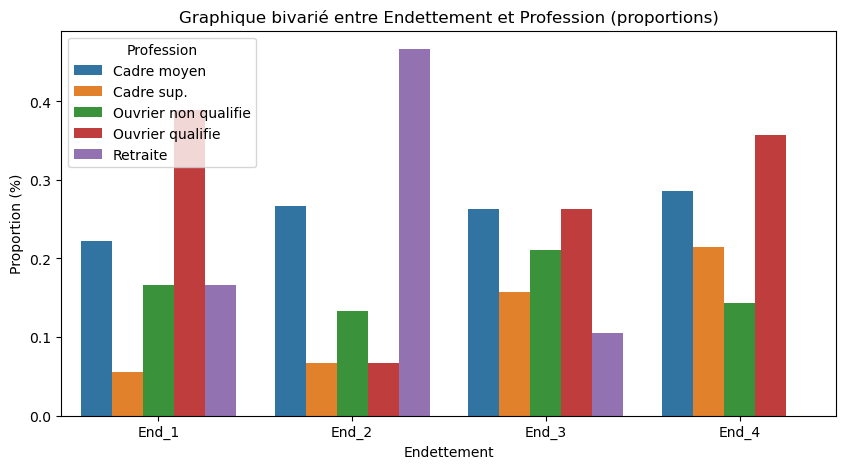

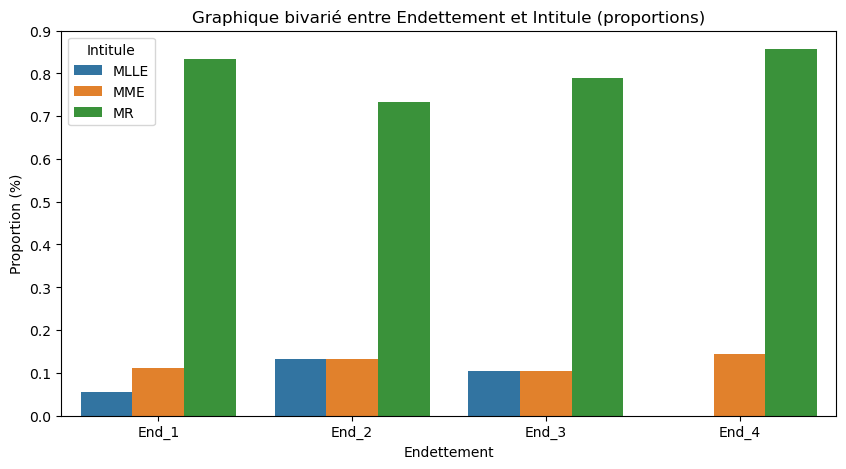

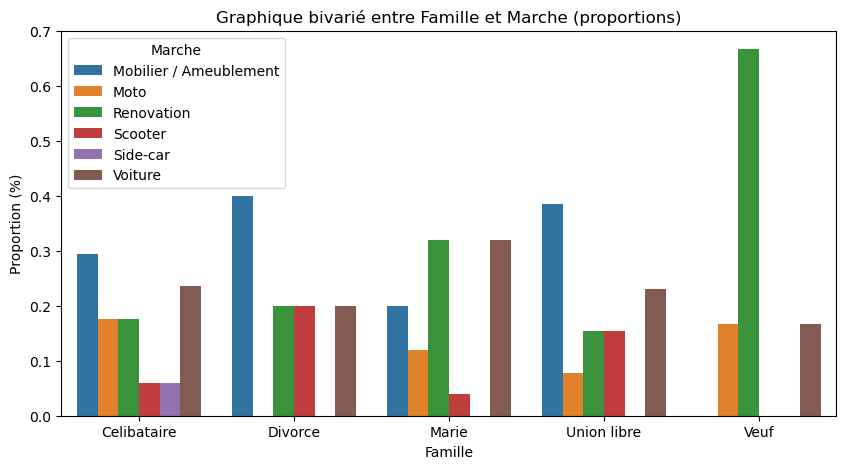

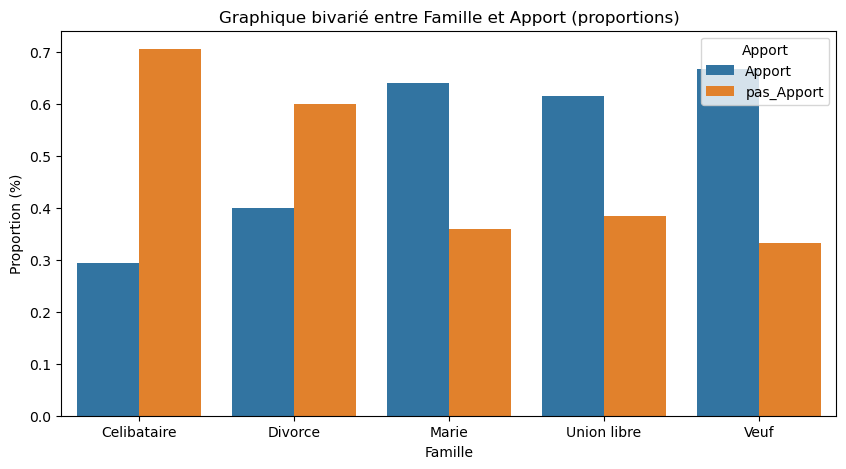

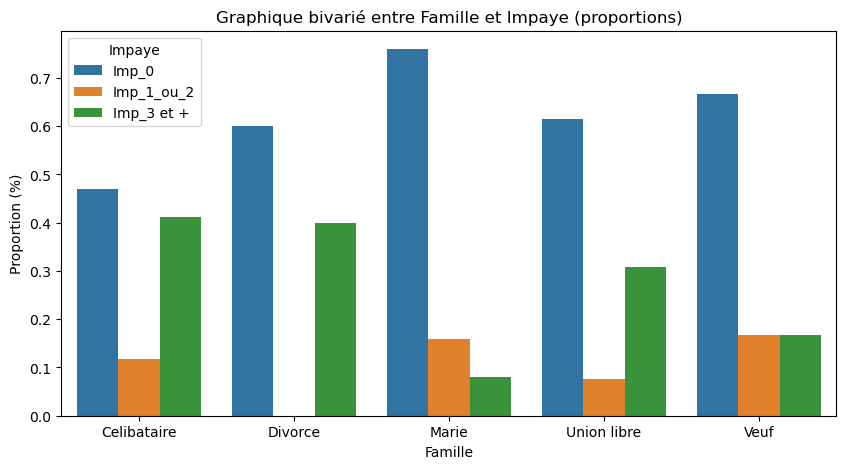

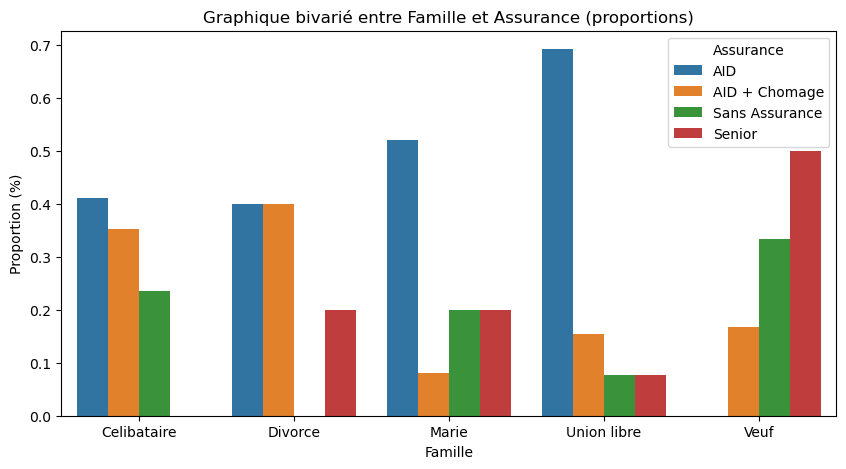

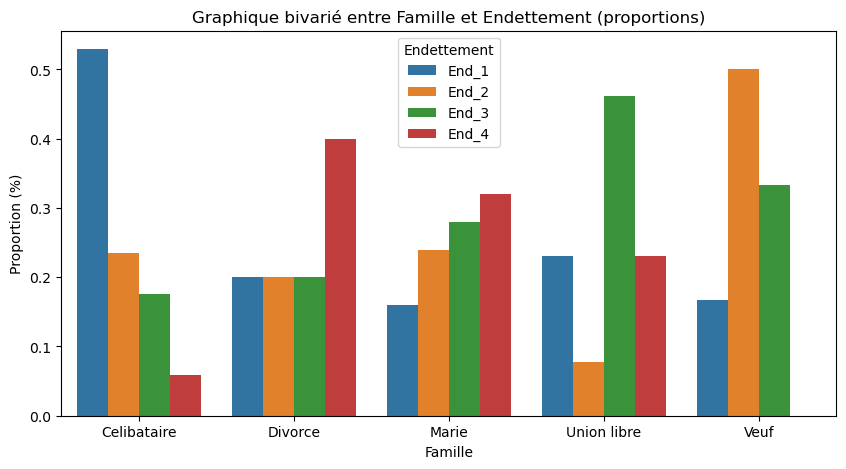

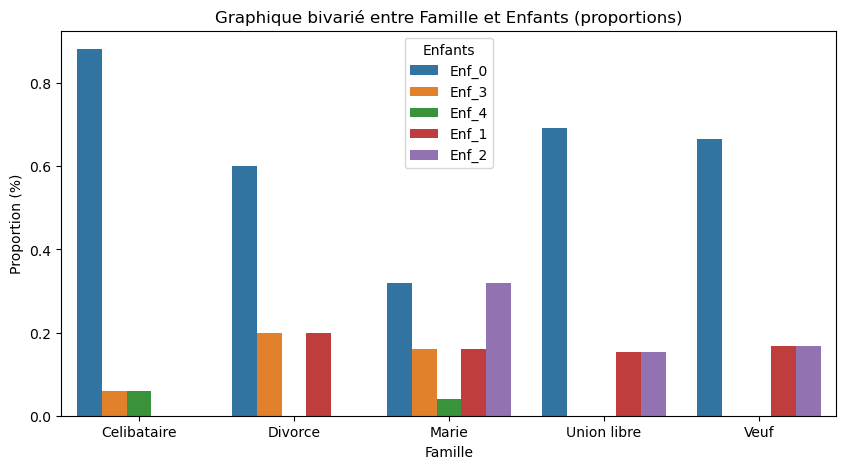

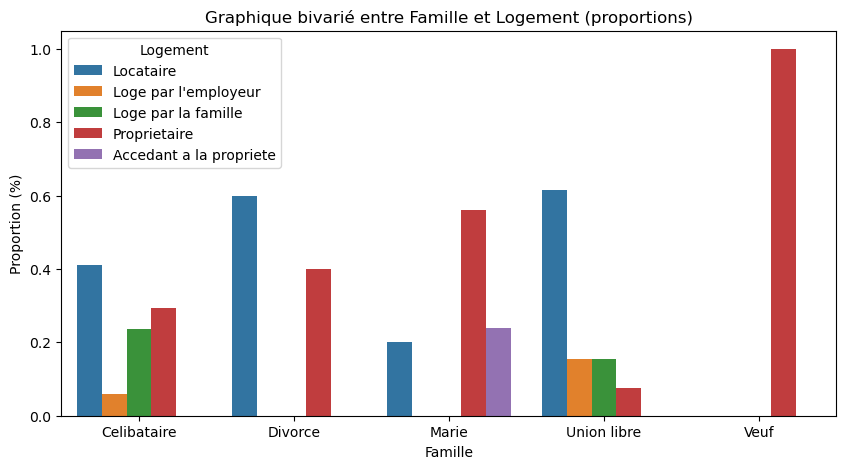

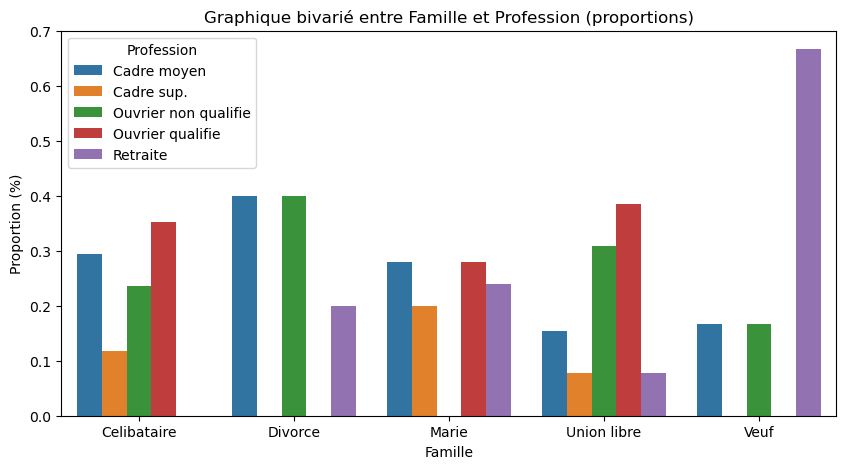

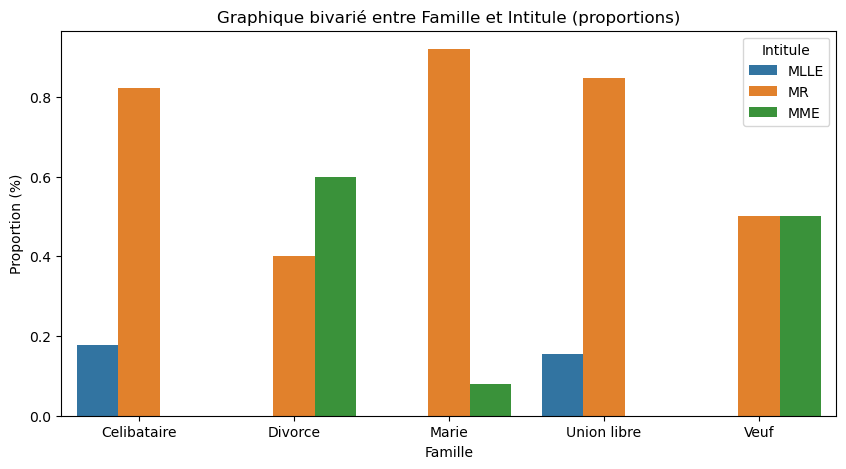

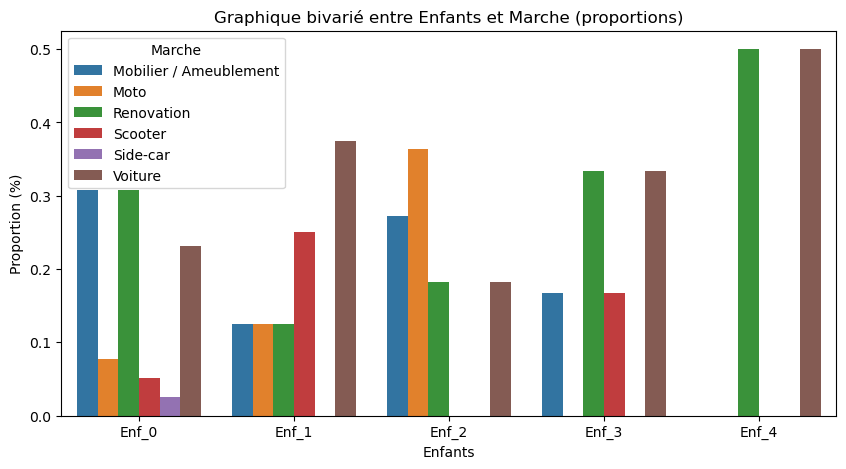

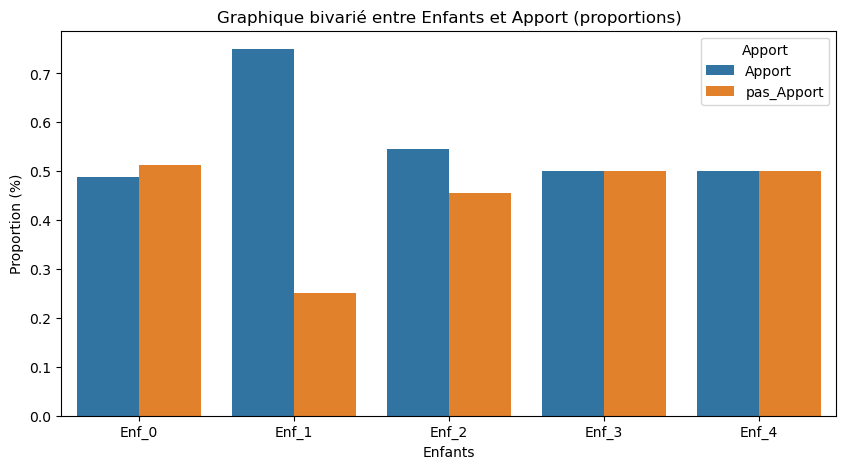

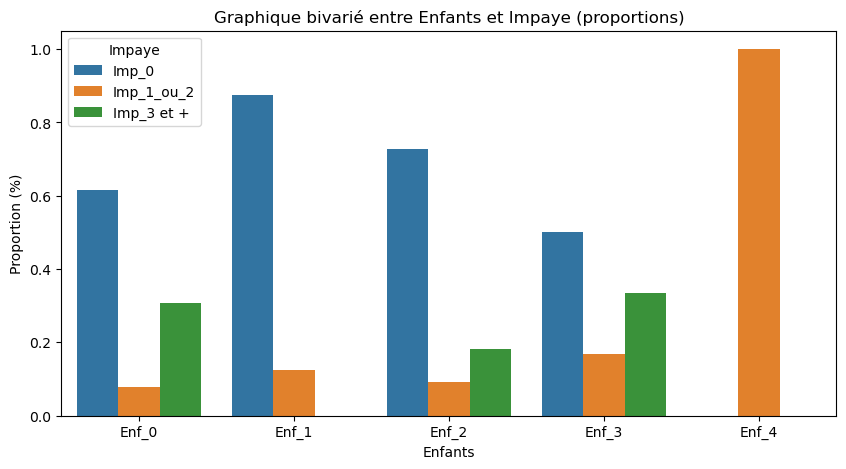

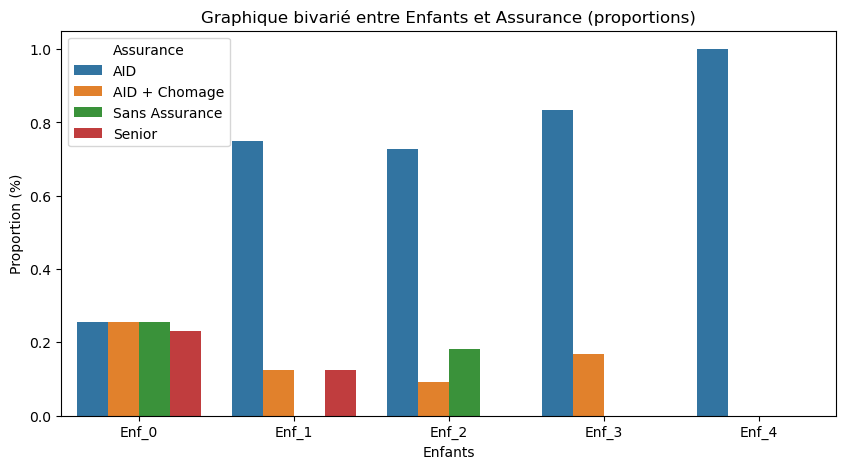

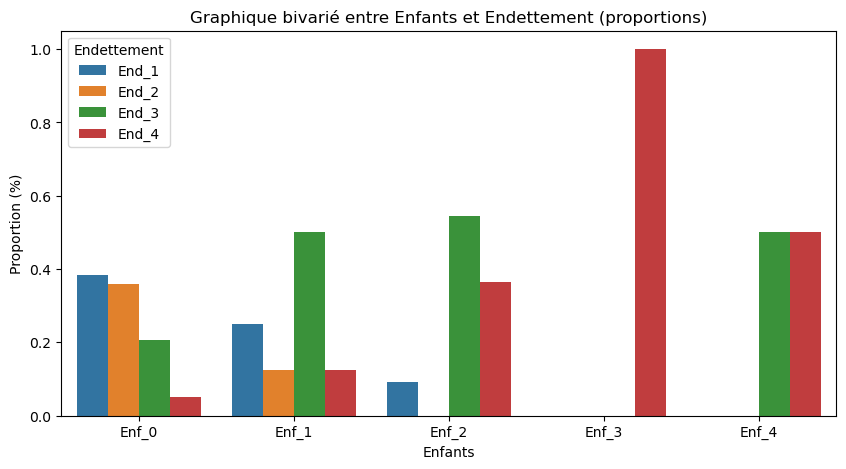

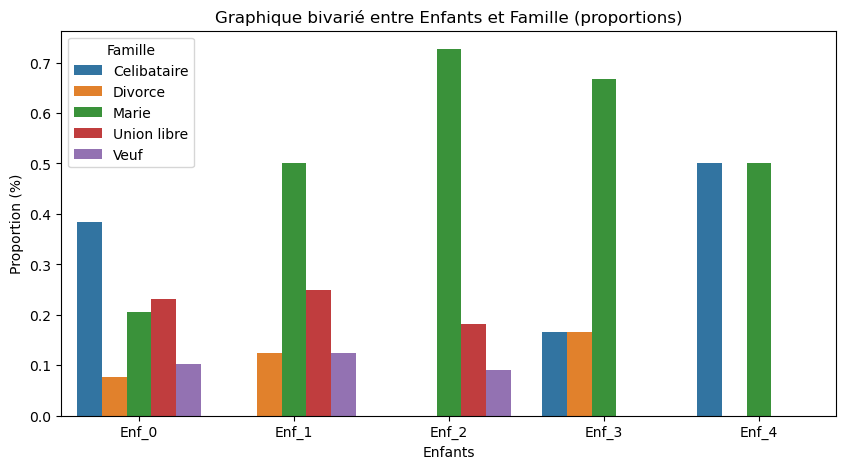

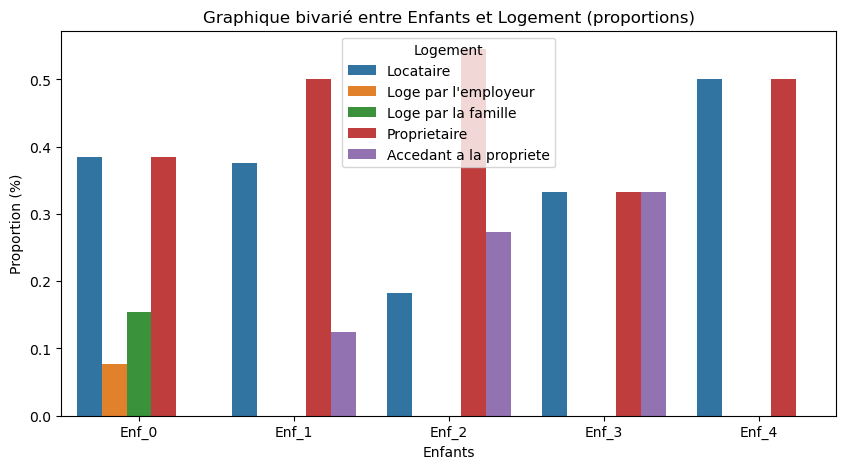

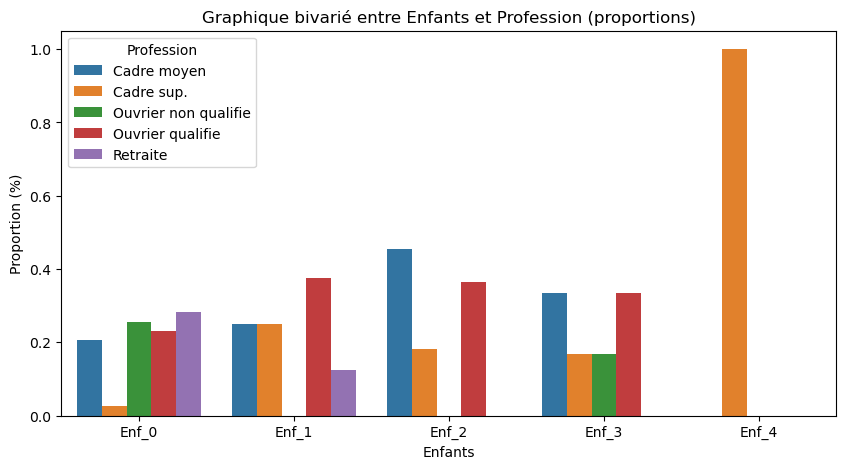

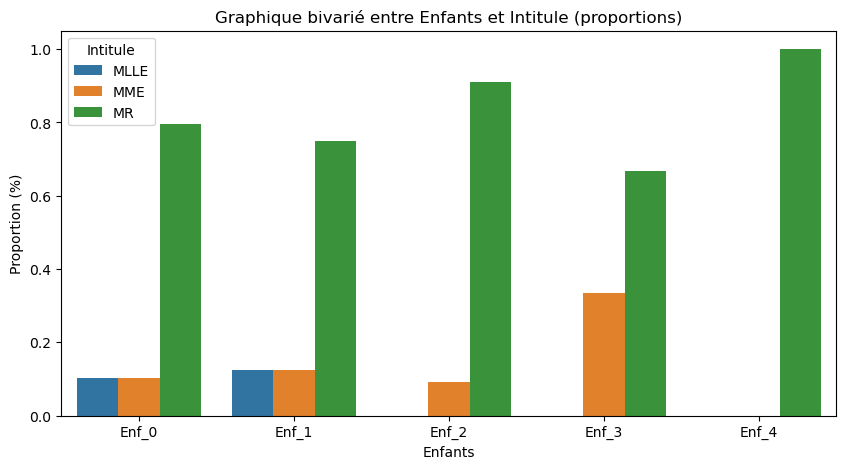

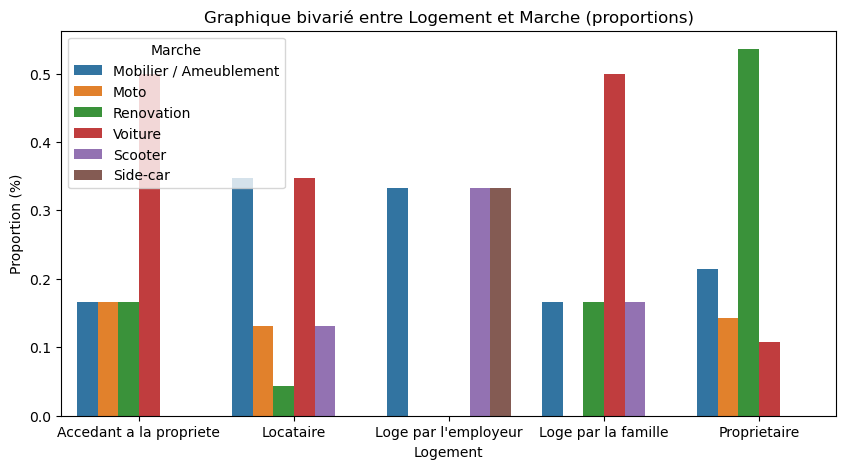

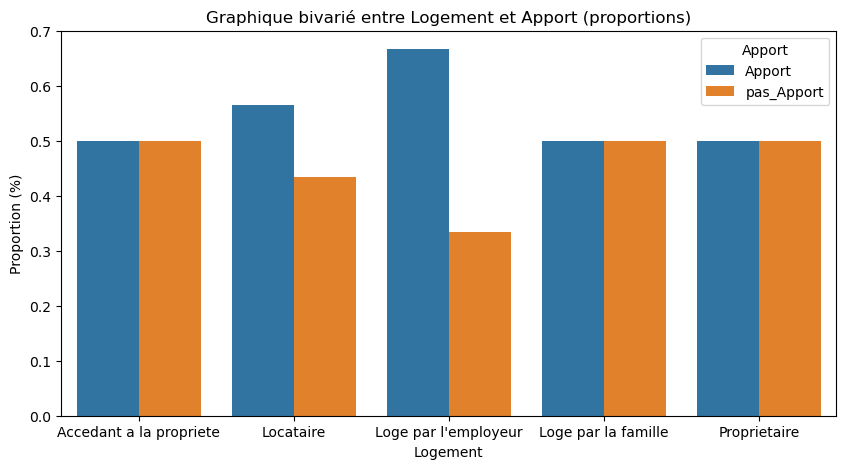

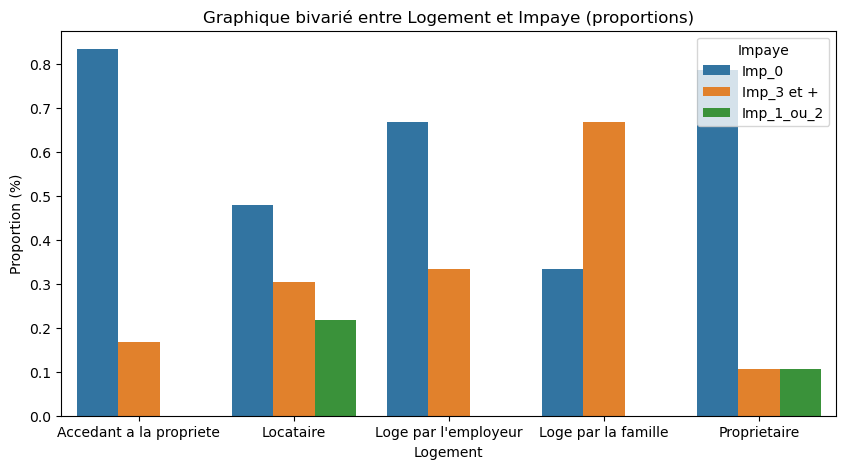

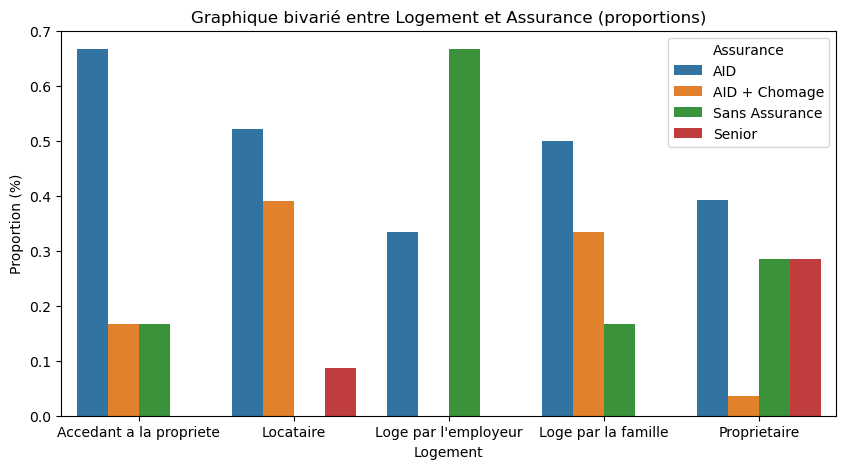

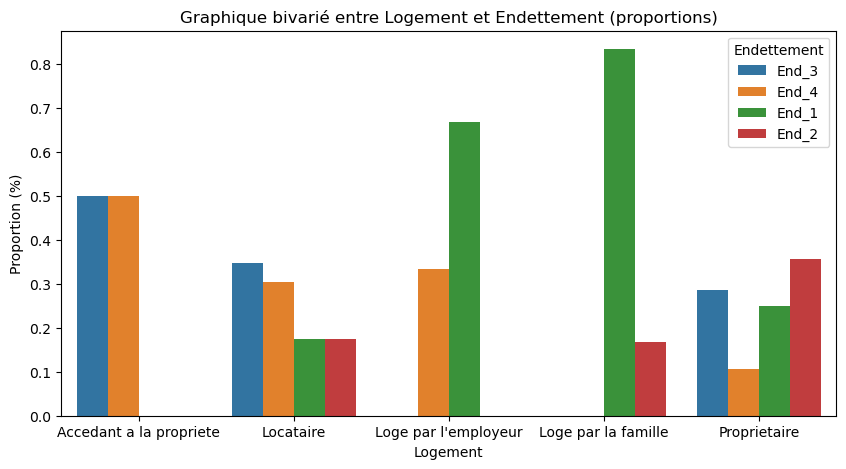

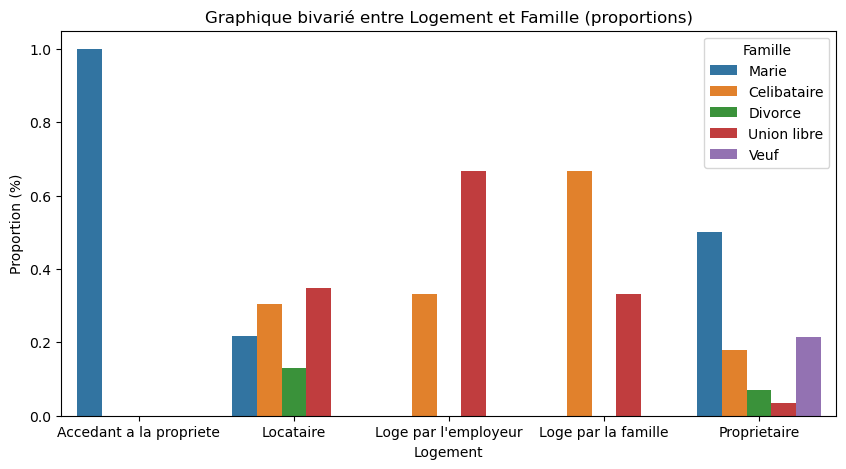

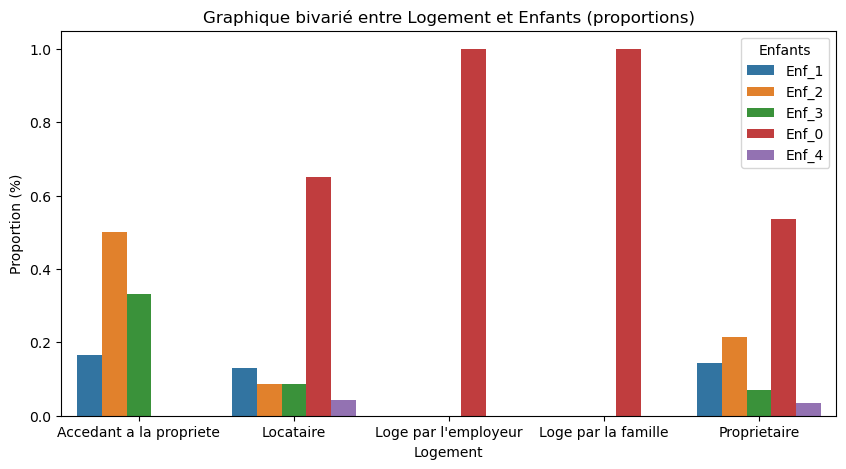

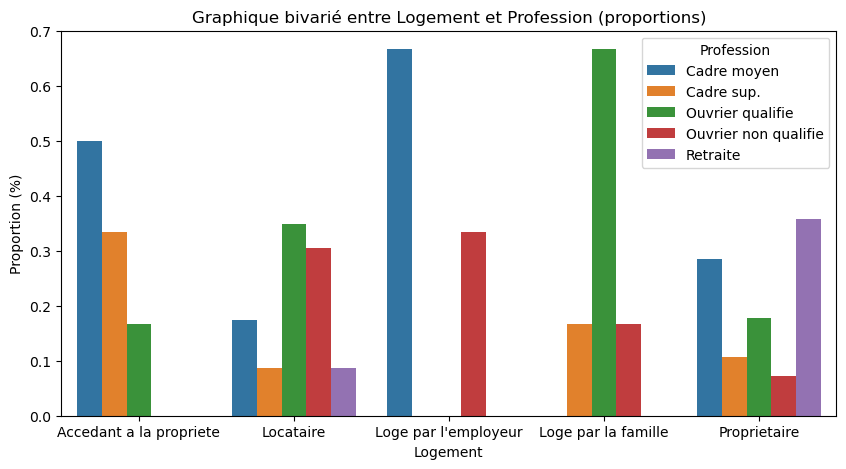

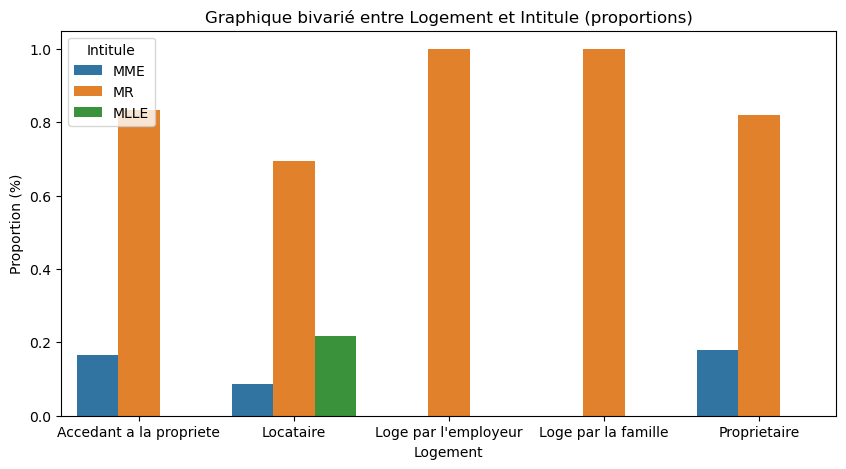

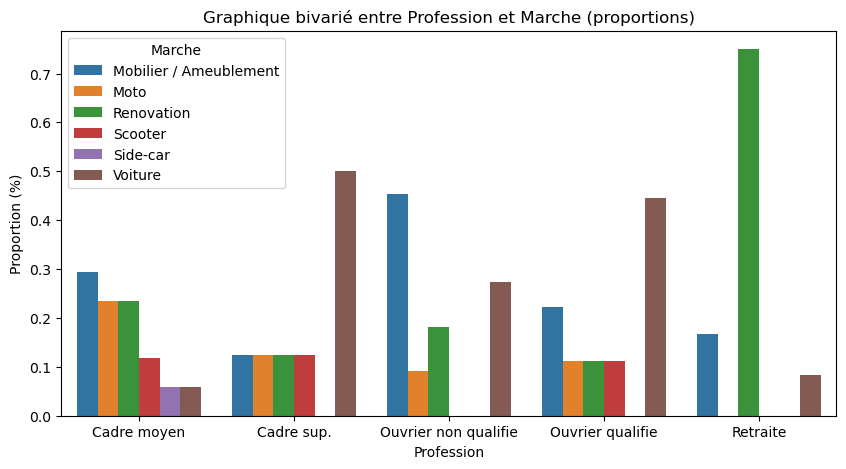

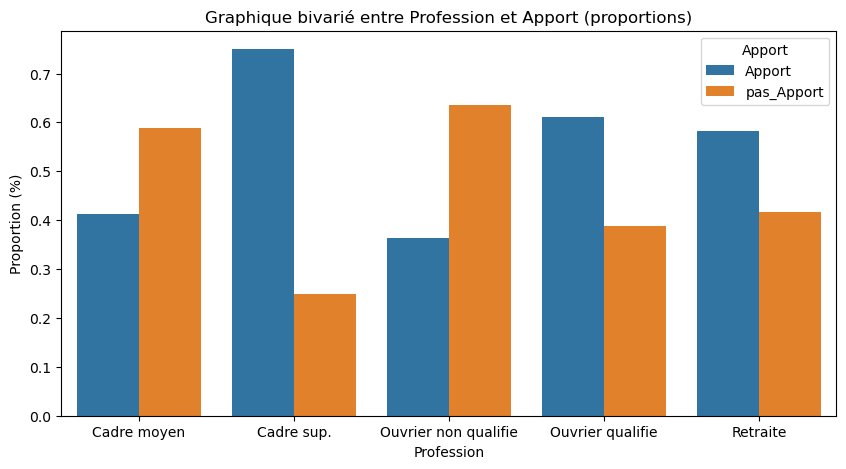

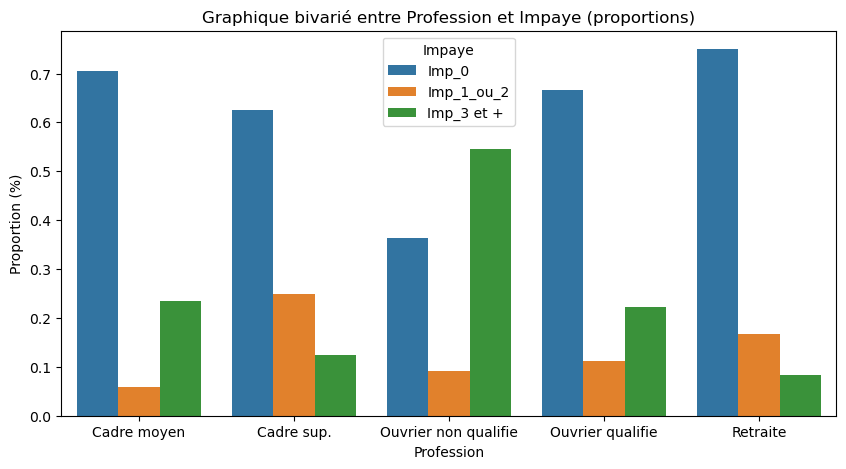

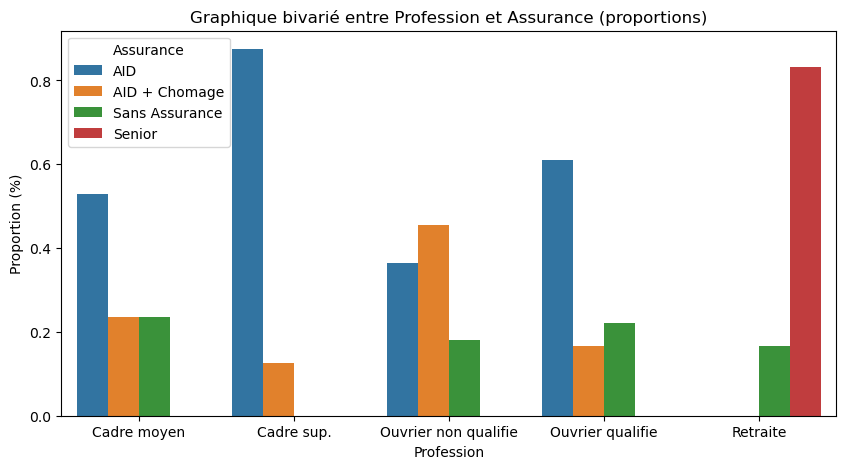

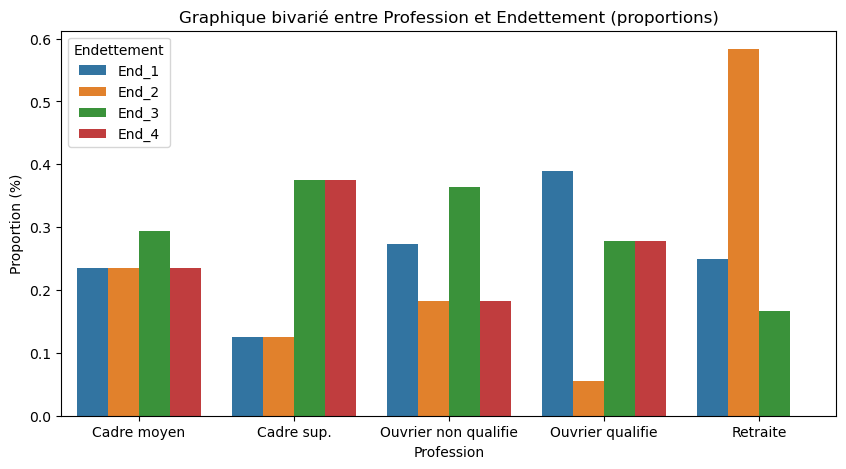

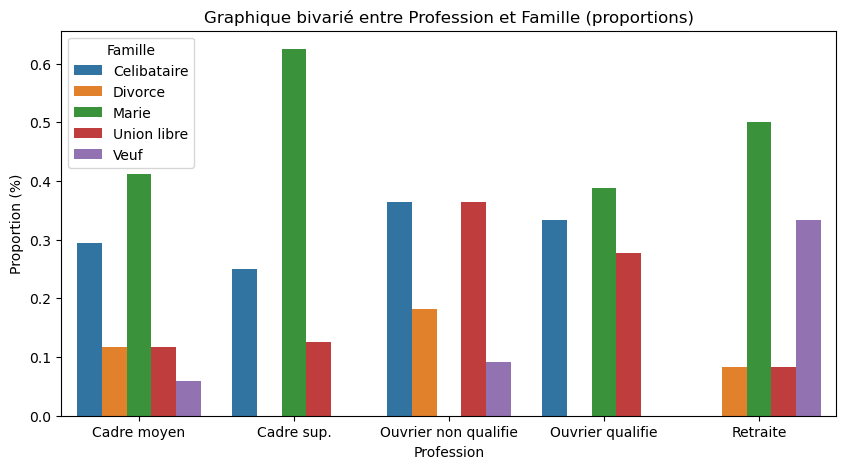

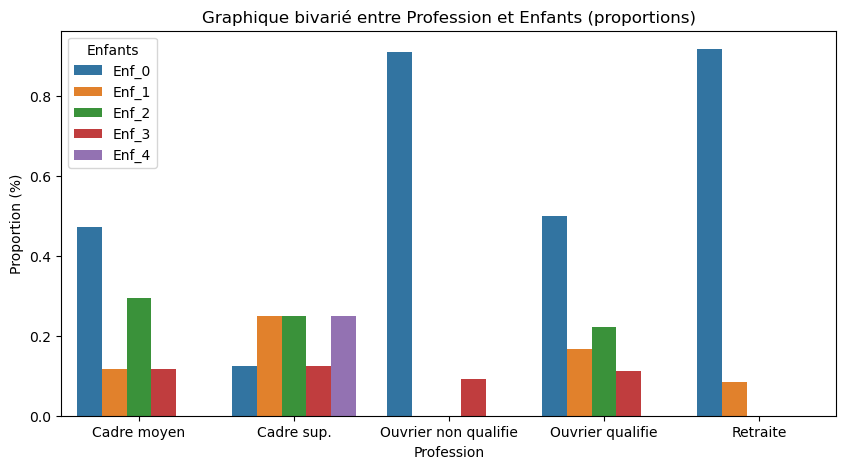

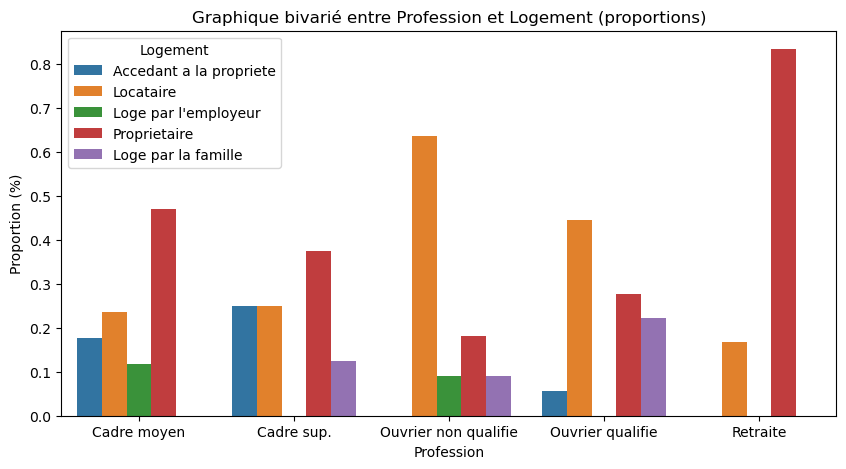

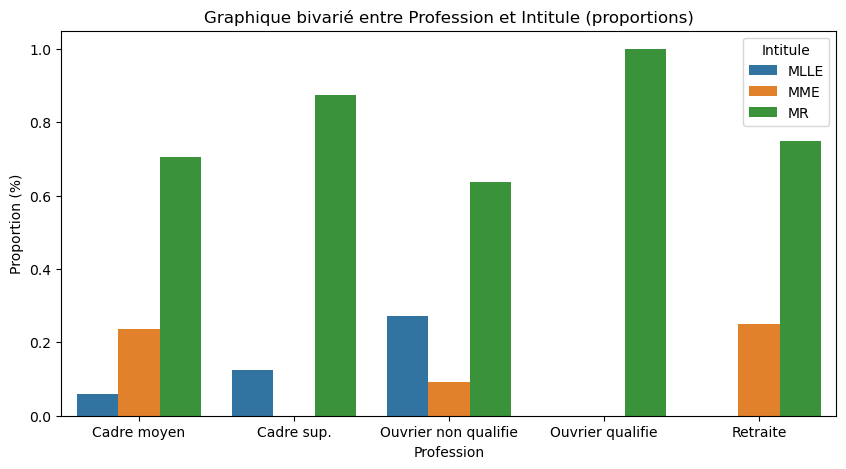

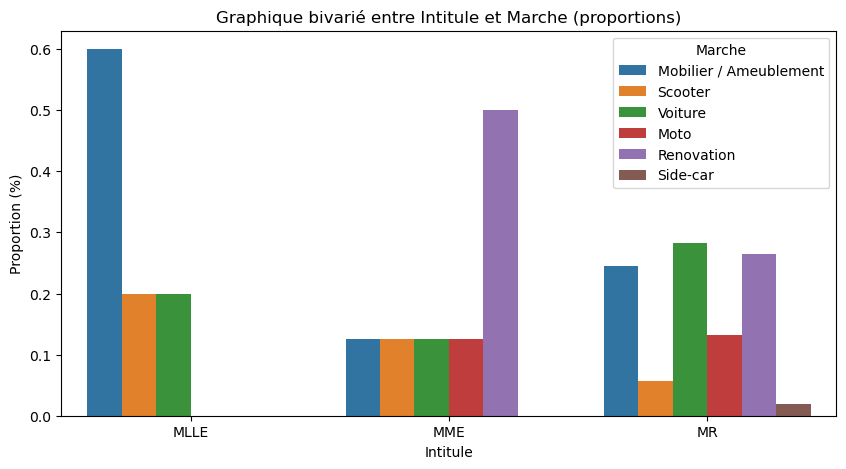

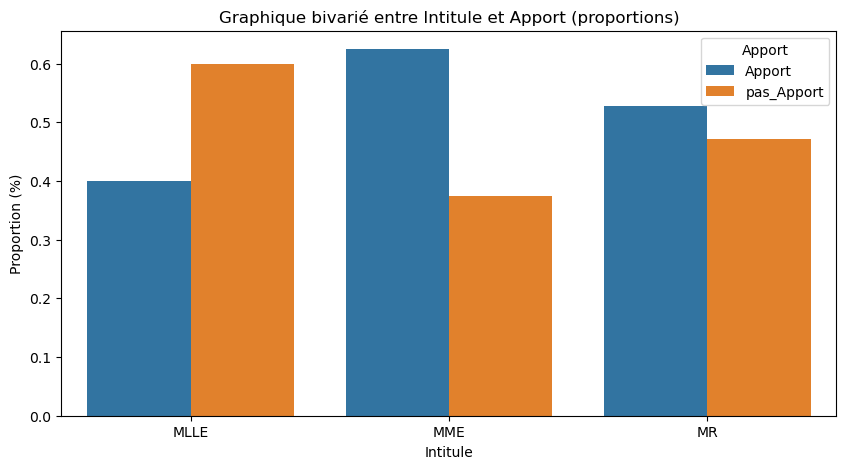

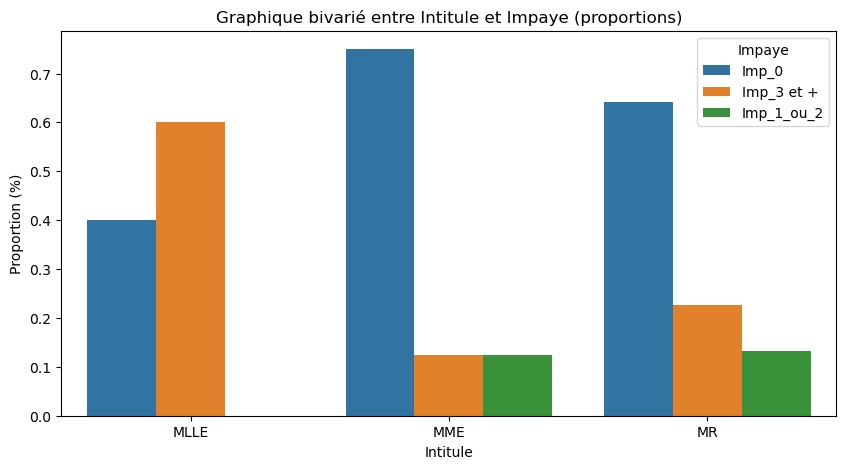

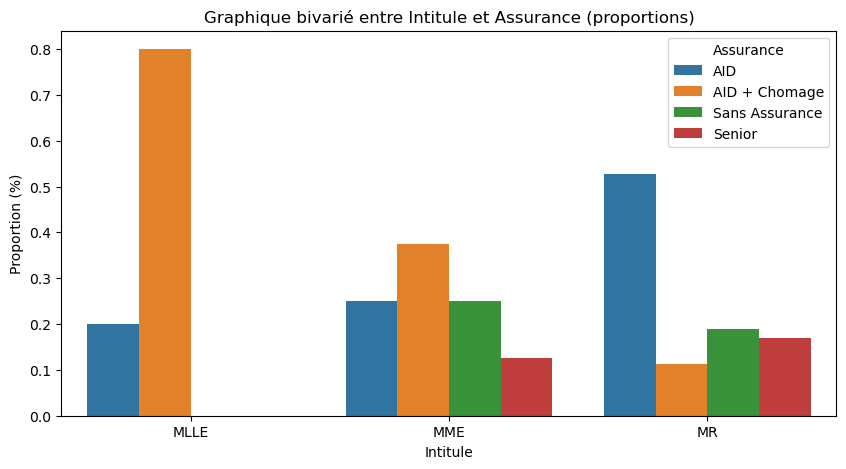

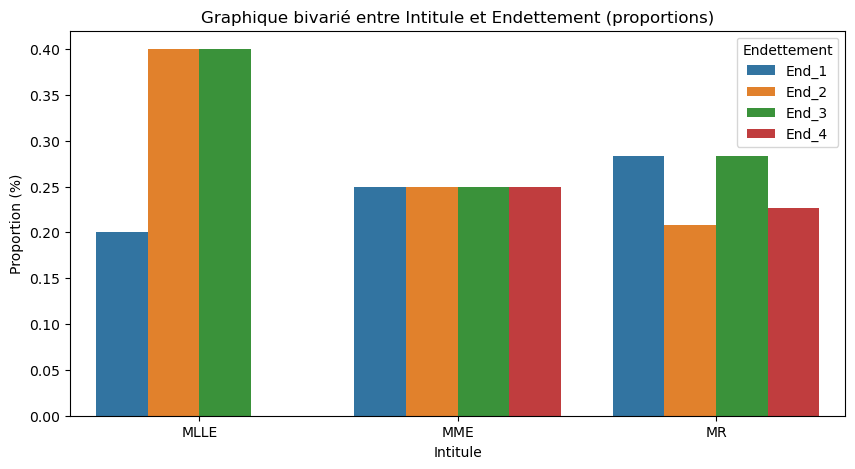

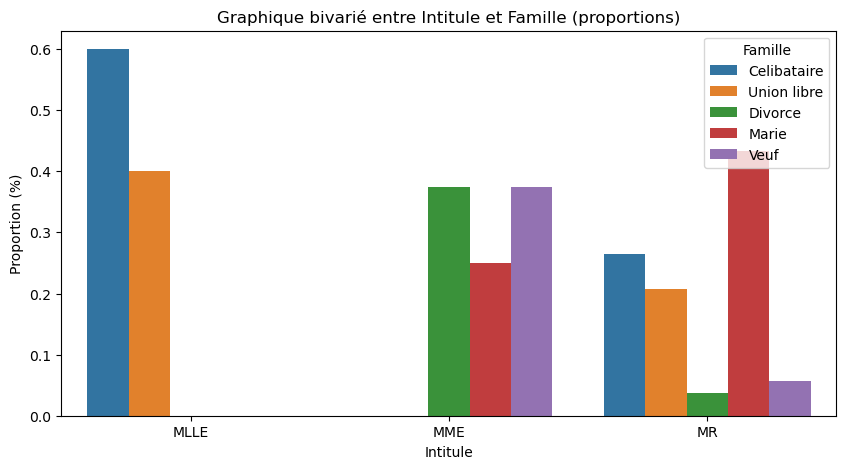

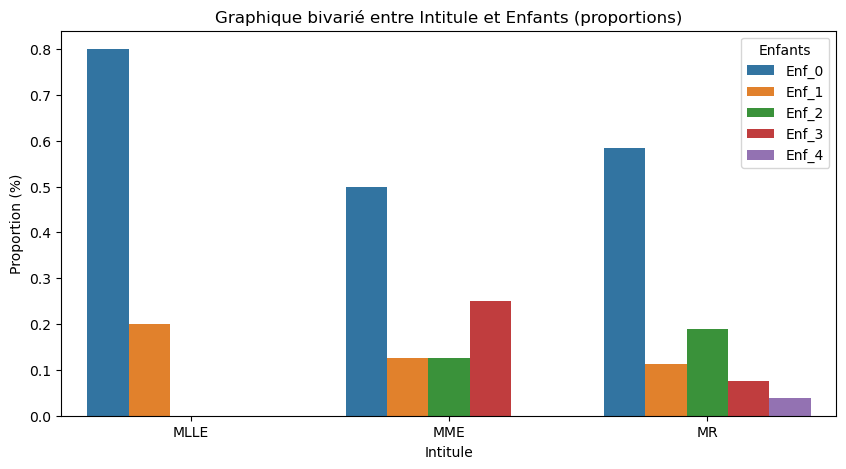

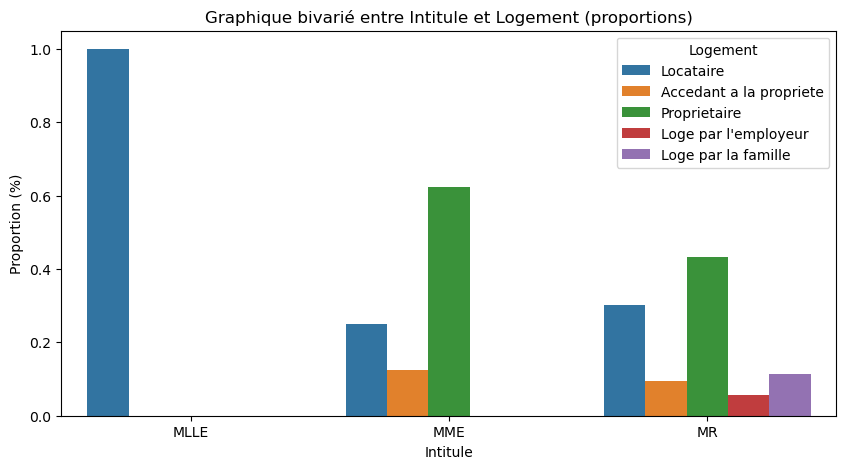

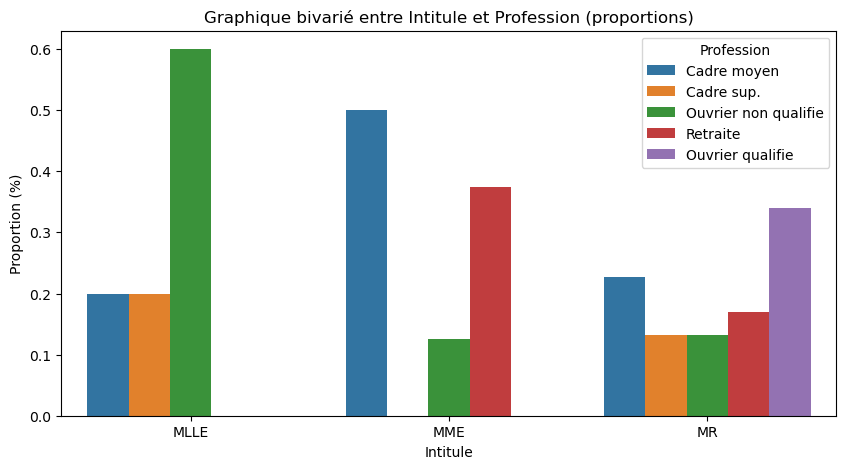

In [263]:
# Analyse bivariées

# Analyse grahique
categorical_columns = ['Marche', 'Apport', 'Impaye', 'Assurance', 'Endettement', 'Famille', 'Enfants', 'Logement', 'Profession', 'Intitule']
# Créer des graphiques bivariés pour chaque paire de variables qualitatives
for col1 in categorical_columns:
    for col2 in categorical_columns:
        if col1 != col2:
            # Calculer les proportions pour le graphique bivarié
            proportions = credit_data.groupby([col1, col2]).size().reset_index(name='Count')
            proportions['Proportion'] = proportions['Count'] / proportions.groupby(col1)['Count'].transform('sum')

            # Créer un graphique en barres empilées pour une paire de variables
            plt.figure(figsize=(10, 5))
            sns.barplot(x=col1, y='Proportion', hue=col2, data=proportions)
            plt.title(f"Graphique bivarié entre {col1} et {col2} (proportions)")
            plt.ylabel('Proportion (%)')
            plt.show()

In [269]:
# 4.2 Les tests statistiques

from scipy.stats import chi2_contingency

# Initialiser les DataFrame pour les coefficients de Cramer et les p-values
cramer_v_df = pd.DataFrame(index=categorical_columns, columns=categorical_columns)
p_value_df = pd.DataFrame(index=categorical_columns, columns=categorical_columns)
tschuprow_t_df = pd.DataFrame(index=categorical_columns, columns=categorical_columns)

# Calculer le test de chi_deux pour chaque paire de variables qualitatives
for i, column1 in enumerate(categorical_columns):
    for j, column2 in enumerate(categorical_columns):
        if column1 != column2:
            contingency_table = pd.crosstab(credit_data[column1], credit_data[column2])
            chi2, p, dof, expected = chi2_contingency(contingency_table)
            cramer_v = np.sqrt(chi2 / (credit_data.shape[0] * (min(contingency_table.shape) - 1)))
            tschuprow_t = cramer_v * np.sqrt((contingency_table.shape[0] - 1) * (contingency_table.shape[1] - 1) / (credit_data.shape[0] - 1))
            cramer_v_df.loc[column1, column2] = cramer_v
            tschuprow_t_df.loc[column1, column2] = tschuprow_t
            p_value_df.loc[column1, column2] = p 

# Afficher le DataFrame des p_values
print("\nDataFrame des p-values :")
p_value_df.style.set_properties(**{'border_color': 'black','border-width': 'lpx', 'border-style':'solid'})


DataFrame des p-values :


,Marche,Apport,Impaye,Assurance,Endettement,Famille,Enfants,Logement,Profession,Intitule
Marche,nan,0.002566,0.751865,0.019173,0.542668,0.712239,0.626541,0.000221,0.035320,0.539232
Apport,0.002566,nan,0.346020,0.927621,0.576277,0.185990,0.757628,0.975041,0.361529,0.729898
Impaye,0.751865,0.346020,nan,0.243950,0.046660,0.413456,0.012979,0.083970,0.298964,0.353318
Assurance,0.019173,0.927621,0.243950,nan,0.027993,0.056152,0.064280,0.009499,0.000000,0.011626
Endettement,0.542668,0.576277,0.046660,0.027993,nan,0.163073,0.000014,0.011985,0.182384,0.887377
Famille,0.712239,0.185990,0.413456,0.056152,0.163073,nan,0.177295,0.000721,0.031307,0.000350
Enfants,0.626541,0.757628,0.012979,0.064280,0.000014,0.177295,nan,0.225155,0.008371,0.741197
Logement,0.000221,0.975041,0.083970,0.009499,0.011985,0.000721,0.225155,nan,0.026472,0.138006
Profession,0.035320,0.361529,0.298964,0.000000,0.182384,0.031307,0.008371,0.026472,nan,0.036099
Intitule,0.539232,0.729898,0.353318,0.011626,0.887377,0.000350,0.741197,0.138006,0.036099,nan


In [271]:
# Afficher le DataFrame des coefficients de Tschuprow
print("\nDataFrame des coefficients de Tschuprow :")
tschuprow_t_df.style.background_gradient(cmap='Greens', high=0.4, low=0).set_properties(**{'border-color': 'black', 'border-width': '1px', 'border-style': 'solid'})


DataFrame des coefficients de Tschuprow :


,Marche,Apport,Impaye,Assurance,Endettement,Famille,Enfants,Logement,Profession,Intitule
Marche,nan,0.146143,0.088480,0.181948,0.126707,0.136858,0.142427,0.241425,0.195576,0.101991
Apport,0.146143,nan,0.031457,0.017932,0.037224,0.075919,0.041879,0.021243,0.063638,0.017134
Impaye,0.088480,0.031457,nan,0.074425,0.094537,0.087480,0.134406,0.113911,0.094304,0.045344
Assurance,0.181948,0.017932,0.074425,nan,0.114314,0.138674,0.137073,0.156816,0.242331,0.107187
Endettement,0.126707,0.037224,0.094537,0.114314,nan,0.124613,0.203258,0.154680,0.122890,0.040334
Famille,0.136858,0.075919,0.087480,0.138674,0.124613,nan,0.140036,0.193677,0.161682,0.163748
Enfants,0.142427,0.041879,0.134406,0.137073,0.203258,0.140036,nan,0.136186,0.174318,0.069310
Logement,0.241425,0.021243,0.113911,0.156816,0.154680,0.193677,0.136186,nan,0.163416,0.107123
Profession,0.195576,0.063638,0.094304,0.242331,0.122890,0.161682,0.174318,0.163416,nan,0.123930
Intitule,0.101991,0.017134,0.045344,0.107187,0.040334,0.163748,0.069310,0.107123,0.123930,nan


In [273]:
# Rappel : l'analyse de la liaison se fait avec le test de chi2
# on analyse l'intensité de la relation avec le v de cramer et tscuprow

### 5. Analyse multivariées grace à l'ACM

### 5.1 ACM

In [282]:
import fanalysis.mca as mca

# liste des variables qualitatives
categorical_columns = ['Marche', 'Assurance', 'Intitule', 'Impaye', 'Profession', 'Endettement']

x = credit_data[categorical_columns].values


In [284]:
df = credit_data
# Creer une instance de la classe MCA
my_ca = mca.MCA(row_labels=df.index.values, var_labels=categorical_columns)

In [286]:
# Estimation de l'ACM
my_ca.fit(x)

MCA(row_labels=array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65],
      dtype=int64),
    var_labels=['Marche', 'Assurance', 'Intitule', 'Impaye', 'Profession',
                'Endettement'])

#### 5.2 Aides à l'interpretation
#### 5.2.1 Choix du nombre d'axe factoriel grace à l'analyse des valeurs propres


In [291]:
print(my_ca.eig_)

[[4.45692632e-01 3.42815647e-01 2.94260346e-01 2.55204723e-01
  2.32060207e-01 2.00874874e-01 1.80355837e-01 1.76024083e-01
  1.59261730e-01 1.52363536e-01 1.40611459e-01 1.20144581e-01
  1.02085181e-01 8.82631186e-02 8.43641515e-02 7.22202857e-02
  6.40426367e-02 4.63392362e-02 9.68240304e-03]
 [1.40745042e+01 1.08257573e+01 9.29243196e+00 8.05909653e+00
  7.32821706e+00 6.34341707e+00 5.69544748e+00 5.55865524e+00
  5.02931780e+00 4.81148007e+00 4.44036186e+00 3.79403939e+00
  3.22374255e+00 2.78725638e+00 2.66413110e+00 2.28064060e+00
  2.02239905e+00 1.46334430e+00 3.05760096e-01]
 [1.40745042e+01 2.49002614e+01 3.41926934e+01 4.22517899e+01
  4.95800070e+01 5.59234241e+01 6.16188715e+01 6.71775268e+01
  7.22068446e+01 7.70183247e+01 8.14586865e+01 8.52527259e+01
  8.84764685e+01 9.12637249e+01 9.39278560e+01 9.62084966e+01
  9.82308956e+01 9.96942399e+01 1.00000000e+02]]


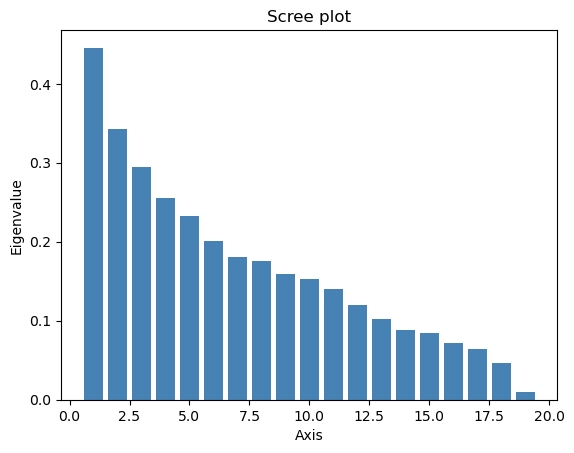

In [295]:
# Graphique des valeurs propres
my_ca.plot_eigenvalues()

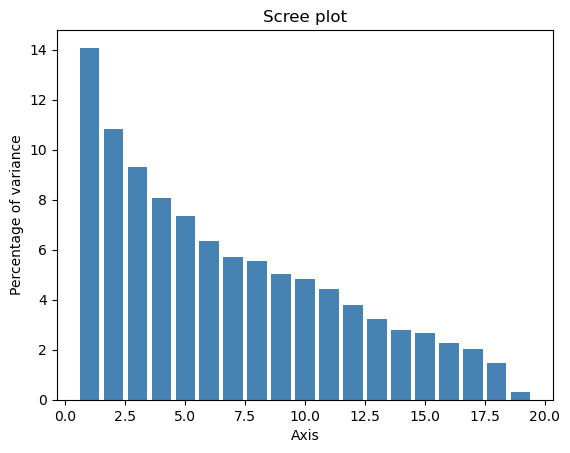

In [297]:
# Pourcentage de variance expliquée
my_ca.plot_eigenvalues(type="percentage")

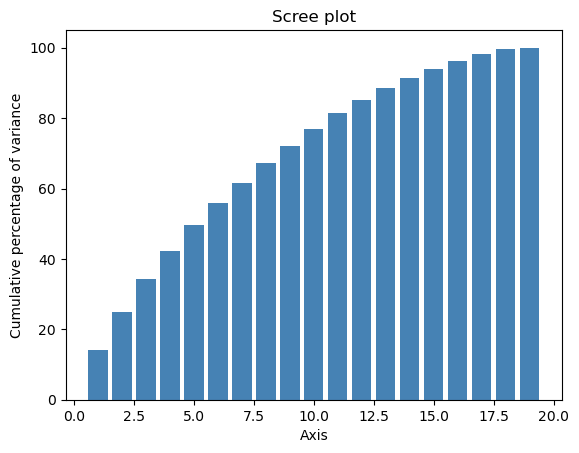

In [299]:
# Variance expliquée cumulée
my_ca.plot_eigenvalues(type="cumulative")

On va se limiter ici aux 3 premiers axes qui nous rapportent à peu pres 40% de l'inertie totale ( On a beaucoup de modalités, ce sera tres difficile 
d'avoir une grosse part d'inertie

### Analyse de la qualité de représentation en ligne

In [304]:
df_rows = my_ca.row_topandas()
print(df_rows)

    row_coord_dim1  row_coord_dim2  row_coord_dim3  row_coord_dim4  \
0        -0.052761        0.087667       -0.243399        0.186003   
1        -0.541548       -0.130431       -0.508997        0.303325   
2         0.393778       -0.540740       -0.078564        0.452163   
3        -1.531751        0.054821        0.369057        0.209774   
4         0.688232       -0.348121        0.310576       -0.530272   
..             ...             ...             ...             ...   
61        0.074481        0.645569       -0.594963       -0.721647   
62        0.200110        0.771481        0.198467        0.123476   
63        0.154341        0.332831        0.435073       -0.328709   
64        0.590794       -0.258467        0.620012        0.588328   
65       -1.491797       -0.119584        0.915796        0.122653   

    row_coord_dim5  row_coord_dim6  row_coord_dim7  row_coord_dim8  \
0         0.197176       -0.130743       -0.042048        0.078388   
1        -0.229767 

#### Qualité de la representation
#### Qualité profil ligne (individus)

Premier Axe


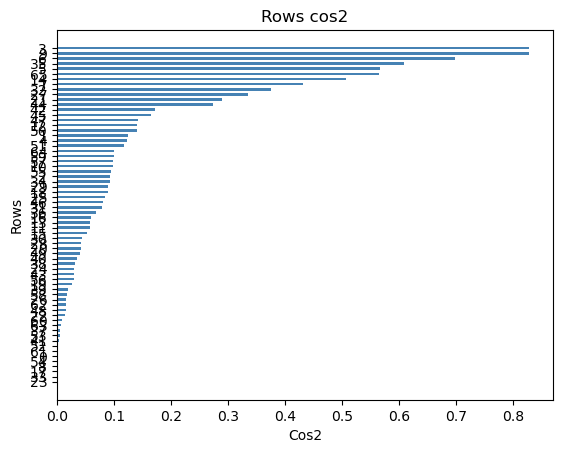

Deuxième  Axe


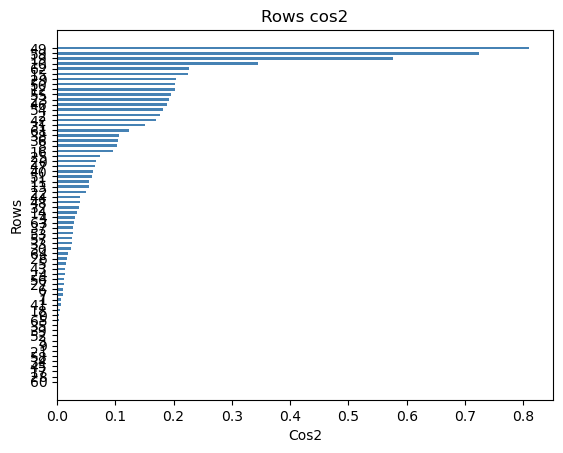

In [307]:
print("Premier Axe")

my_ca.plot_row_cos2(num_axis=1)
print("Deuxième  Axe")

my_ca.plot_row_cos2(num_axis=2)

#### Qualité profil colonnes (modalités des variables)

Premier Axe


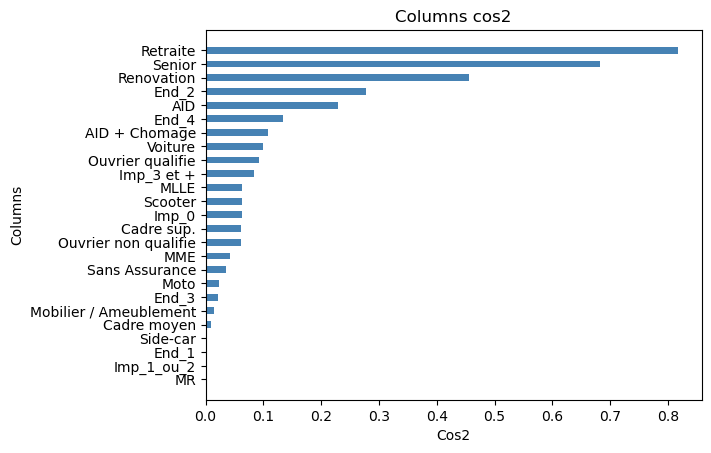

Deuxième  Axe


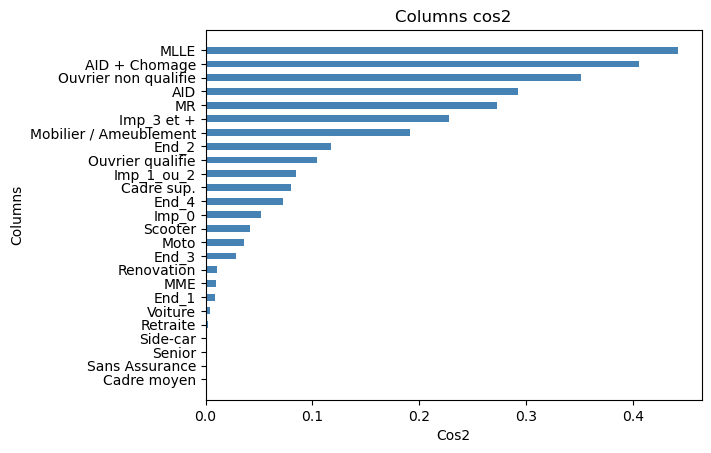

Troisième  Axe


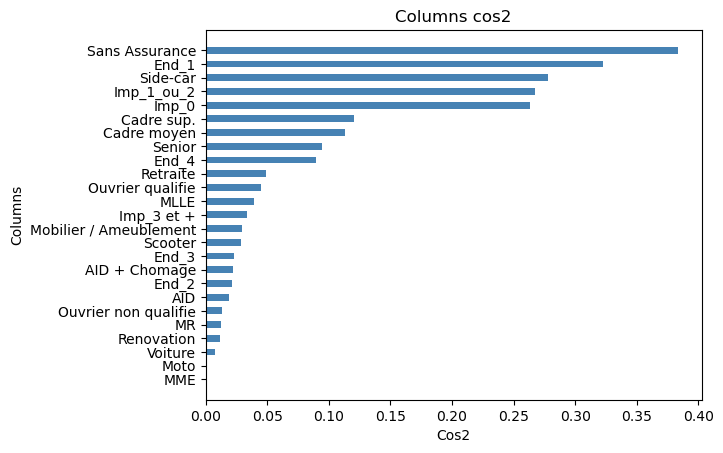

In [310]:
print("Premier Axe")

my_ca.plot_col_cos2(num_axis=1)
print("Deuxième  Axe")

my_ca.plot_col_cos2(num_axis=2)
print("Troisième  Axe")

my_ca.plot_col_cos2(num_axis=3)

#### Analyse des contributions
#### Contributions ligne

Premier Axe


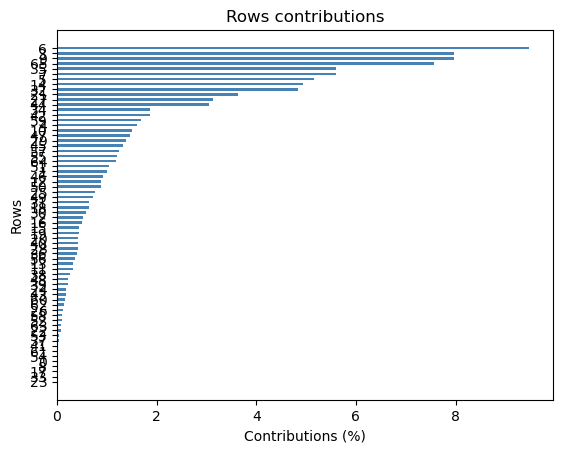

In [313]:
print("Premier Axe")

my_ca.plot_row_contrib(num_axis=1)

Deuxieme Axe


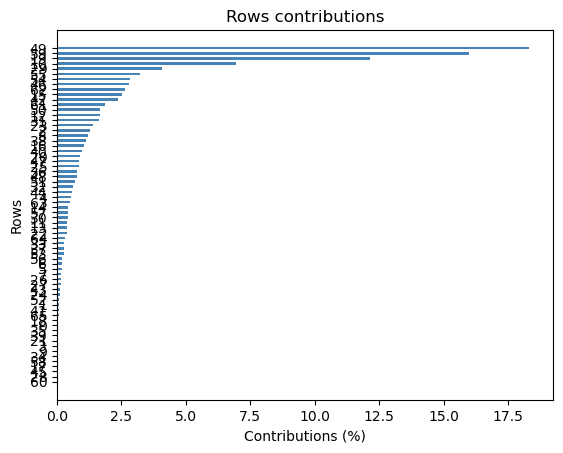

In [315]:
print("Deuxieme Axe")

my_ca.plot_row_contrib(num_axis=2)

#### Contribution profil colonne

Premier Axe


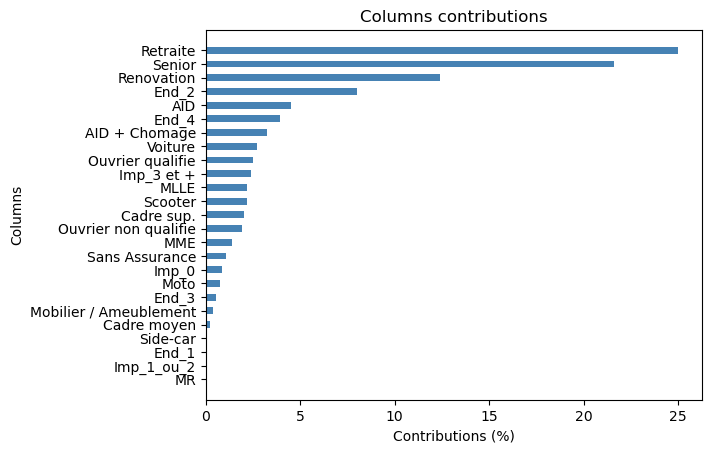

In [320]:
print("Premier Axe")
my_ca.plot_col_contrib(num_axis=1)

Deuxieme Axe


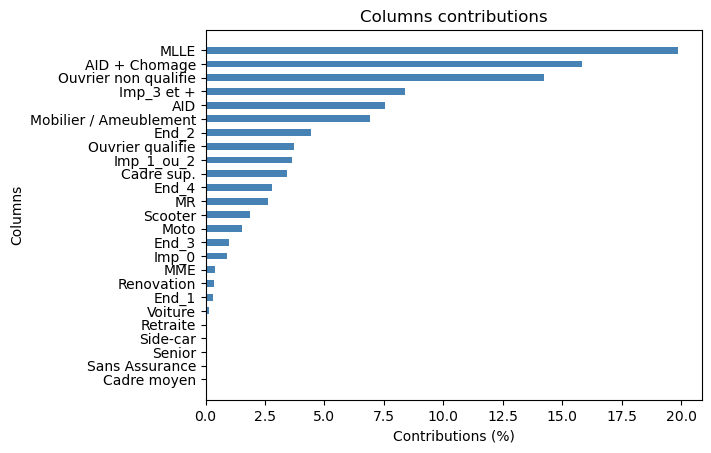

In [324]:
print("Deuxieme Axe")
my_ca.plot_col_contrib(num_axis=2)

#### Interpretation graphique

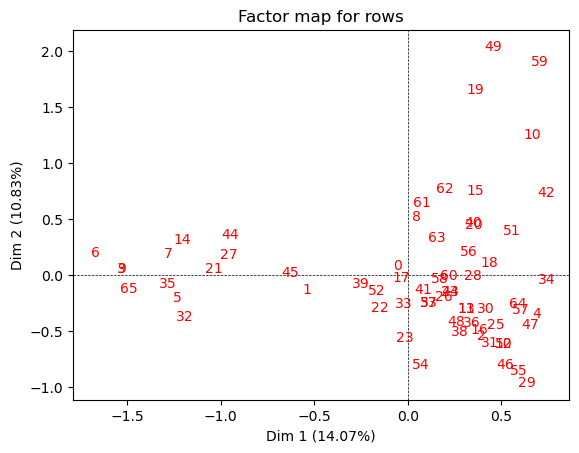

In [329]:
# Graphique profil ligne
my_ca.mapping_row(num_x_axis=1, num_y_axis=2)

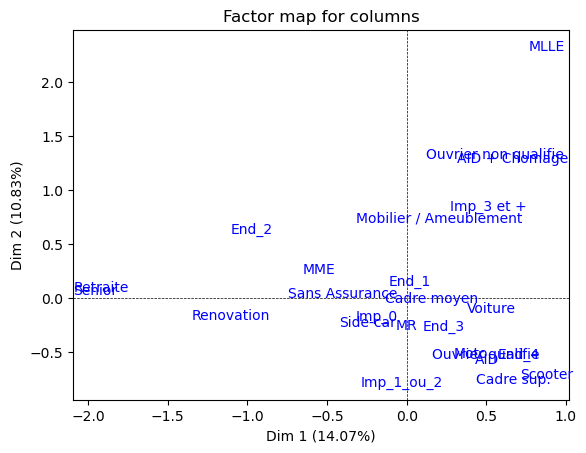

In [331]:
# Graphique des points colonnes
my_ca.mapping_col(num_x_axis=1, num_y_axis=2)

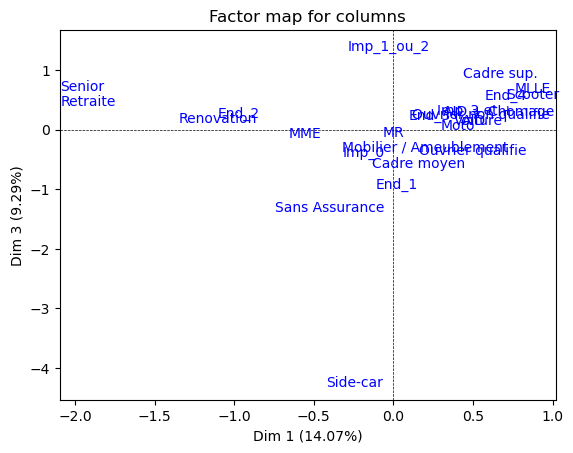

In [333]:
# Graphique des points colonnes
my_ca.mapping_col(num_x_axis=1, num_y_axis=3)

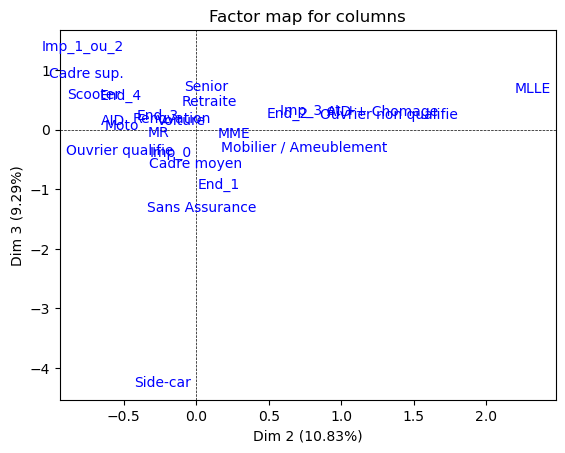

In [335]:
# Graphique des points sur les axes factoriels 2 et 3
my_ca.mapping_col(num_x_axis=2, num_y_axis=3)

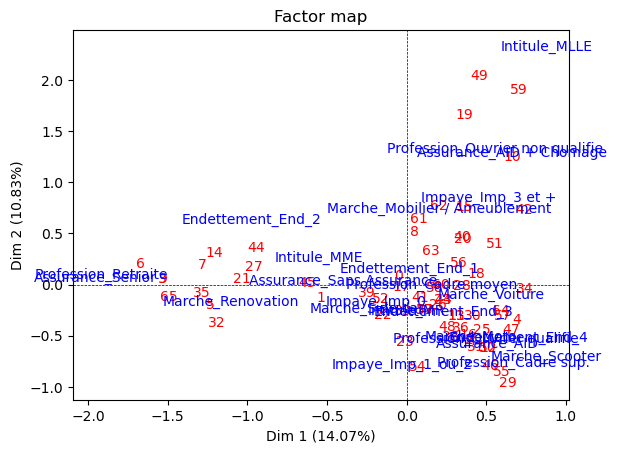

In [337]:
# Graphique superposition si necessaire
my_ca.mapping(num_x_axis=1, num_y_axis=2, short_labels=False)